# Notebook 2 — Exploratory Data Analysis & Visualization
## NFL Player Performance Analysis (QB · RB · WR · TE)

**Authors:** Milan Jovkić, Uroš Petrašković  
**Course:** Analiza i Obrada Podataka  
**Date:** 2025

---

This notebook contains **dozens of graphs and analyses** across all four positions. We explore trends, distributions, correlations, and key insights that will inform our predictive models in Notebook 3.

### Table of Contents
1. Setup & Data Loading
2. **QB Analysis** — Passing trends, efficiency, win correlation, era comparison, stat padding
3. **QB Elo Ratings** — Elo distribution, top-rated QBs, career trajectories
4. **RB Analysis** — Rushing/receiving balance, workload, efficiency
5. **WR Analysis** — Target share, advanced metrics, situational splits
6. **TE Analysis** — Receiving trends, position evolution
7. **Cross-Position Comparisons** — Scoring, efficiency, era trends
8. **Feature Importance Preview** — Which stats predict performance?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'figure.facecolor': 'white',
})

COLORS = {'QB': '#E31837', 'RB': '#003DA5', 'WR': '#FFC20E', 'TE': '#00843D'}

print("Libraries loaded. Matplotlib backend:", plt.get_backend())

Libraries loaded. Matplotlib backend: module://matplotlib_inline.backend_inline


In [5]:
import os
# if running from notebooks/, move up to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Load all datasets
qb = pd.read_csv('data/fully combined/qb_master.csv')
rb = pd.read_csv('data/fully combined/rb_master.csv')
te = pd.read_csv('data/fully combined/te_master.csv')
wr = pd.read_csv('data/fully combined/wr_all_seasons.csv')
elo_career = pd.read_csv('data/nfl elo data/qb_rankings_career.csv')
elo_2025 = pd.read_csv('data/nfl elo data/qb_rankings_2025.csv')

# Parse QB wins from QBrec
def parse_wins(rec):
    try:
        parts = str(rec).split('-')
        return int(parts[0])
    except:
        return np.nan

def parse_losses(rec):
    try:
        parts = str(rec).split('-')
        return int(parts[1])
    except:
        return np.nan

qb['Wins'] = qb['QBrec'].apply(parse_wins)
qb['Losses'] = qb['QBrec'].apply(parse_losses)
qb['Win%'] = qb['Wins'] / (qb['Wins'] + qb['Losses'])
qb['Total_Games_Started'] = qb['Wins'] + qb['Losses']

# Filter starters for cleaner analysis
qb_starters = qb[qb['GS'] >= 8].copy()

# WR starters: at least 30 targets
wr_starters = wr[wr['targets'] >= 30].copy()

# RB starters: at least 50 rush attempts
rb_starters = rb[rb['Rush_Att'] >= 50].copy()

# TE starters: at least 20 targets
te_starters = te[te['Tgt'] >= 20].copy()

print(f"QB:  {len(qb)} total → {len(qb_starters)} starters (GS ≥ 8)")
print(f"RB:  {len(rb)} total → {len(rb_starters)} starters (Rush_Att ≥ 50)")
print(f"WR:  {len(wr)} total → {len(wr_starters)} starters (Targets ≥ 30)")
print(f"TE:  {len(te)} total → {len(te_starters)} starters (Targets ≥ 20)")

QB:  845 total → 645 starters (GS ≥ 8)
RB:  622 total → 569 starters (Rush_Att ≥ 50)
WR:  5529 total → 2162 starters (Targets ≥ 30)
TE:  194 total → 172 starters (Targets ≥ 20)


---
# 2. Quarterback (QB) Analysis

The quarterback position is the most important in football. We'll explore passing trends over nearly 50 years, efficiency metrics, and the relationship between stats and winning.

---

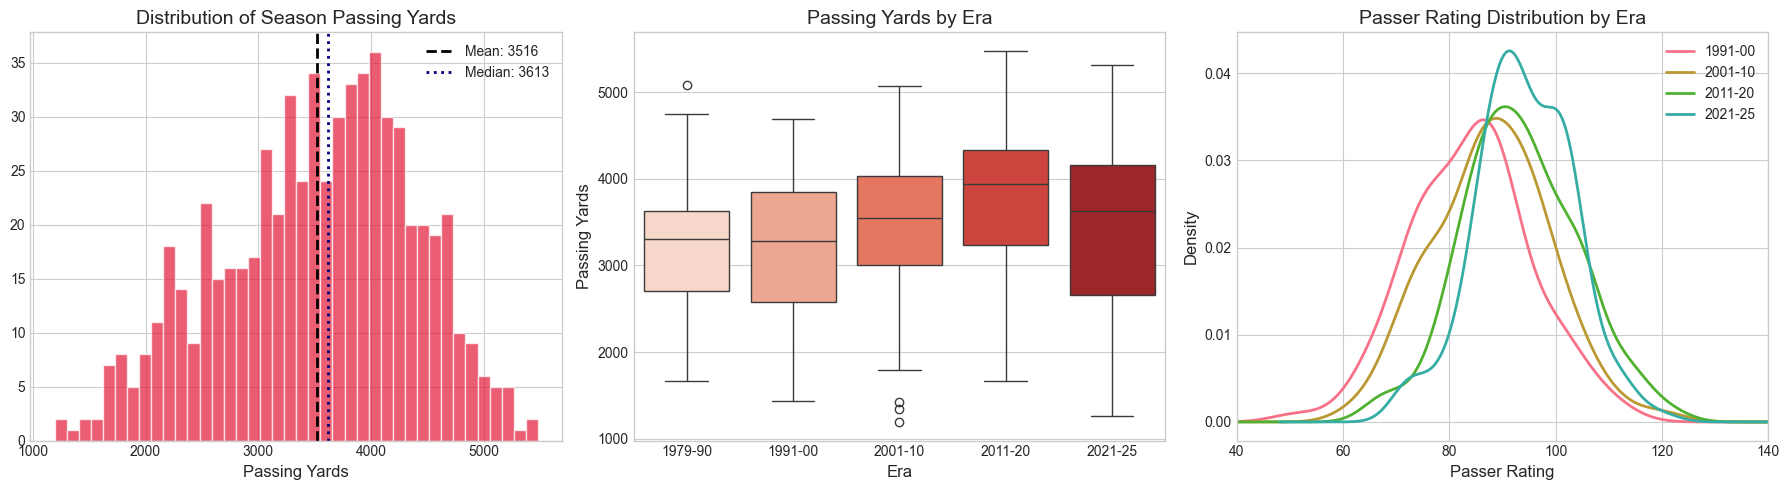

In [6]:
# 2.1 — Distribution of Passing Yards (starters only)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(qb_starters['Yds'].dropna(), bins=40, color=COLORS['QB'], alpha=0.7, edgecolor='white')
axes[0].axvline(qb_starters['Yds'].mean(), color='black', ls='--', lw=2, label=f"Mean: {qb_starters['Yds'].mean():.0f}")
axes[0].axvline(qb_starters['Yds'].median(), color='navy', ls=':', lw=2, label=f"Median: {qb_starters['Yds'].median():.0f}")
axes[0].set_title('Distribution of Season Passing Yards')
axes[0].set_xlabel('Passing Yards')
axes[0].legend()

# Box plot by era
qb_starters['Era'] = pd.cut(qb_starters['Season'], bins=[1978,1990,2000,2010,2020,2026],
                              labels=['1979-90','1991-00','2001-10','2011-20','2021-25'])
sns.boxplot(data=qb_starters, x='Era', y='Yds', ax=axes[1], palette='Reds')
axes[1].set_title('Passing Yards by Era')
axes[1].set_ylabel('Passing Yards')

# KDE of passer rating
for era in ['1991-00', '2001-10', '2011-20', '2021-25']:
    subset = qb_starters[qb_starters['Era'] == era]['Rate'].dropna()
    if len(subset) > 5:
        subset.plot.kde(ax=axes[2], label=era, lw=2)
axes[2].set_title('Passer Rating Distribution by Era')
axes[2].set_xlabel('Passer Rating')
axes[2].legend()
axes[2].set_xlim(40, 140)

plt.tight_layout()
plt.show()

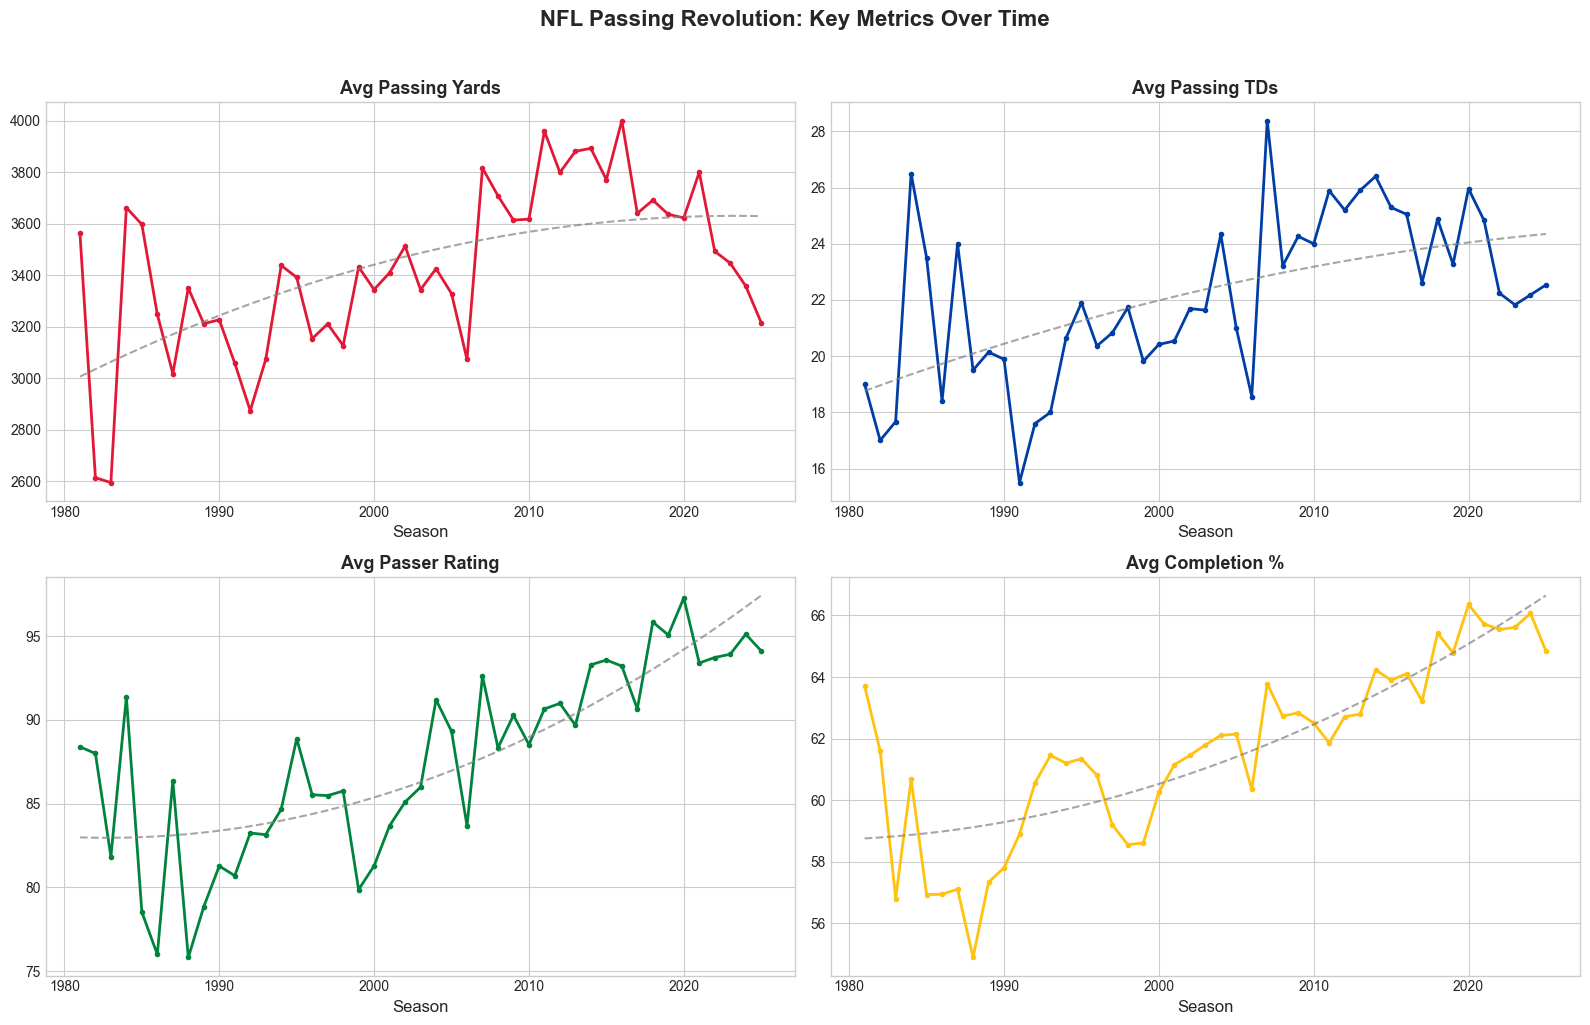

Conclusion: All four metrics show clear upward trends, reflecting the NFL's evolution into a passing-dominant league.


In [7]:
# 2.2 — Passing Stats Trends Over Time
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

yearly = qb_starters.groupby('Season').agg({
    'Yds': 'mean', 'TD': 'mean', 'Rate': 'mean', 'Cmp%': 'mean'
}).reset_index()

for ax, col, title, color in zip(
    axes.flat,
    ['Yds', 'TD', 'Rate', 'Cmp%'],
    ['Avg Passing Yards', 'Avg Passing TDs', 'Avg Passer Rating', 'Avg Completion %'],
    ['#E31837', '#003DA5', '#00843D', '#FFC20E']
):
    ax.plot(yearly['Season'], yearly[col], color=color, lw=2, marker='o', ms=3)
    z = np.polyfit(yearly['Season'].dropna(), yearly[col].dropna(), 2)
    p = np.poly1d(z)
    ax.plot(yearly['Season'], p(yearly['Season']), '--', color='gray', lw=1.5, alpha=0.7)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Season')

plt.suptitle('NFL Passing Revolution: Key Metrics Over Time', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Conclusion: All four metrics show clear upward trends, reflecting the NFL's evolution into a passing-dominant league.")

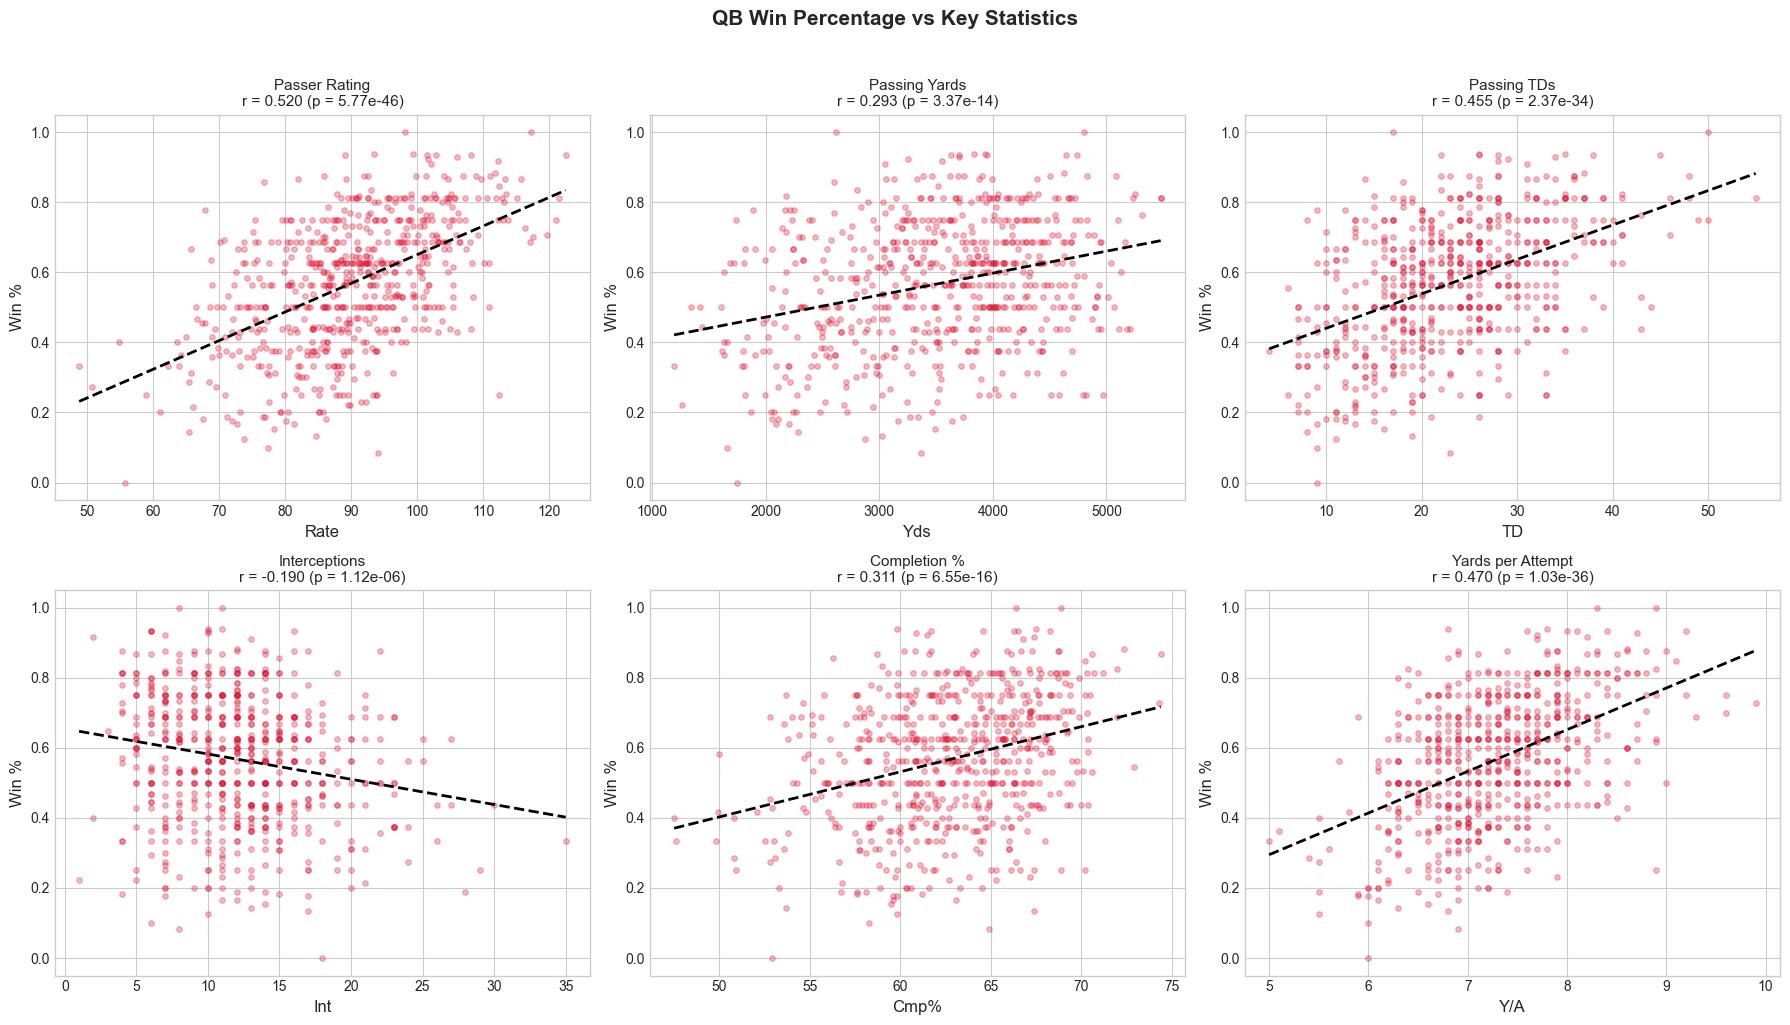

Conclusion: Passer Rating, Yards/Attempt, and Completion % show the strongest positive correlations with winning.
Interceptions show a negative correlation, confirming turnovers hurt winning chances.


In [8]:
# 2.3 — Win Percentage vs Key QB Stats
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

win_stats = [('Rate', 'Passer Rating'), ('Yds', 'Passing Yards'), ('TD', 'Passing TDs'),
             ('Int', 'Interceptions'), ('Cmp%', 'Completion %'), ('Y/A', 'Yards per Attempt')]

valid = qb_starters.dropna(subset=['Win%'])

for ax, (col, title) in zip(axes.flat, win_stats):
    subset = valid.dropna(subset=[col])
    ax.scatter(subset[col], subset['Win%'], alpha=0.3, s=15, color=COLORS['QB'])
    # Trend line
    mask = subset[col].notna() & subset['Win%'].notna()
    if mask.sum() > 10:
        r, p_val = stats.pearsonr(subset.loc[mask, col], subset.loc[mask, 'Win%'])
        z = np.polyfit(subset.loc[mask, col], subset.loc[mask, 'Win%'], 1)
        poly = np.poly1d(z)
        x_range = np.linspace(subset[col].min(), subset[col].max(), 100)
        ax.plot(x_range, poly(x_range), 'k--', lw=2)
        ax.set_title(f'{title}\nr = {r:.3f} (p = {p_val:.2e})', fontsize=11)
    else:
        ax.set_title(title)
    ax.set_ylabel('Win %')
    ax.set_xlabel(col)

plt.suptitle('QB Win Percentage vs Key Statistics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Conclusion: Passer Rating, Yards/Attempt, and Completion % show the strongest positive correlations with winning.")
print("Interceptions show a negative correlation, confirming turnovers hurt winning chances.")

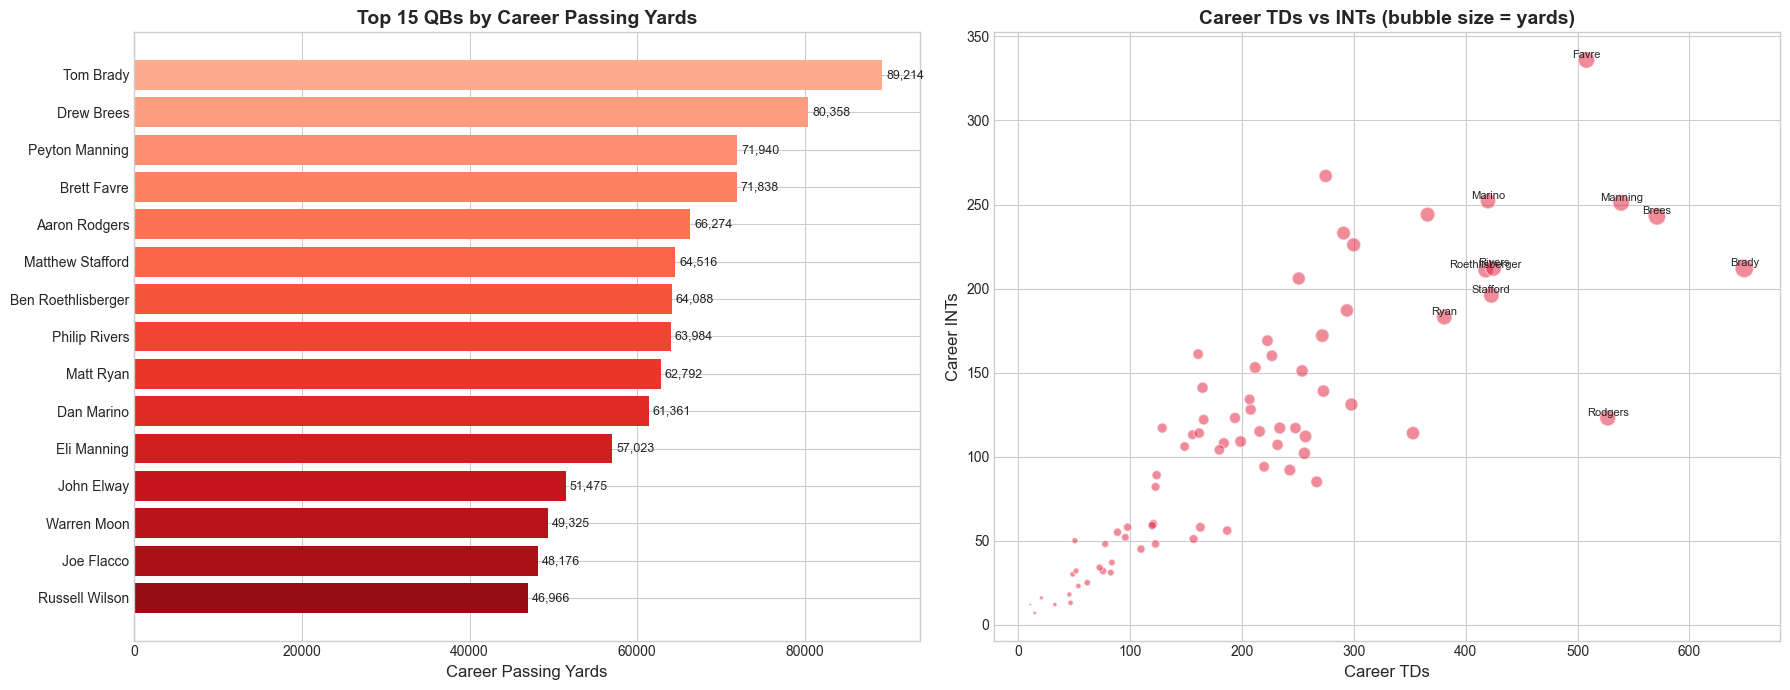

In [9]:
# 2.4 — Career Passing Yards: Top 15 QBs
career = qb.groupby('Player').agg({
    'Yds': 'sum', 'TD': 'sum', 'Int': 'sum', 'GS': 'sum', 'Season': 'count'
}).reset_index().sort_values('Yds', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart
colors_bar = plt.cm.Reds(np.linspace(0.3, 0.9, 15))[::-1]
bars = axes[0].barh(career['Player'][::-1], career['Yds'][::-1], color=colors_bar)
axes[0].set_xlabel('Career Passing Yards')
axes[0].set_title('Top 15 QBs by Career Passing Yards', fontsize=14, fontweight='bold')
for bar, val in zip(bars, career['Yds'][::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9)

# TD vs INT scatter
career_all = qb.groupby('Player').agg({'TD': 'sum', 'Int': 'sum', 'Yds': 'sum'}).reset_index()
axes[1].scatter(career_all['TD'], career_all['Int'], 
                s=career_all['Yds']/500, alpha=0.5, color=COLORS['QB'], edgecolors='white')
# Label top QBs
for _, row in career_all.nlargest(10, 'Yds').iterrows():
    axes[1].annotate(row['Player'].split()[-1], (row['TD'], row['Int']),
                     fontsize=8, ha='center', va='bottom')
axes[1].set_xlabel('Career TDs')
axes[1].set_ylabel('Career INTs')
axes[1].set_title('Career TDs vs INTs (bubble size = yards)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

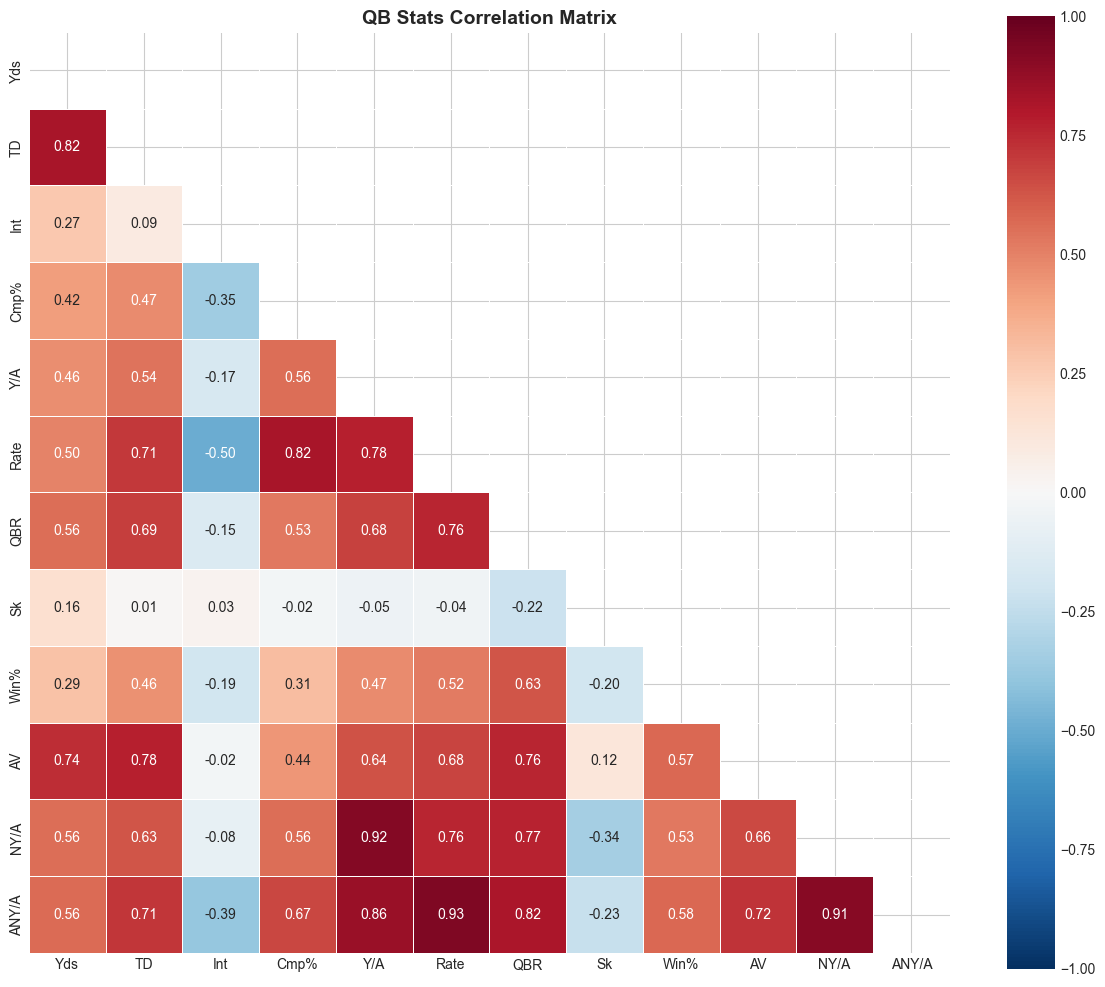

Key correlations with Win%: QBR      0.625717
ANY/A    0.575814
AV       0.573123
NY/A     0.528690
Rate     0.520002


In [10]:
# 2.5 — QB Correlation Heatmap (Key Passing Stats)
corr_cols = ['Yds', 'TD', 'Int', 'Cmp%', 'Y/A', 'Rate', 'QBR', 'Sk', 
             'Win%', 'AV', 'NY/A', 'ANY/A']
corr_cols = [c for c in corr_cols if c in qb_starters.columns]
corr_matrix = qb_starters[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('QB Stats Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Key correlations with Win%:", 
      corr_matrix['Win%'].drop('Win%').sort_values(ascending=False).head(5).to_string())

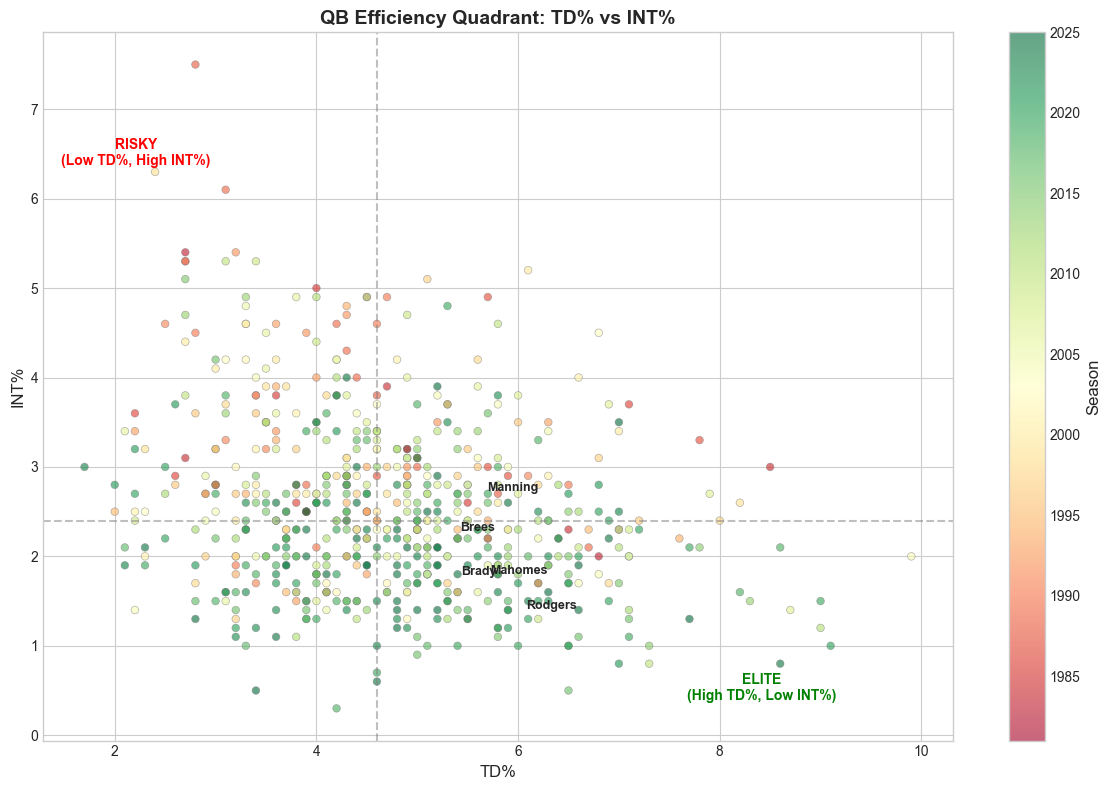

Conclusion: The best QBs cluster in the bottom-right (high TD%, low INT%). Modern QBs trend toward better efficiency.


In [11]:
# 2.6 — TD% vs INT% (Efficiency Quadrant)
fig, ax = plt.subplots(figsize=(12, 8))

valid = qb_starters.dropna(subset=['TD%', 'Int%'])
scatter = ax.scatter(valid['TD%'], valid['Int%'], c=valid['Season'],
                     cmap='RdYlGn', s=30, alpha=0.6, edgecolors='gray', linewidth=0.5)
plt.colorbar(scatter, label='Season')

# Quadrant lines at medians
med_td = valid['TD%'].median()
med_int = valid['Int%'].median()
ax.axhline(med_int, color='gray', ls='--', alpha=0.5)
ax.axvline(med_td, color='gray', ls='--', alpha=0.5)

# Label quadrants
ax.text(valid['TD%'].max()*0.85, valid['Int%'].min()*1.3, 'ELITE\n(High TD%, Low INT%)',
        fontsize=10, ha='center', color='green', fontweight='bold')
ax.text(valid['TD%'].min()*1.3, valid['Int%'].max()*0.85, 'RISKY\n(Low TD%, High INT%)',
        fontsize=10, ha='center', color='red', fontweight='bold')

# Highlight modern stars
stars = ['Patrick Mahomes', 'Tom Brady', 'Aaron Rodgers', 'Peyton Manning', 'Drew Brees']
for _, row in valid[valid['Player'].isin(stars)].groupby('Player')[['TD%','Int%','Season']].mean().iterrows():
    ax.annotate(_.split()[-1], (row['TD%'], row['Int%']), fontsize=9, fontweight='bold')

ax.set_xlabel('TD%', fontsize=12)
ax.set_ylabel('INT%', fontsize=12)
ax.set_title('QB Efficiency Quadrant: TD% vs INT%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Conclusion: The best QBs cluster in the bottom-right (high TD%, low INT%). Modern QBs trend toward better efficiency.")

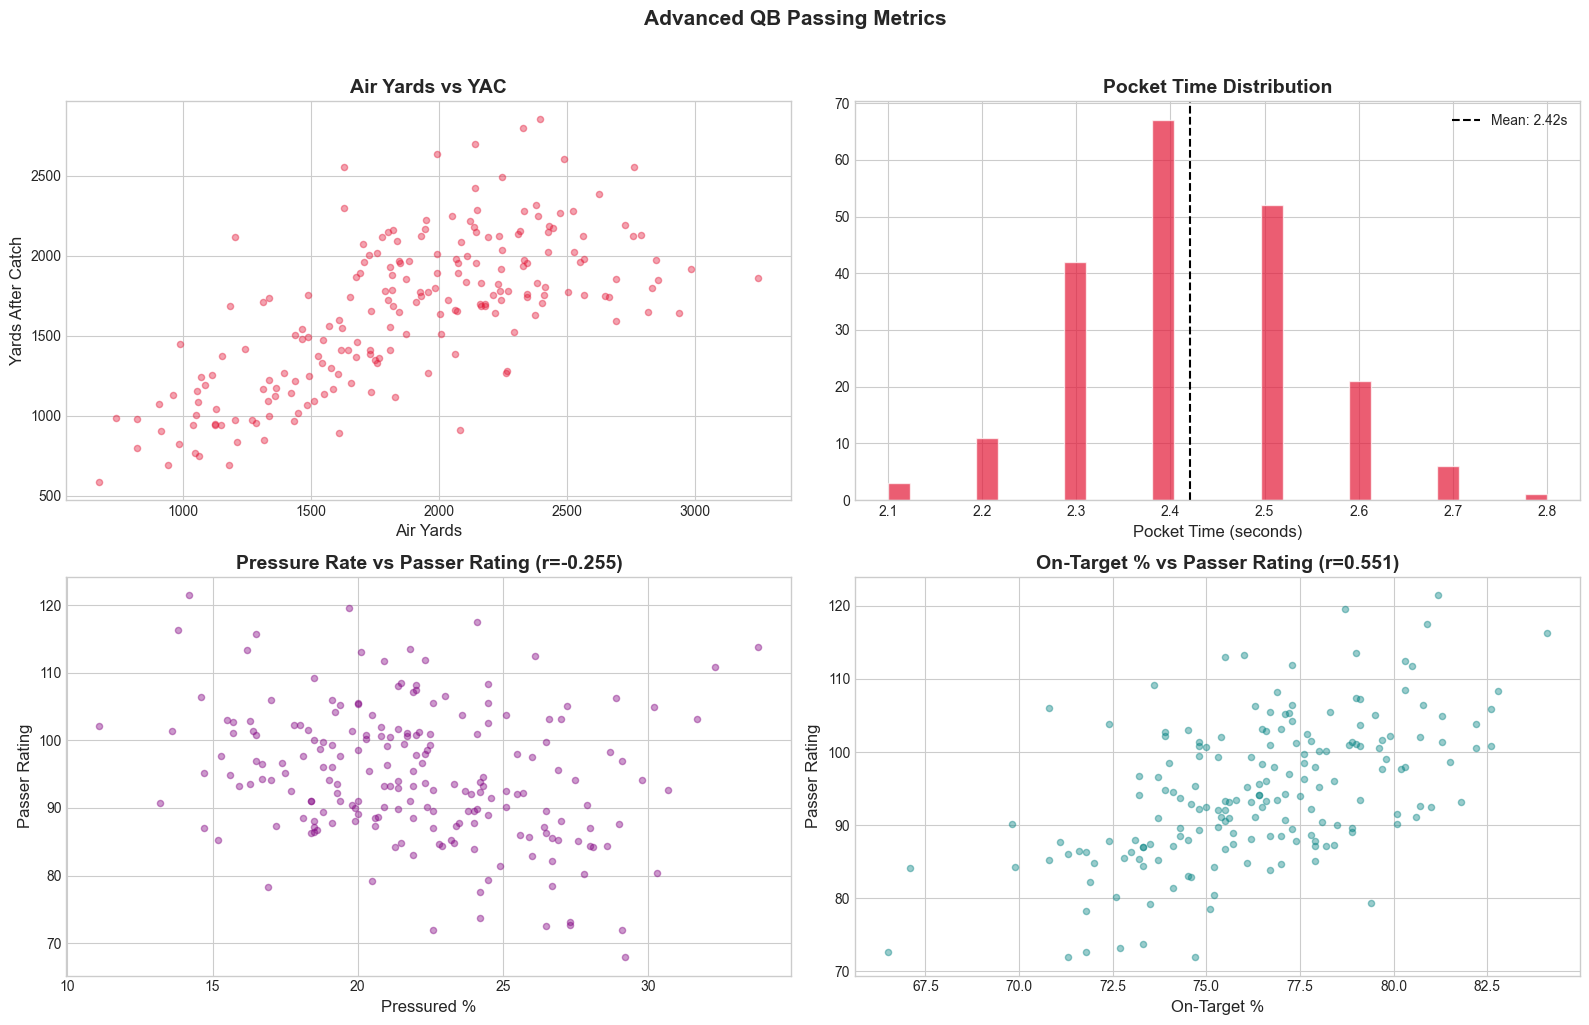

In [12]:
# 2.7 — Advanced Passing Metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Air Yards vs YAC
ax = axes[0, 0]
valid_adv = qb_starters.dropna(subset=['adv_pass_pass_air_yds', 'adv_pass_pass_yac'])
ax.scatter(valid_adv['adv_pass_pass_air_yds'], valid_adv['adv_pass_pass_yac'],
           alpha=0.4, s=20, color=COLORS['QB'])
ax.set_xlabel('Air Yards'); ax.set_ylabel('Yards After Catch')
ax.set_title('Air Yards vs YAC', fontweight='bold')

# Pocket Time distribution
ax = axes[0, 1]
pocket = qb_starters['adv_pass_pocket_time'].dropna()
if len(pocket) > 0:
    ax.hist(pocket, bins=30, color=COLORS['QB'], alpha=0.7, edgecolor='white')
    ax.axvline(pocket.mean(), color='black', ls='--', label=f'Mean: {pocket.mean():.2f}s')
    ax.set_title('Pocket Time Distribution', fontweight='bold')
    ax.set_xlabel('Pocket Time (seconds)')
    ax.legend()

# Pressure rate vs passer rating
ax = axes[1, 0]
valid_p = qb_starters.dropna(subset=['adv_pass_pass_pressured_pct', 'Rate'])
if len(valid_p) > 0:
    ax.scatter(valid_p['adv_pass_pass_pressured_pct'], valid_p['Rate'], alpha=0.4, s=20, color='purple')
    r, _ = stats.pearsonr(valid_p['adv_pass_pass_pressured_pct'], valid_p['Rate'])
    ax.set_title(f'Pressure Rate vs Passer Rating (r={r:.3f})', fontweight='bold')
    ax.set_xlabel('Pressured %')
    ax.set_ylabel('Passer Rating')

# On-target % vs passer rating
ax = axes[1, 1]
valid_ot = qb_starters.dropna(subset=['adv_pass_pass_on_target_pct', 'Rate'])
if len(valid_ot) > 0:
    ax.scatter(valid_ot['adv_pass_pass_on_target_pct'], valid_ot['Rate'], alpha=0.4, s=20, color='teal')
    r, _ = stats.pearsonr(valid_ot['adv_pass_pass_on_target_pct'], valid_ot['Rate'])
    ax.set_title(f'On-Target % vs Passer Rating (r={r:.3f})', fontweight='bold')
    ax.set_xlabel('On-Target %')
    ax.set_ylabel('Passer Rating')

plt.suptitle('Advanced QB Passing Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

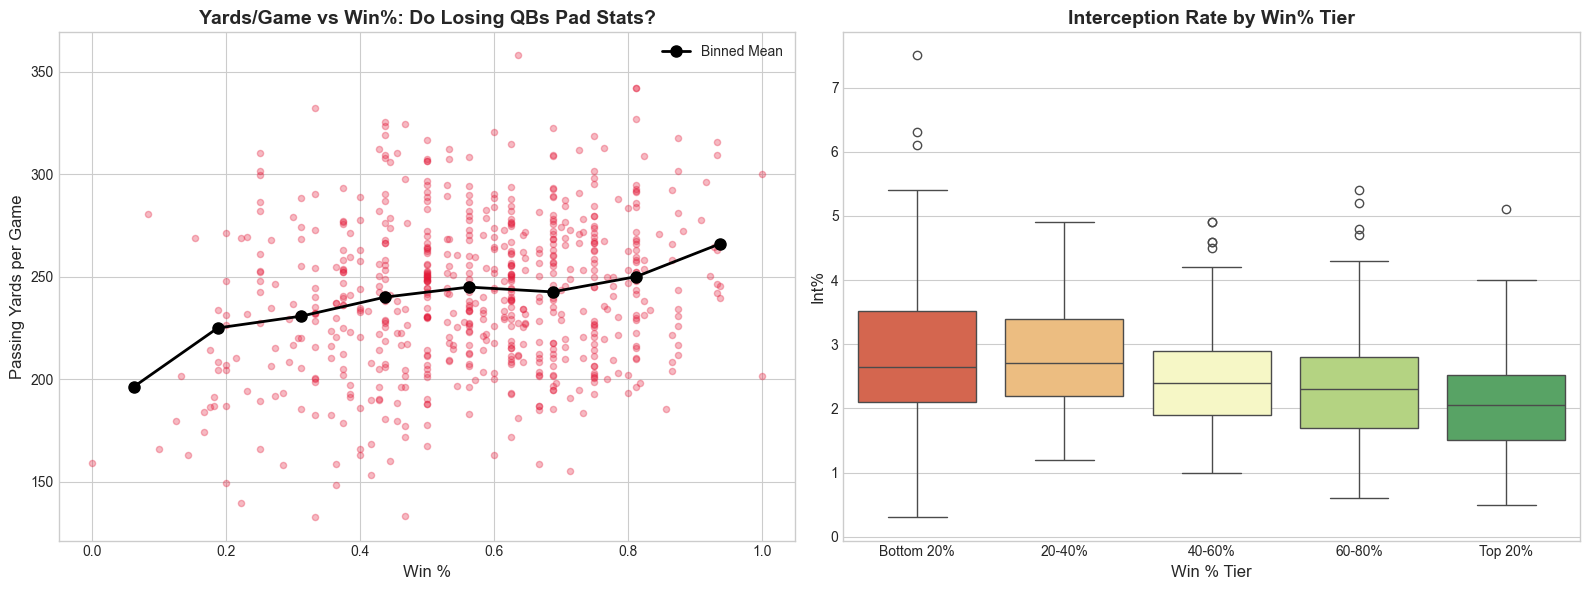

Conclusion: Moderate win% QBs tend to have higher yards/game — losing teams do throw more.
Top winners have the lowest INT rates, confirming ball security as key to winning.


In [13]:
# 2.8 — Stat Padding Analysis: Do Losing QBs Inflate Yards?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

valid = qb_starters.dropna(subset=['Win%', 'Yds', 'GS'])
valid['Yds_per_game'] = valid['Yds'] / valid['GS']

# Yards per game vs Win%
ax = axes[0]
ax.scatter(valid['Win%'], valid['Yds_per_game'], alpha=0.3, s=20, color=COLORS['QB'])
# Bin by win% and show trend
bins = pd.cut(valid['Win%'], bins=8)
binned = valid.groupby(bins, observed=True)['Yds_per_game'].mean()
bin_centers = [(b.left + b.right)/2 for b in binned.index]
ax.plot(bin_centers, binned.values, 'ko-', lw=2, ms=8, label='Binned Mean')
ax.set_xlabel('Win %')
ax.set_ylabel('Passing Yards per Game')
ax.set_title('Yards/Game vs Win%: Do Losing QBs Pad Stats?', fontweight='bold')
ax.legend()

# INT rate by Win% bins
ax = axes[1]
valid_int = qb_starters.dropna(subset=['Win%', 'Int%'])
valid_int['Win_Bin'] = pd.qcut(valid_int['Win%'], q=5, labels=['Bottom 20%','20-40%','40-60%','60-80%','Top 20%'])
sns.boxplot(data=valid_int, x='Win_Bin', y='Int%', palette='RdYlGn', ax=ax)
ax.set_title('Interception Rate by Win% Tier', fontweight='bold')
ax.set_xlabel('Win % Tier')

plt.tight_layout()
plt.show()
print("Conclusion: Moderate win% QBs tend to have higher yards/game — losing teams do throw more.")
print("Top winners have the lowest INT rates, confirming ball security as key to winning.")

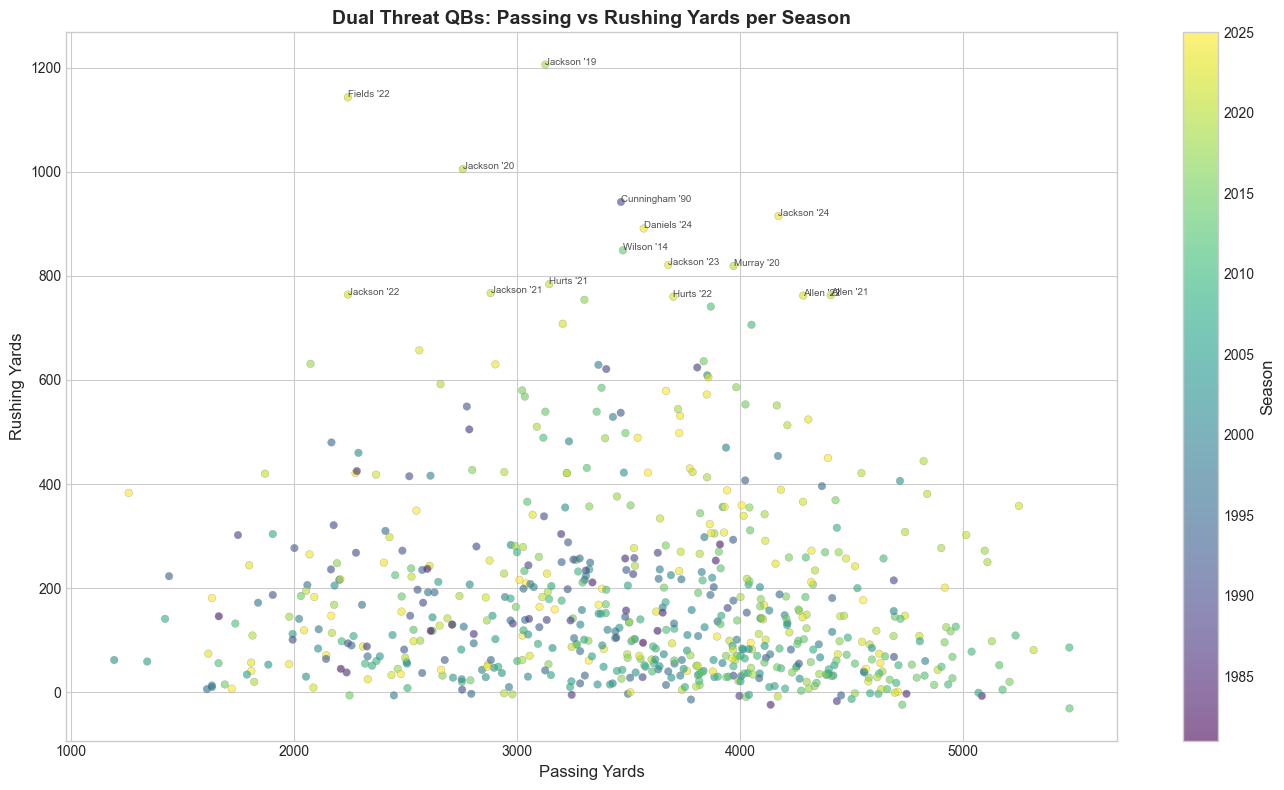

The modern NFL has seen a surge in dual-threat QBs (Lamar Jackson, Josh Allen, Jalen Hurts).


In [14]:
# 2.9 — Dual Threat QBs: Passing Yards vs Rushing Yards
fig, ax = plt.subplots(figsize=(14, 8))

valid_dt = qb_starters.dropna(subset=['Yds', 'rr_Rush_Yds'])
scatter = ax.scatter(valid_dt['Yds'], valid_dt['rr_Rush_Yds'], c=valid_dt['Season'],
                     cmap='viridis', s=30, alpha=0.6, edgecolors='gray', linewidth=0.3)
plt.colorbar(scatter, label='Season')

# Highlight top rushing QBs
top_rush = valid_dt.nlargest(15, 'rr_Rush_Yds')
for _, row in top_rush.iterrows():
    ax.annotate(f"{row['Player'].split()[-1]} '{str(int(row['Season']))[-2:]}",
                (row['Yds'], row['rr_Rush_Yds']), fontsize=7, alpha=0.8)

ax.set_xlabel('Passing Yards', fontsize=12)
ax.set_ylabel('Rushing Yards', fontsize=12)
ax.set_title('Dual Threat QBs: Passing vs Rushing Yards per Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("The modern NFL has seen a surge in dual-threat QBs (Lamar Jackson, Josh Allen, Jalen Hurts).")

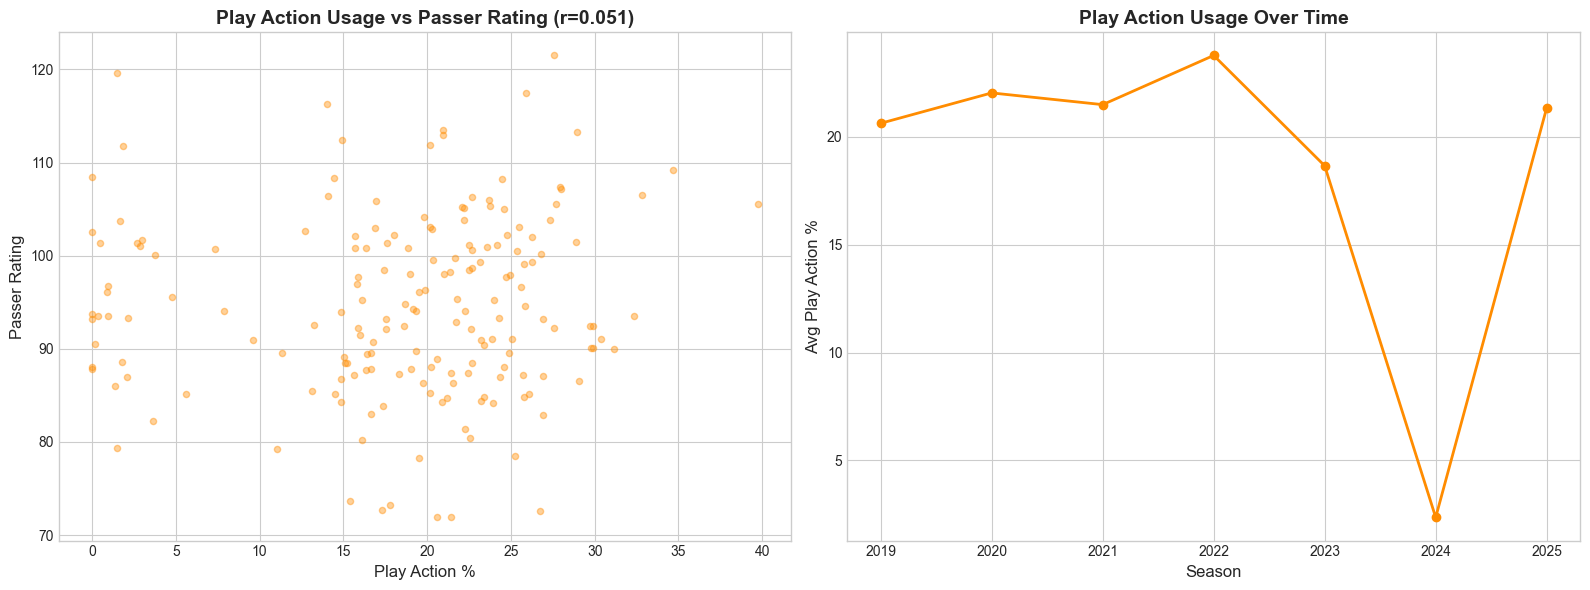

In [15]:
# 2.10 — Play Action vs Non-Play Action Performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pa_cols = ['adv_pass_pass_play_action', 'adv_pass_pass_play_action_pass_yds', 'Att', 'Yds']
valid_pa = qb_starters.dropna(subset=['adv_pass_pass_play_action', 'adv_pass_pass_play_action_pass_yds'])

if len(valid_pa) > 20:
    valid_pa['PA_pct'] = valid_pa['adv_pass_pass_play_action'] / valid_pa['Att'] * 100
    valid_pa['PA_yds_pct'] = valid_pa['adv_pass_pass_play_action_pass_yds'] / valid_pa['Yds'] * 100

    ax = axes[0]
    ax.scatter(valid_pa['PA_pct'], valid_pa['Rate'], alpha=0.4, s=20, color='darkorange')
    r, _ = stats.pearsonr(valid_pa['PA_pct'].dropna(), valid_pa['Rate'].dropna())
    ax.set_xlabel('Play Action %')
    ax.set_ylabel('Passer Rating')
    ax.set_title(f'Play Action Usage vs Passer Rating (r={r:.3f})', fontweight='bold')

    ax = axes[1]
    yearly_pa = valid_pa.groupby('Season')['PA_pct'].mean()
    ax.plot(yearly_pa.index, yearly_pa.values, 'o-', color='darkorange', lw=2)
    ax.set_xlabel('Season')
    ax.set_ylabel('Avg Play Action %')
    ax.set_title('Play Action Usage Over Time', fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'Insufficient play action data', ha='center', va='center', transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, 'Insufficient play action data', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

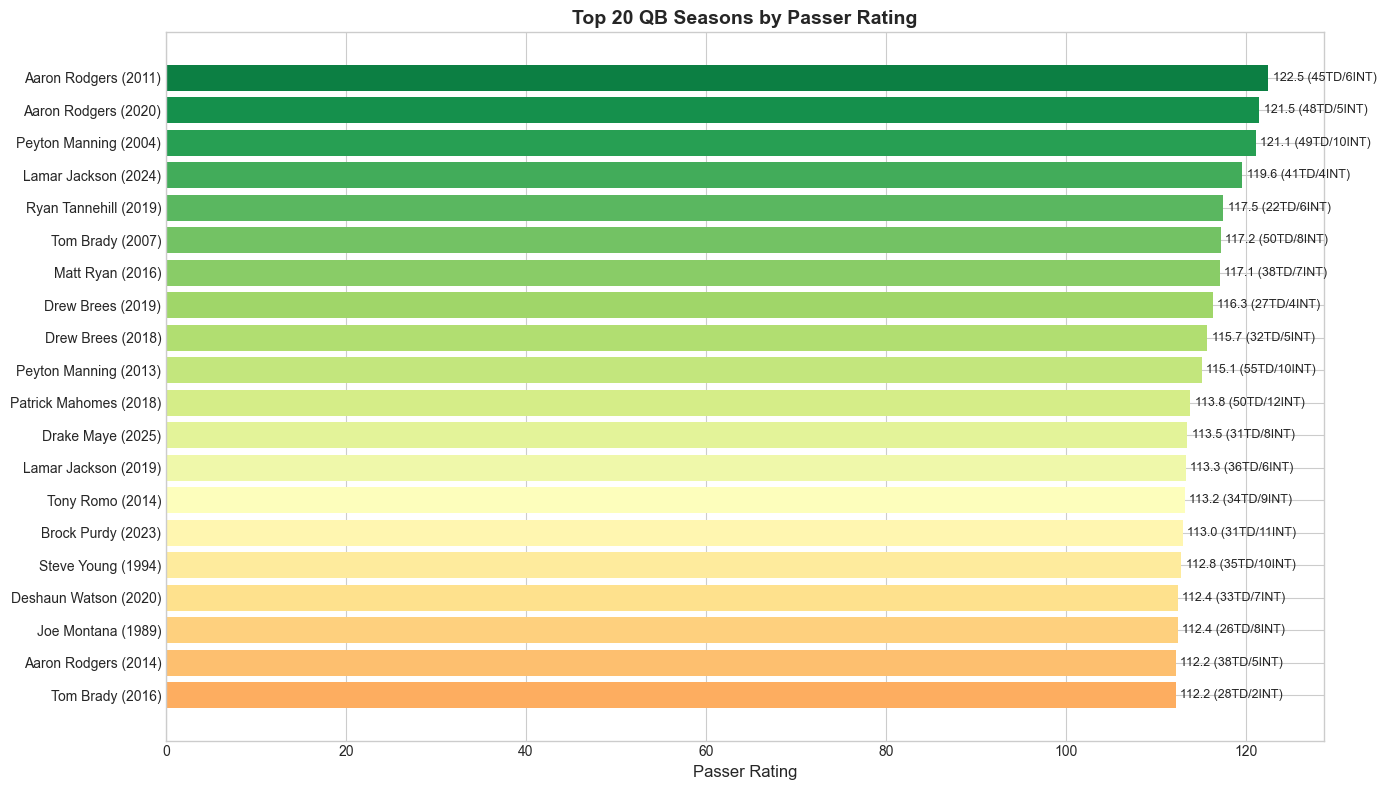

In [16]:
# 2.11 — Greatest QB Seasons by Passer Rating
top_seasons = qb_starters.nlargest(20, 'Rate')[['Player','Season','Team','Yds','TD','Int','Rate','Win%']].copy()
top_seasons['Label'] = top_seasons['Player'] + ' (' + top_seasons['Season'].astype(int).astype(str) + ')'

fig, ax = plt.subplots(figsize=(14, 8))
colors_top = plt.cm.RdYlGn(np.linspace(0.3, 0.95, 20))
bars = ax.barh(top_seasons['Label'][::-1], top_seasons['Rate'][::-1], color=colors_top)
for bar, row in zip(bars, top_seasons.iloc[::-1].itertuples()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{row.Rate:.1f} ({row.TD}TD/{row.Int}INT)', va='center', fontsize=9)
ax.set_xlabel('Passer Rating')
ax.set_title('Top 20 QB Seasons by Passer Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 3. QB Elo Ratings Analysis

The Elo rating system provides a composite measure of QB performance, similar to chess ratings. Higher Elo = better performance relative to peers.

---

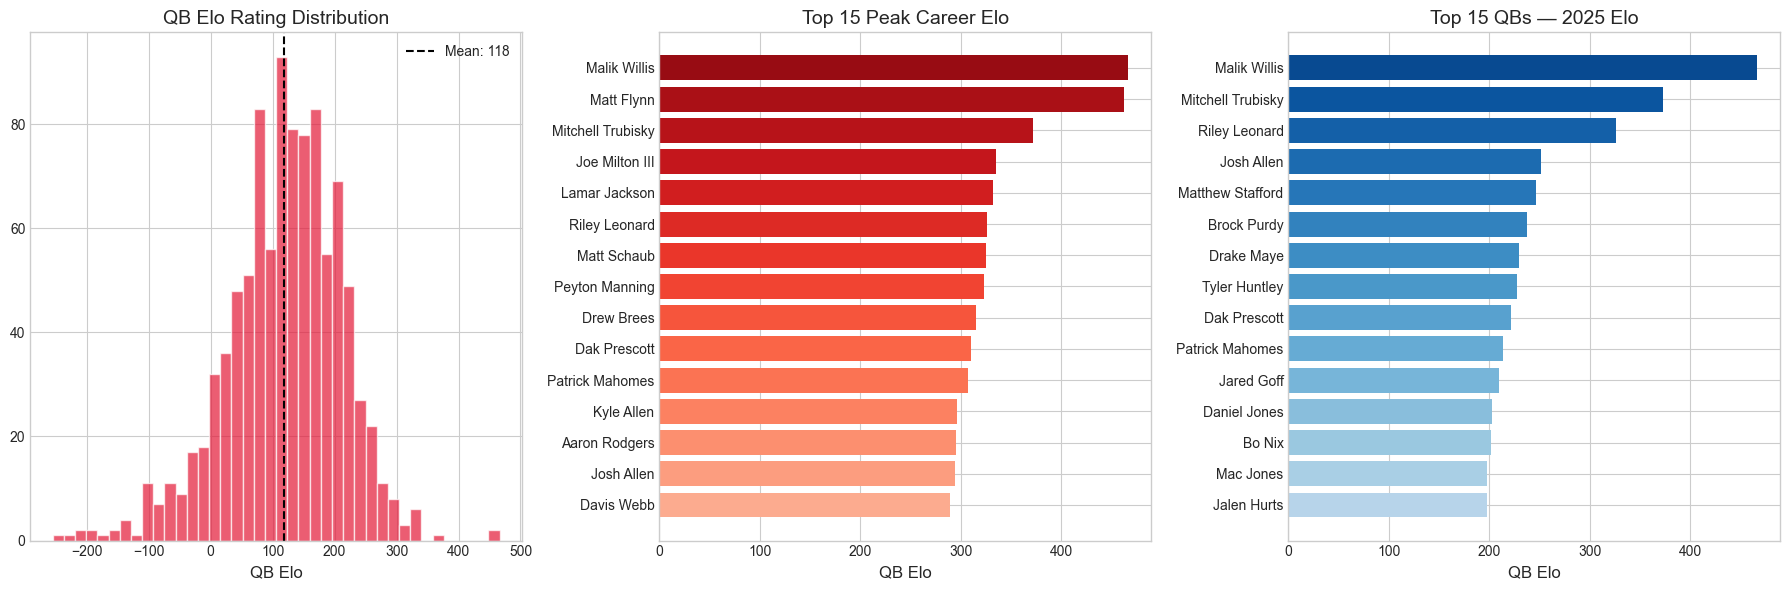

In [17]:
# 3.1 — Elo Distribution & Top QBs
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Distribution
ax = axes[0]
ax.hist(elo_career['QB Elo'].dropna(), bins=40, color=COLORS['QB'], alpha=0.7, edgecolor='white')
ax.axvline(elo_career['QB Elo'].mean(), color='black', ls='--', label=f"Mean: {elo_career['QB Elo'].mean():.0f}")
ax.set_title('QB Elo Rating Distribution')
ax.set_xlabel('QB Elo')
ax.legend()

# Top career Elo
top_elo = elo_career.groupby('QB')['QB Elo'].max().sort_values(ascending=False).head(15)
ax = axes[1]
bars = ax.barh(top_elo.index[::-1], top_elo.values[::-1], color=plt.cm.Reds(np.linspace(0.3,0.9,15)))
ax.set_title('Top 15 Peak Career Elo')
ax.set_xlabel('QB Elo')

# 2025 top QBs
top_2025 = elo_2025.nlargest(15, 'QB Elo')[['QB', 'QB Elo']]
ax = axes[2]
bars = ax.barh(top_2025['QB'][::-1], top_2025['QB Elo'][::-1], color=plt.cm.Blues(np.linspace(0.3,0.9,15)))
ax.set_title('Top 15 QBs — 2025 Elo')
ax.set_xlabel('QB Elo')

plt.tight_layout()
plt.show()

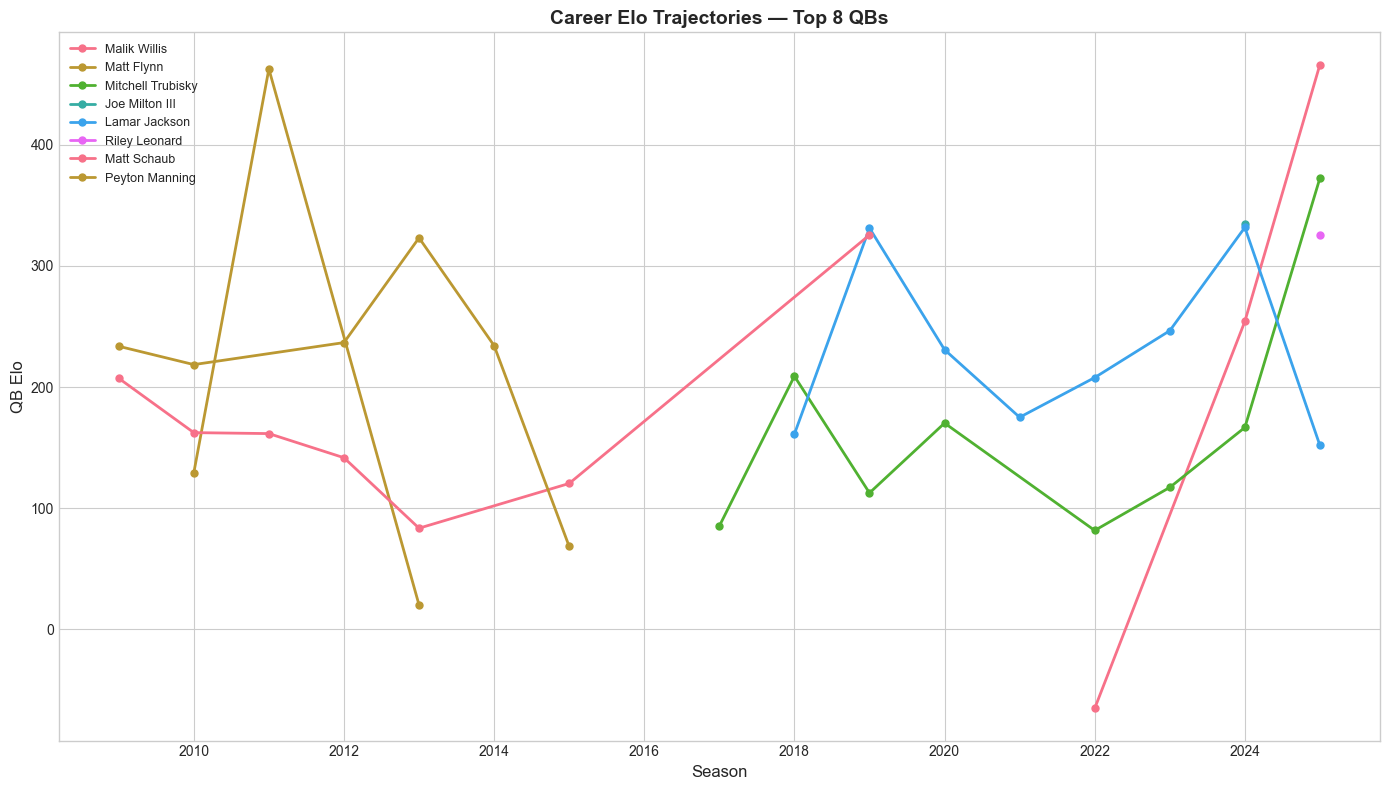

We can see peaks, declines, and the emergence of new talent across seasons.


In [18]:
# 3.2 — Elo Career Trajectories (Top QBs)
fig, ax = plt.subplots(figsize=(14, 8))

top_qbs = elo_career.groupby('QB')['QB Elo'].max().nlargest(8).index
for qb_name in top_qbs:
    player_data = elo_career[elo_career['QB'] == qb_name].sort_values('Season')
    ax.plot(player_data['Season'], player_data['QB Elo'], 'o-', label=qb_name, lw=2, ms=5)

ax.set_xlabel('Season')
ax.set_ylabel('QB Elo')
ax.set_title('Career Elo Trajectories — Top 8 QBs', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()
print("We can see peaks, declines, and the emergence of new talent across seasons.")

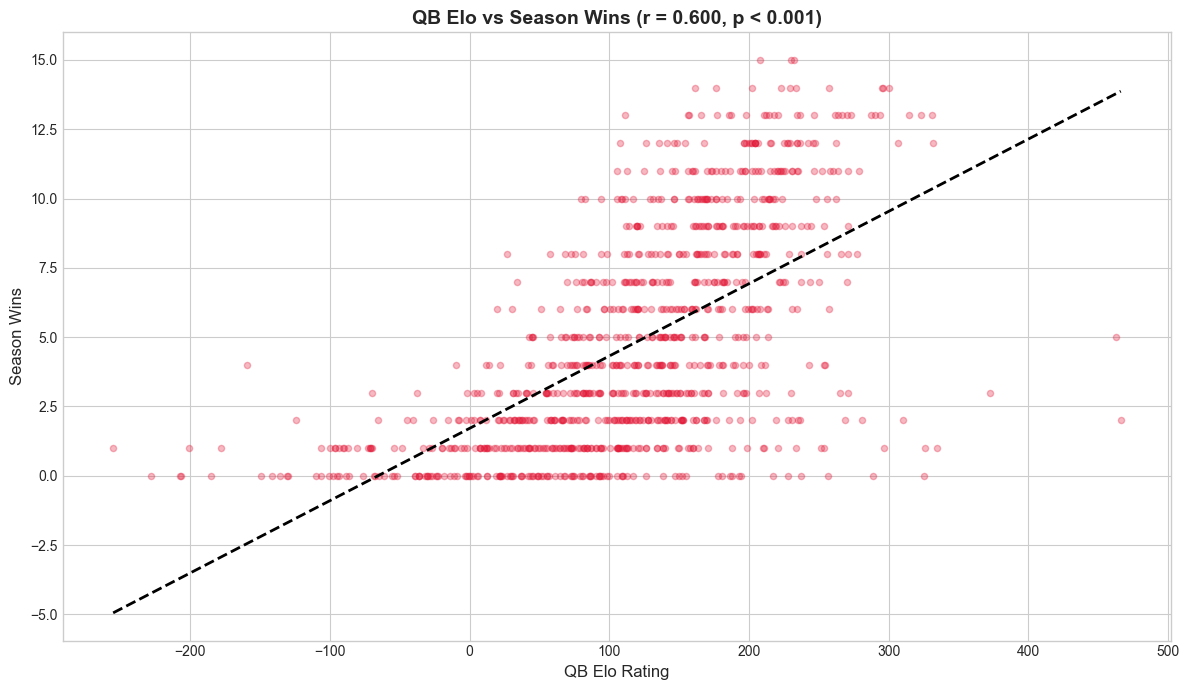

Correlation: r = 0.600 — Higher Elo strongly correlates with more wins.


In [19]:
# 3.3 — Wins vs Elo Rating
fig, ax = plt.subplots(figsize=(12, 7))

elo_wins = elo_career.dropna(subset=['QB Elo', 'W'])
ax.scatter(elo_wins['QB Elo'], elo_wins['W'], alpha=0.3, s=20, color=COLORS['QB'])
r, p = stats.pearsonr(elo_wins['QB Elo'], elo_wins['W'])
z = np.polyfit(elo_wins['QB Elo'], elo_wins['W'], 1)
poly = np.poly1d(z)
x_line = np.linspace(elo_wins['QB Elo'].min(), elo_wins['QB Elo'].max(), 100)
ax.plot(x_line, poly(x_line), 'k--', lw=2)
ax.set_xlabel('QB Elo Rating')
ax.set_ylabel('Season Wins')
ax.set_title(f'QB Elo vs Season Wins (r = {r:.3f}, p < 0.001)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Correlation: r = {r:.3f} — Higher Elo strongly correlates with more wins.")

---
# 4. Running Back (RB) Analysis

Running backs are the workhorse of the offense. We'll analyze rushing efficiency, the pass-catching evolution, workload effects, and career arcs.

---

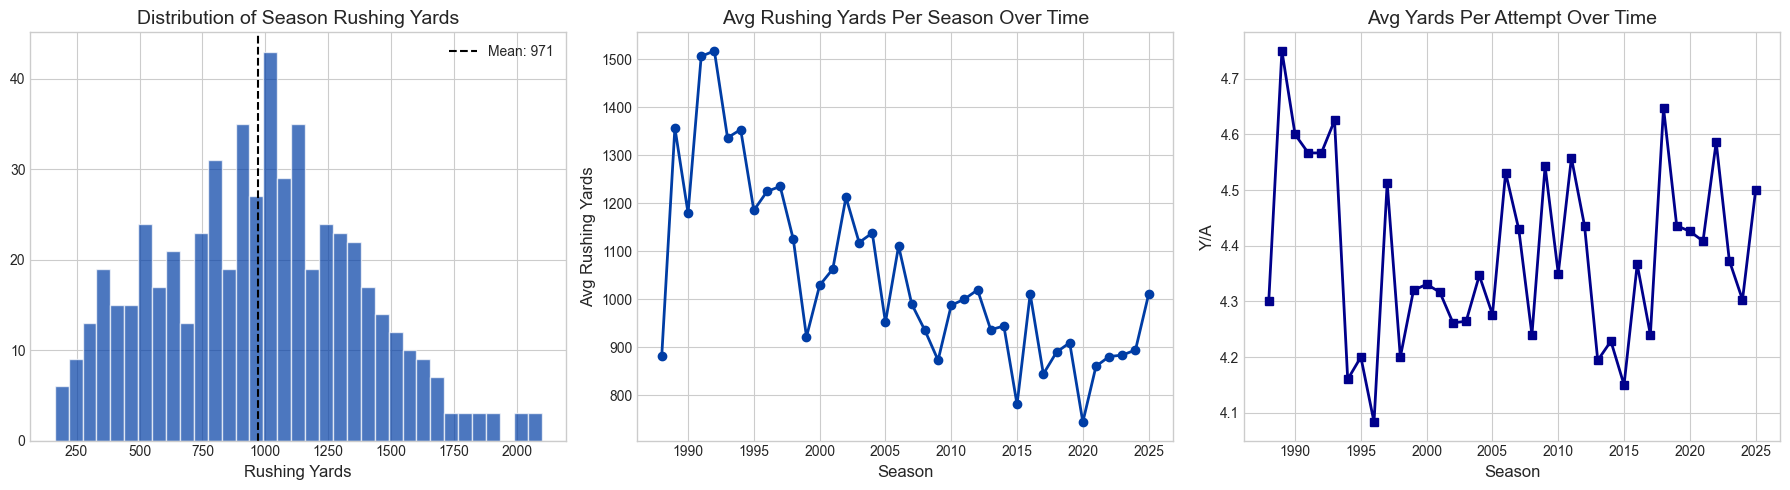

In [20]:
# 4.1 — RB Rushing Yards Distribution & Trends
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution
ax = axes[0]
ax.hist(rb_starters['Rush_Yds'].dropna(), bins=35, color=COLORS['RB'], alpha=0.7, edgecolor='white')
ax.axvline(rb_starters['Rush_Yds'].mean(), color='black', ls='--', label=f"Mean: {rb_starters['Rush_Yds'].mean():.0f}")
ax.set_title('Distribution of Season Rushing Yards')
ax.set_xlabel('Rushing Yards')
ax.legend()

# Trend over time
ax = axes[1]
yearly_rb = rb_starters.groupby('Season').agg({'Rush_Yds': 'mean', 'Rush_Y/A': 'mean'}).reset_index()
ax.plot(yearly_rb['Season'], yearly_rb['Rush_Yds'], 'o-', color=COLORS['RB'], lw=2)
ax.set_title('Avg Rushing Yards Per Season Over Time')
ax.set_xlabel('Season')
ax.set_ylabel('Avg Rushing Yards')

# Rushing Y/A trend
ax = axes[2]
ax.plot(yearly_rb['Season'], yearly_rb['Rush_Y/A'], 's-', color='darkblue', lw=2)
ax.set_title('Avg Yards Per Attempt Over Time')
ax.set_xlabel('Season')
ax.set_ylabel('Y/A')

plt.tight_layout()
plt.show()

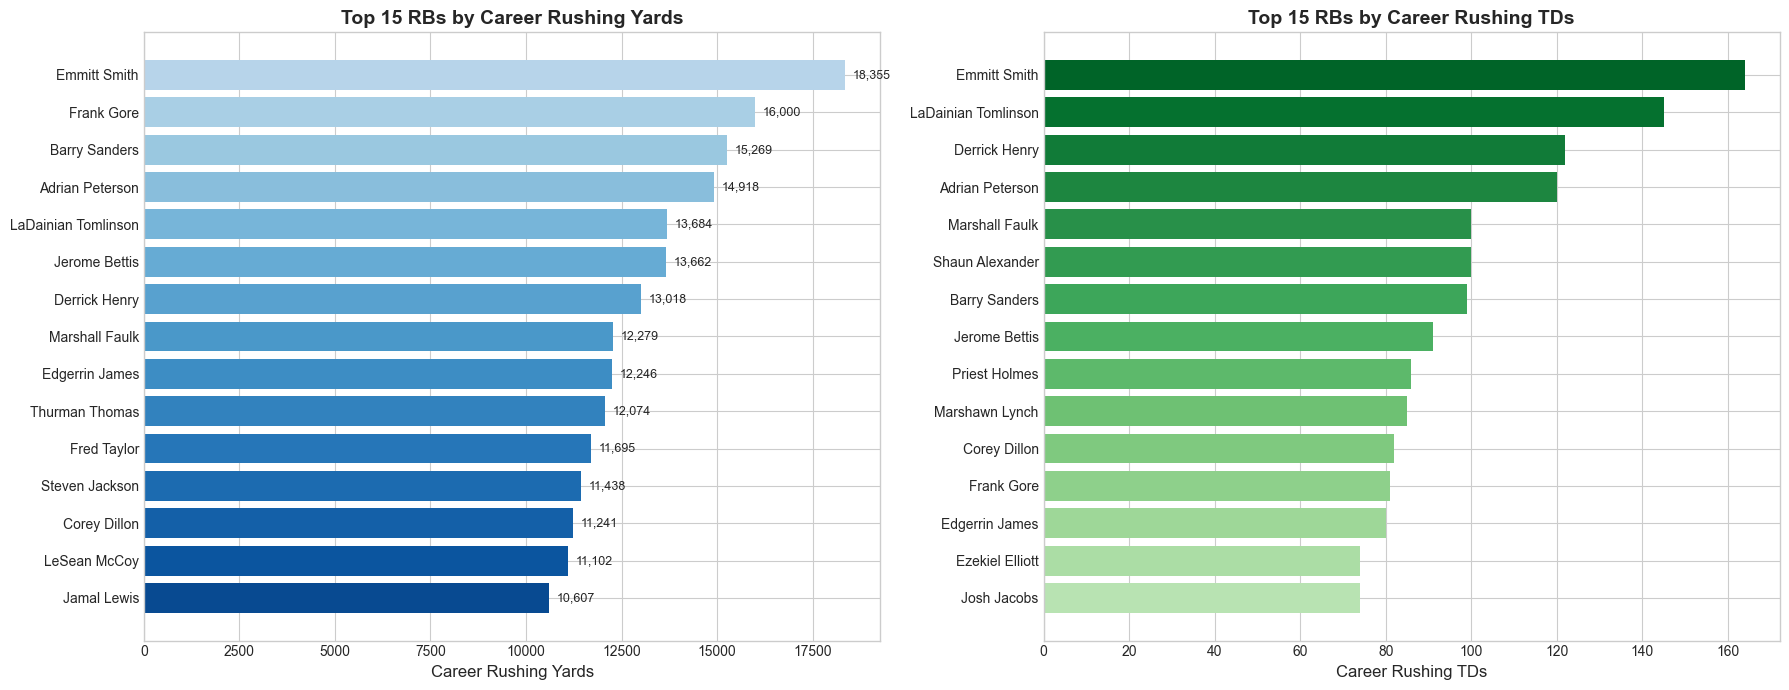

In [21]:
# 4.2 — Top 15 Career Rushing Yards
rb_career = rb.groupby('Player').agg({
    'Rush_Yds': 'sum', 'Rush_TD': 'sum', 'Rush_Att': 'sum', 'Rec_Yds': 'sum',
    'GS': 'sum', 'Season': 'count'
}).reset_index()
rb_career['Rush_Y/A_career'] = rb_career['Rush_Yds'] / rb_career['Rush_Att']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top15 = rb_career.nlargest(15, 'Rush_Yds')
colors_bar = plt.cm.Blues(np.linspace(0.3, 0.9, 15))[::-1]
bars = axes[0].barh(top15['Player'][::-1], top15['Rush_Yds'][::-1], color=colors_bar)
for bar, val in zip(bars, top15['Rush_Yds'][::-1]):
    axes[0].text(bar.get_width()+200, bar.get_y()+bar.get_height()/2, f'{val:,.0f}', va='center', fontsize=9)
axes[0].set_xlabel('Career Rushing Yards')
axes[0].set_title('Top 15 RBs by Career Rushing Yards', fontweight='bold')

# Rushing TDs
top15_td = rb_career.nlargest(15, 'Rush_TD')
bars = axes[1].barh(top15_td['Player'][::-1], top15_td['Rush_TD'][::-1],
                     color=plt.cm.Greens(np.linspace(0.3, 0.9, 15)))
axes[1].set_xlabel('Career Rushing TDs')
axes[1].set_title('Top 15 RBs by Career Rushing TDs', fontweight='bold')

plt.tight_layout()
plt.show()

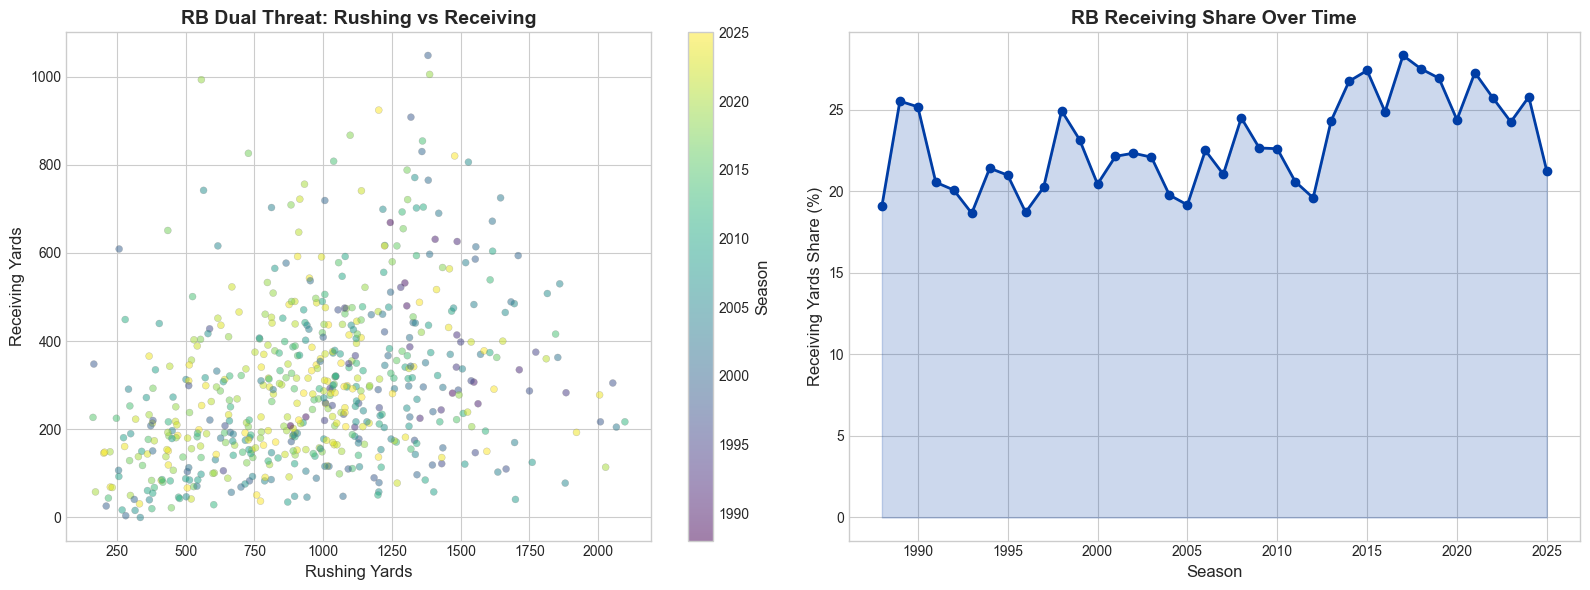

Conclusion: Modern RBs catch more passes than ever. The receiving share has steadily increased.


In [22]:
# 4.3 — RB Dual Threat: Rushing vs Receiving
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
ax = axes[0]
valid_rb = rb_starters.dropna(subset=['Rush_Yds', 'Rec_Yds'])
scatter = ax.scatter(valid_rb['Rush_Yds'], valid_rb['Rec_Yds'], c=valid_rb['Season'],
                     cmap='viridis', s=25, alpha=0.5, edgecolors='gray', linewidth=0.3)
plt.colorbar(scatter, ax=ax, label='Season')
ax.set_xlabel('Rushing Yards')
ax.set_ylabel('Receiving Yards')
ax.set_title('RB Dual Threat: Rushing vs Receiving', fontweight='bold')

# Receiving share over time (what % of RB yards come from receiving?)
ax = axes[1]
rb_starters_valid = rb_starters.dropna(subset=['Rush_Yds', 'Rec_Yds']).copy()
rb_starters_valid['Rec_Share'] = rb_starters_valid['Rec_Yds'] / (rb_starters_valid['Rush_Yds'] + rb_starters_valid['Rec_Yds']) * 100
yearly_rec = rb_starters_valid.groupby('Season')['Rec_Share'].mean()
ax.plot(yearly_rec.index, yearly_rec.values, 'o-', color=COLORS['RB'], lw=2)
ax.fill_between(yearly_rec.index, yearly_rec.values, alpha=0.2, color=COLORS['RB'])
ax.set_xlabel('Season')
ax.set_ylabel('Receiving Yards Share (%)')
ax.set_title('RB Receiving Share Over Time', fontweight='bold')

plt.tight_layout()
plt.show()
print("Conclusion: Modern RBs catch more passes than ever. The receiving share has steadily increased.")

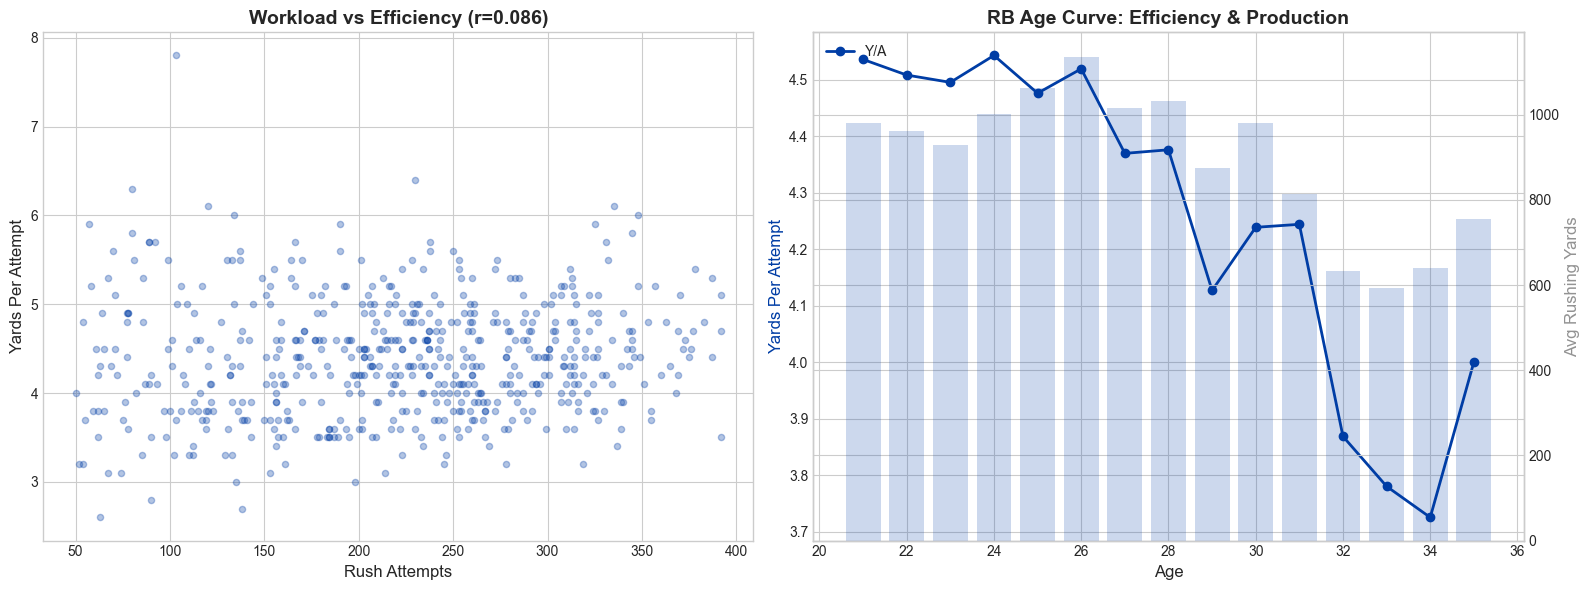

Running backs typically peak at age 25–27 and decline rapidly after 28.


In [23]:
# 4.4 — RB Workload vs Efficiency
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Attempts vs Y/A
ax = axes[0]
valid_rb_eff = rb_starters.dropna(subset=['Rush_Att', 'Rush_Y/A'])
ax.scatter(valid_rb_eff['Rush_Att'], valid_rb_eff['Rush_Y/A'], alpha=0.3, s=20, color=COLORS['RB'])
r, _ = stats.pearsonr(valid_rb_eff['Rush_Att'], valid_rb_eff['Rush_Y/A'])
ax.set_xlabel('Rush Attempts')
ax.set_ylabel('Yards Per Attempt')
ax.set_title(f'Workload vs Efficiency (r={r:.3f})', fontweight='bold')

# Age curve
ax = axes[1]
age_stats = rb_starters.groupby('Age').agg({'Rush_Y/A': 'mean', 'Rush_Yds': 'mean'}).reset_index()
age_stats = age_stats[(age_stats['Age'] >= 20) & (age_stats['Age'] <= 35)]
ax.plot(age_stats['Age'], age_stats['Rush_Y/A'], 'o-', color=COLORS['RB'], lw=2, label='Y/A')
ax2 = ax.twinx()
ax2.bar(age_stats['Age'], age_stats['Rush_Yds'], alpha=0.2, color=COLORS['RB'], label='Avg Rush Yds')
ax.set_xlabel('Age')
ax.set_ylabel('Yards Per Attempt', color=COLORS['RB'])
ax2.set_ylabel('Avg Rushing Yards', alpha=0.5)
ax.set_title('RB Age Curve: Efficiency & Production', fontweight='bold')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()
print("Running backs typically peak at age 25–27 and decline rapidly after 28.")

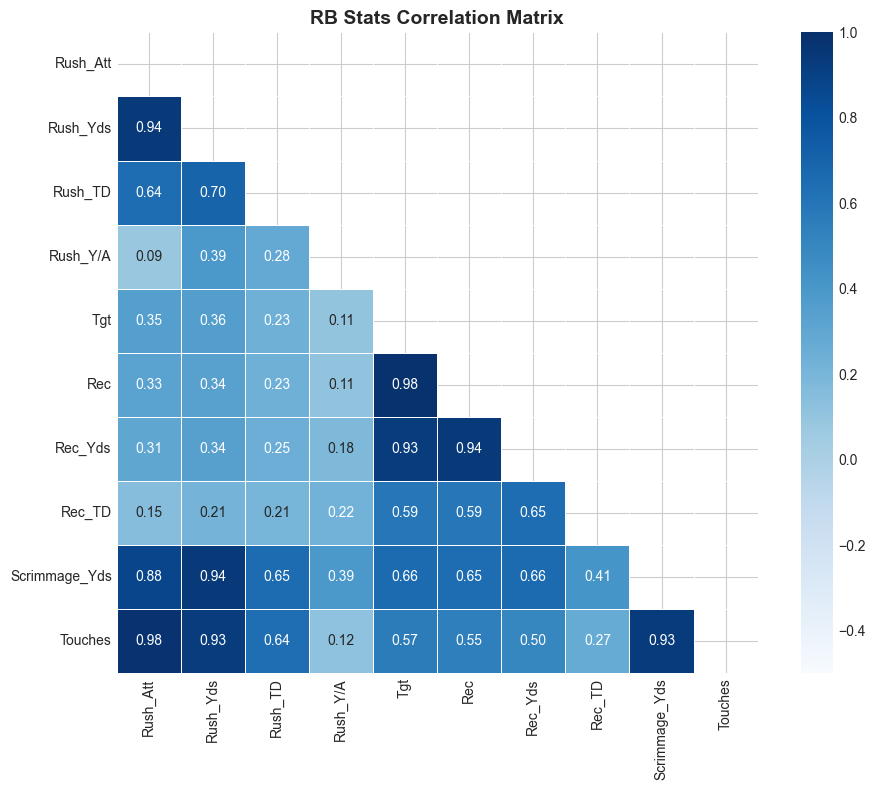

In [24]:
# 4.5 — RB Correlation Heatmap
rb_corr_cols = ['Rush_Att', 'Rush_Yds', 'Rush_TD', 'Rush_Y/A', 'Tgt', 'Rec', 
                'Rec_Yds', 'Rec_TD', 'Scrimmage_Yds', 'Touches']
rb_corr_cols = [c for c in rb_corr_cols if c in rb_starters.columns]
corr = rb_starters[rb_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues', vmin=-0.5, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('RB Stats Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

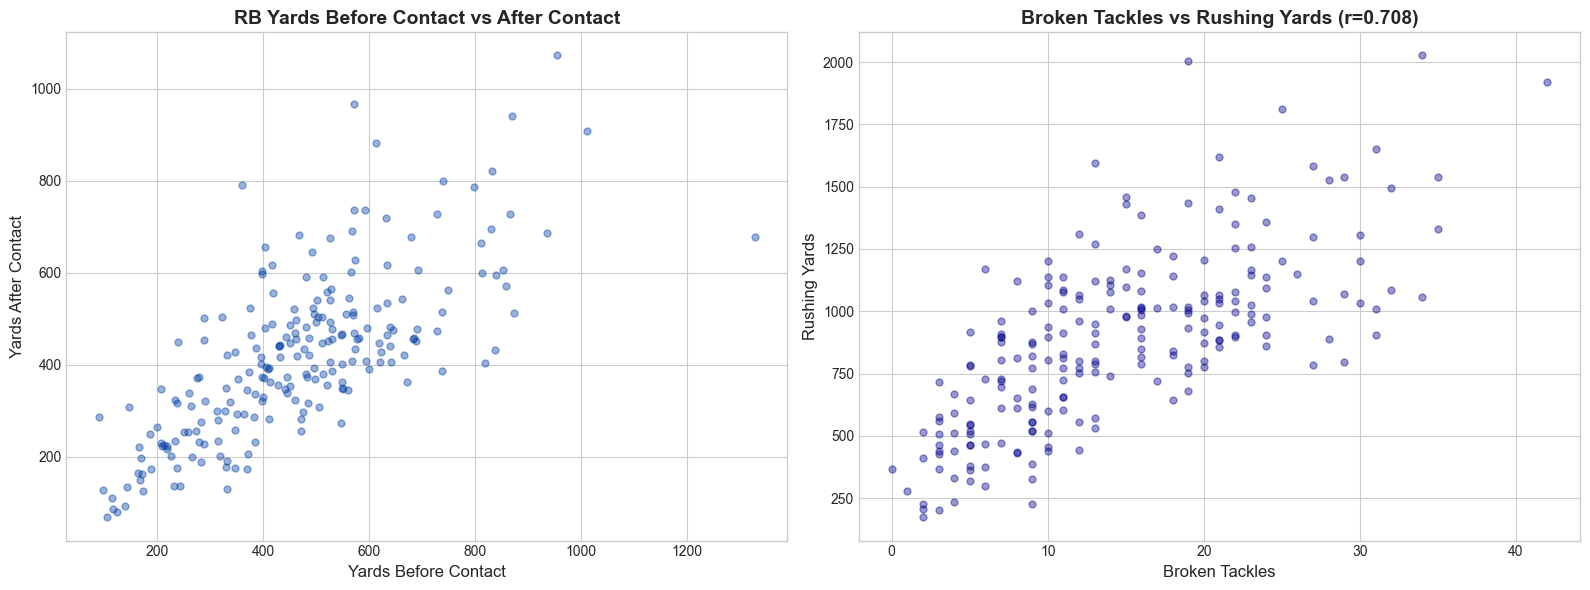

In [25]:
# 4.6 — Advanced RB Metrics: Yards Before/After Contact
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

adv_rb_cols = ['adv_Rush_YBC', 'adv_Rush_YAC', 'adv_Rush_BrkTkl']
valid_adv_rb = rb_starters.dropna(subset=['adv_Rush_YBC', 'adv_Rush_YAC'])

if len(valid_adv_rb) > 10:
    # YBC vs YAC
    ax = axes[0]
    ax.scatter(valid_adv_rb['adv_Rush_YBC'], valid_adv_rb['adv_Rush_YAC'],
               alpha=0.4, s=25, color=COLORS['RB'])
    ax.set_xlabel('Yards Before Contact')
    ax.set_ylabel('Yards After Contact')
    ax.set_title('RB Yards Before Contact vs After Contact', fontweight='bold')

    # Broken tackles vs Rush Yds
    ax = axes[1]
    valid_bt = rb_starters.dropna(subset=['adv_Rush_BrkTkl', 'Rush_Yds'])
    if len(valid_bt) > 10:
        ax.scatter(valid_bt['adv_Rush_BrkTkl'], valid_bt['Rush_Yds'],
                   alpha=0.4, s=25, color='darkblue')
        r, _ = stats.pearsonr(valid_bt['adv_Rush_BrkTkl'], valid_bt['Rush_Yds'])
        ax.set_xlabel('Broken Tackles')
        ax.set_ylabel('Rushing Yards')
        ax.set_title(f'Broken Tackles vs Rushing Yards (r={r:.3f})', fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'Insufficient advanced data', ha='center', va='center', transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, 'Insufficient advanced data', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

---
# 5. Wide Receiver (WR) Analysis

Wide receivers are the primary targets in the modern passing game. With 1,617 unique receivers in our dataset, we have the richest data for analysis. Key focus areas: target share, advanced efficiency metrics, situational performance, and the impact of QB context.

---

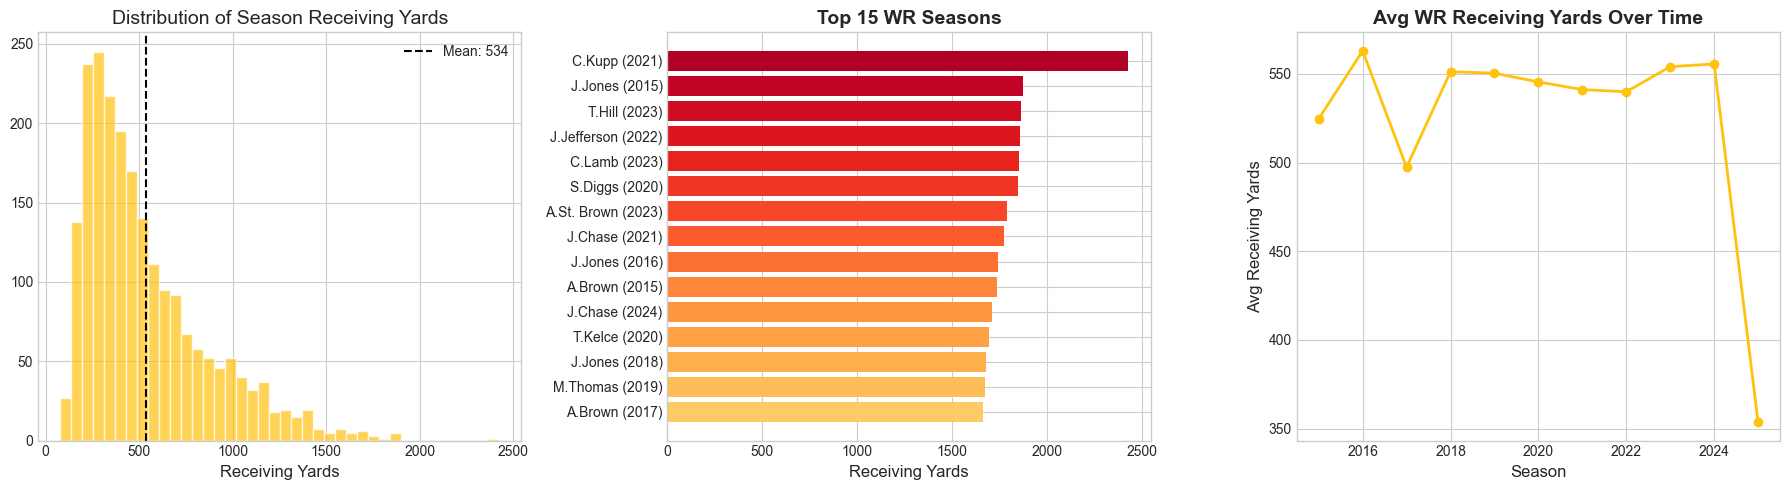

In [26]:
# 5.1 — WR Receiving Yards Distribution & Top Players
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution
ax = axes[0]
ax.hist(wr_starters['receiving_yards'].dropna(), bins=40, color=COLORS['WR'], alpha=0.7, edgecolor='white')
ax.axvline(wr_starters['receiving_yards'].mean(), color='black', ls='--', 
           label=f"Mean: {wr_starters['receiving_yards'].mean():.0f}")
ax.set_title('Distribution of Season Receiving Yards')
ax.set_xlabel('Receiving Yards')
ax.legend()

# Top 15 single seasons
top_wr = wr_starters.nlargest(15, 'receiving_yards')[['receiver_player_name','season','receiving_yards']]
top_wr['Label'] = top_wr['receiver_player_name'] + ' (' + top_wr['season'].astype(str) + ')'
ax = axes[1]
bars = ax.barh(top_wr['Label'][::-1], top_wr['receiving_yards'][::-1],
               color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, 15)))
ax.set_xlabel('Receiving Yards')
ax.set_title('Top 15 WR Seasons', fontweight='bold')

# Yearly trend
ax = axes[2]
yearly_wr = wr_starters.groupby('season')['receiving_yards'].mean()
ax.plot(yearly_wr.index, yearly_wr.values, 'o-', color=COLORS['WR'], lw=2)
ax.set_xlabel('Season')
ax.set_ylabel('Avg Receiving Yards')
ax.set_title('Avg WR Receiving Yards Over Time', fontweight='bold')

plt.tight_layout()
plt.show()

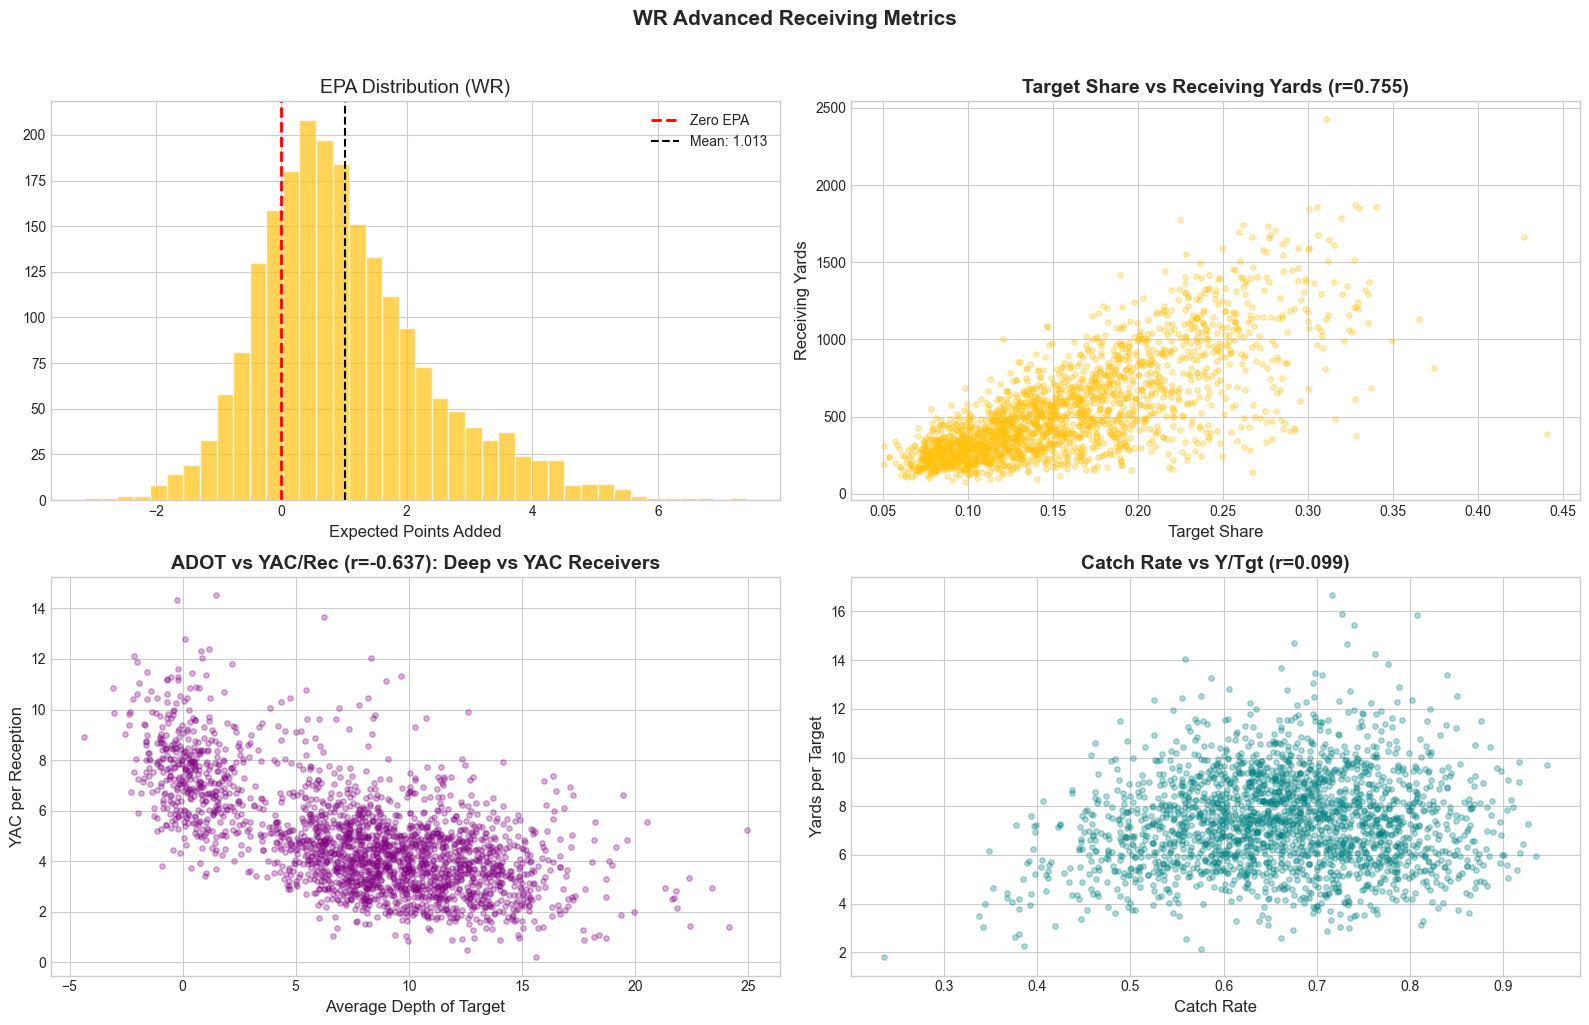

In [27]:
# 5.2 — WR Advanced Metrics: EPA & Target Share
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# EPA distribution
ax = axes[0, 0]
ax.hist(wr_starters['epa'].dropna(), bins=40, color=COLORS['WR'], alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', ls='--', lw=2, label='Zero EPA')
ax.axvline(wr_starters['epa'].mean(), color='black', ls='--', label=f"Mean: {wr_starters['epa'].mean():.3f}")
ax.set_title('EPA Distribution (WR)')
ax.set_xlabel('Expected Points Added')
ax.legend()

# Target Share vs Yards
ax = axes[0, 1]
valid_ts = wr_starters.dropna(subset=['target_share', 'receiving_yards'])
ax.scatter(valid_ts['target_share'], valid_ts['receiving_yards'], alpha=0.3, s=15, color=COLORS['WR'])
r, _ = stats.pearsonr(valid_ts['target_share'], valid_ts['receiving_yards'])
ax.set_xlabel('Target Share')
ax.set_ylabel('Receiving Yards')
ax.set_title(f'Target Share vs Receiving Yards (r={r:.3f})', fontweight='bold')

# ADOT vs YAC
ax = axes[1, 0]
valid_ay = wr_starters.dropna(subset=['adot', 'yac_per_reception'])
if len(valid_ay) > 20:
    ax.scatter(valid_ay['adot'], valid_ay['yac_per_reception'], alpha=0.3, s=15, color='purple')
    r, _ = stats.pearsonr(valid_ay['adot'], valid_ay['yac_per_reception'])
    ax.set_xlabel('Average Depth of Target')
    ax.set_ylabel('YAC per Reception')
    ax.set_title(f'ADOT vs YAC/Rec (r={r:.3f}): Deep vs YAC Receivers', fontweight='bold')

# Catch Rate vs Yards/Target
ax = axes[1, 1]
valid_cr = wr_starters.dropna(subset=['catch_rate', 'yards_per_target'])
if len(valid_cr) > 20:
    ax.scatter(valid_cr['catch_rate'], valid_cr['yards_per_target'], alpha=0.3, s=15, color='teal')
    r, _ = stats.pearsonr(valid_cr['catch_rate'], valid_cr['yards_per_target'])
    ax.set_xlabel('Catch Rate')
    ax.set_ylabel('Yards per Target')
    ax.set_title(f'Catch Rate vs Y/Tgt (r={r:.3f})', fontweight='bold')

plt.suptitle('WR Advanced Receiving Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

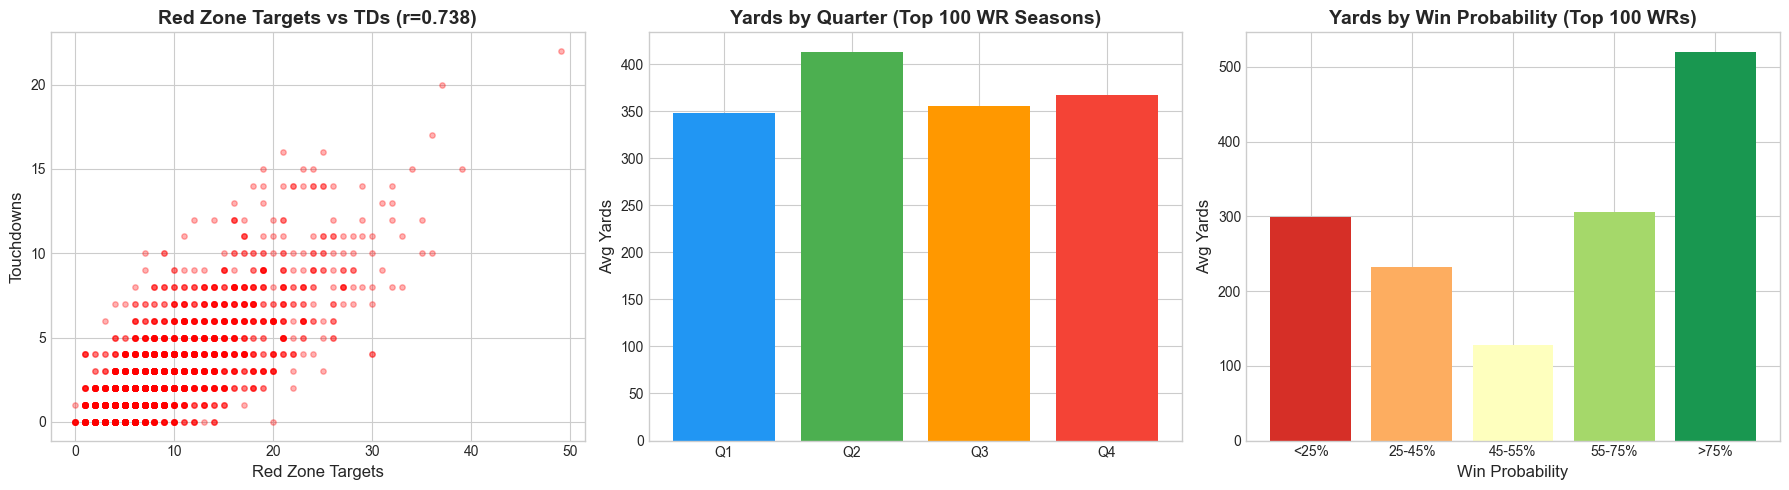

Conclusion: Top WRs produce heavily in Q2 and when the game is close (45-55% WP).


In [28]:
# 5.3 — WR Situational Analysis: Red Zone & Quarter Splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Red zone targets vs TDs
ax = axes[0]
valid_rz = wr_starters.dropna(subset=['red_zone_targets', 'tds'])
ax.scatter(valid_rz['red_zone_targets'], valid_rz['tds'], alpha=0.3, s=15, color='red')
r, _ = stats.pearsonr(valid_rz['red_zone_targets'], valid_rz['tds'])
ax.set_xlabel('Red Zone Targets')
ax.set_ylabel('Touchdowns')
ax.set_title(f'Red Zone Targets vs TDs (r={r:.3f})', fontweight='bold')

# Yards by quarter (top 100 WRs)
ax = axes[1]
q_cols = ['yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4']
q_cols_valid = [c for c in q_cols if c in wr_starters.columns]
if q_cols_valid:
    top100 = wr_starters.nlargest(100, 'receiving_yards')
    quarter_means = top100[q_cols_valid].mean()
    ax.bar(['Q1', 'Q2', 'Q3', 'Q4'][:len(q_cols_valid)], quarter_means,
           color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
    ax.set_ylabel('Avg Yards')
    ax.set_title('Yards by Quarter (Top 100 WR Seasons)', fontweight='bold')

# Win probability splits
ax = axes[2]
wp_cols = ['yards_wp_<25', 'yards_wp_25_45', 'yards_wp_45_55', 'yards_wp_55_75', 'yards_wp_>75']
wp_cols_valid = [c for c in wp_cols if c in wr_starters.columns]
if wp_cols_valid:
    top100 = wr_starters.nlargest(100, 'receiving_yards')
    wp_means = top100[wp_cols_valid].mean()
    labels = ['<25%', '25-45%', '45-55%', '55-75%', '>75%'][:len(wp_cols_valid)]
    ax.bar(labels, wp_means, color=plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(wp_cols_valid))))
    ax.set_xlabel('Win Probability')
    ax.set_ylabel('Avg Yards')
    ax.set_title('Yards by Win Probability (Top 100 WRs)', fontweight='bold')

plt.tight_layout()
plt.show()
print("Conclusion: Top WRs produce heavily in Q2 and when the game is close (45-55% WP).")

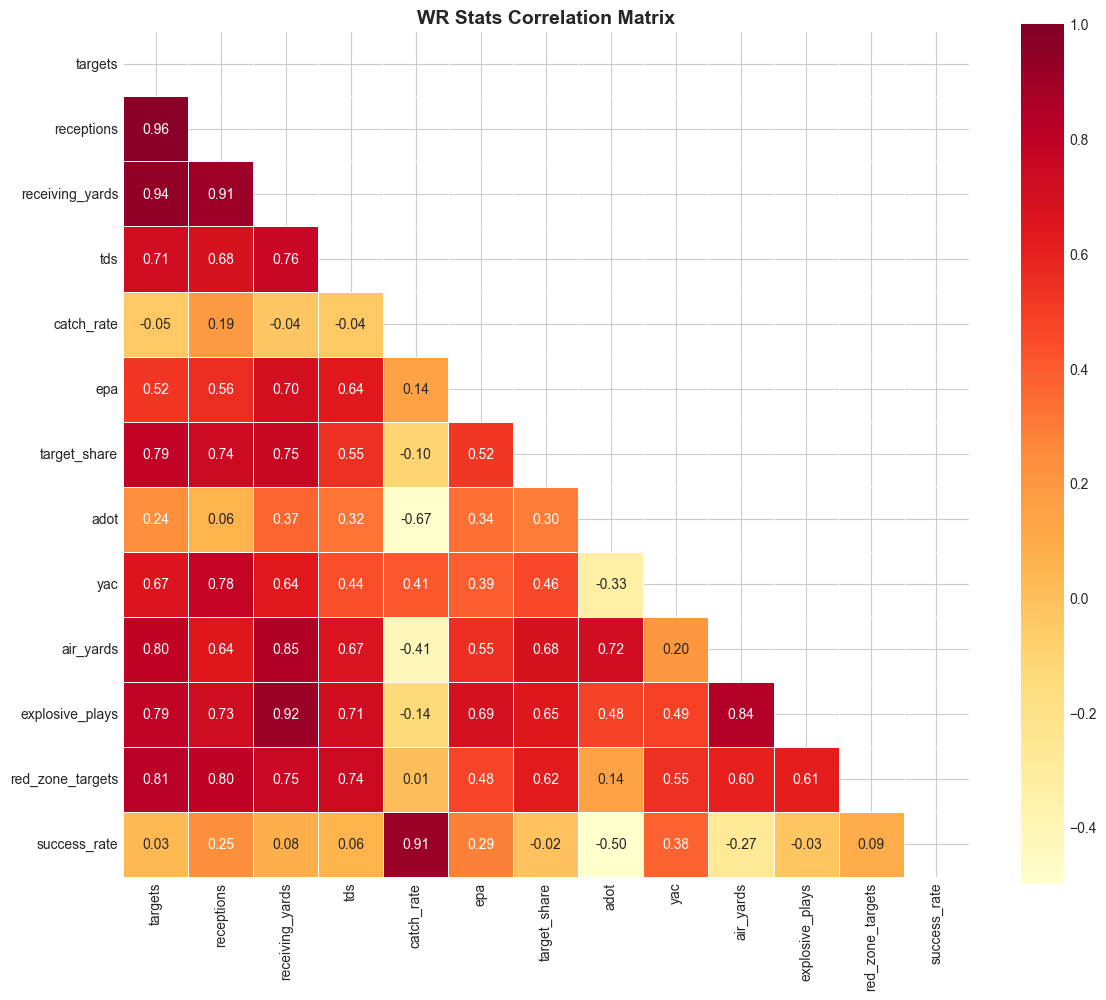

In [29]:
# 5.4 — WR Correlation Heatmap
wr_corr_cols = ['targets', 'receptions', 'receiving_yards', 'tds', 'catch_rate',
                'epa', 'target_share', 'adot', 'yac', 'air_yards', 'explosive_plays',
                'red_zone_targets', 'success_rate']
wr_corr_cols = [c for c in wr_corr_cols if c in wr_starters.columns]
corr = wr_starters[wr_corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='YlOrRd', vmin=-0.5, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('WR Stats Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

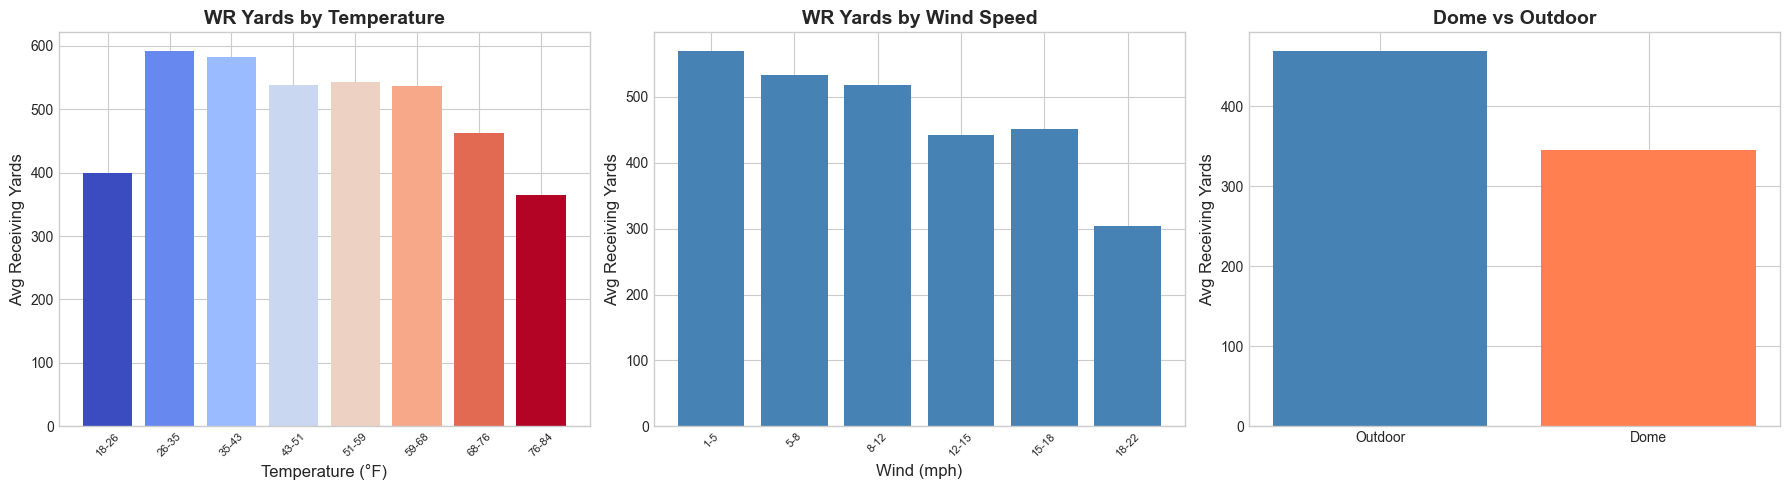

Weather impacts receiving production — moderate temperature and low wind are optimal.


In [30]:
# 5.5 — WR Weather Impact
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Temperature vs yards
ax = axes[0]
valid_temp = wr_starters.dropna(subset=['temp_f', 'receiving_yards'])
if len(valid_temp) > 50:
    bins_t = pd.cut(valid_temp['temp_f'], bins=8)
    binned = valid_temp.groupby(bins_t, observed=True)['receiving_yards'].mean()
    ax.bar(range(len(binned)), binned.values, color=plt.cm.coolwarm(np.linspace(0,1,len(binned))))
    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels([f"{b.left:.0f}-{b.right:.0f}" for b in binned.index], rotation=45, fontsize=8)
    ax.set_xlabel('Temperature (°F)')
    ax.set_ylabel('Avg Receiving Yards')
    ax.set_title('WR Yards by Temperature', fontweight='bold')

# Wind vs yards
ax = axes[1]
valid_wind = wr_starters.dropna(subset=['wind_mph', 'receiving_yards'])
if len(valid_wind) > 50:
    bins_w = pd.cut(valid_wind['wind_mph'], bins=6)
    binned_w = valid_wind.groupby(bins_w, observed=True)['receiving_yards'].mean()
    ax.bar(range(len(binned_w)), binned_w.values, color='steelblue')
    ax.set_xticks(range(len(binned_w)))
    ax.set_xticklabels([f"{b.left:.0f}-{b.right:.0f}" for b in binned_w.index], rotation=45, fontsize=8)
    ax.set_xlabel('Wind (mph)')
    ax.set_ylabel('Avg Receiving Yards')
    ax.set_title('WR Yards by Wind Speed', fontweight='bold')

# Dome vs outdoor
ax = axes[2]
valid_dome = wr_starters.dropna(subset=['is_dome', 'receiving_yards'])
if len(valid_dome) > 50:
    dome_means = valid_dome.groupby('is_dome')['receiving_yards'].mean()
    ax.bar(['Outdoor', 'Dome'], [dome_means.get(0, dome_means.iloc[0]) if 0 in dome_means.index else dome_means.iloc[0],
                                   dome_means.get(1, dome_means.iloc[-1]) if 1 in dome_means.index else dome_means.iloc[-1]],
           color=['steelblue', 'coral'])
    ax.set_ylabel('Avg Receiving Yards')
    ax.set_title('Dome vs Outdoor', fontweight='bold')

plt.tight_layout()
plt.show()
print("Weather impacts receiving production — moderate temperature and low wind are optimal.")

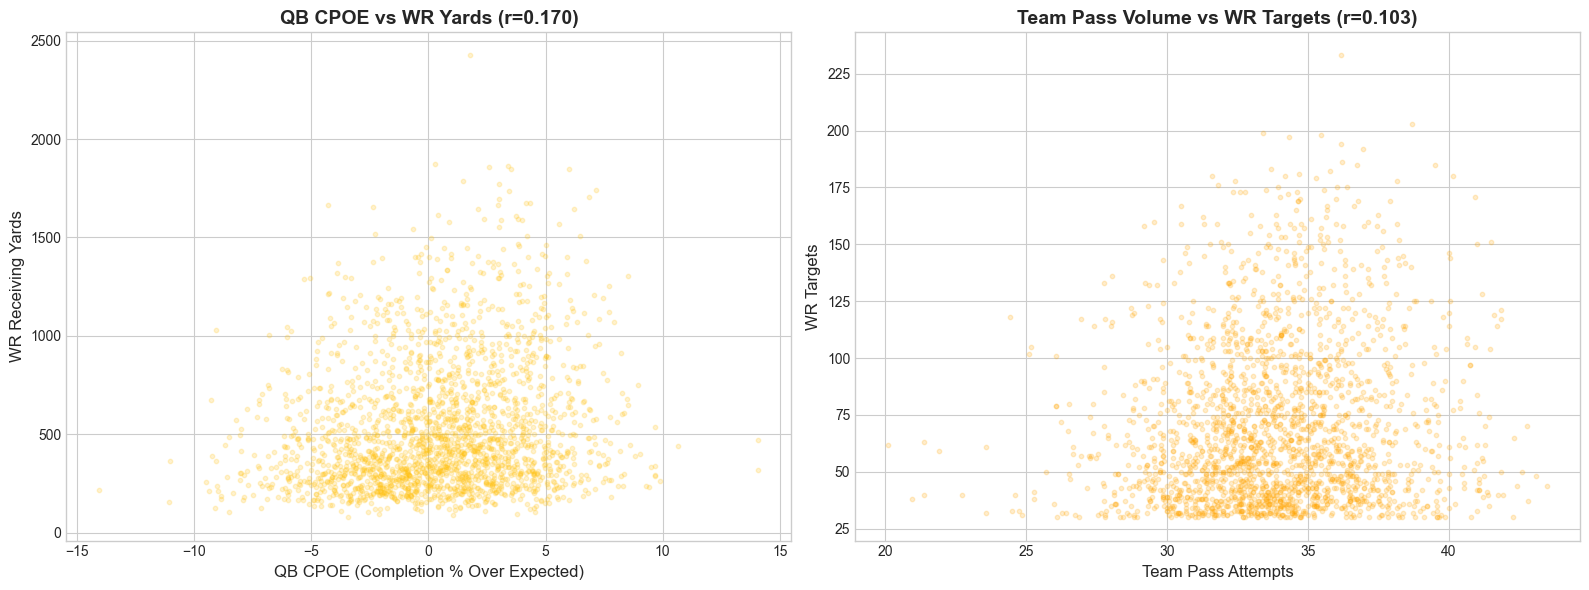

WR production is partly dependent on QB quality and team passing volume.


In [31]:
# 5.6 — QB Context: How QB quality affects WR production
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
valid_qb_ctx = wr_starters.dropna(subset=['qb_cpoe', 'receiving_yards'])
if len(valid_qb_ctx) > 30:
    ax.scatter(valid_qb_ctx['qb_cpoe'], valid_qb_ctx['receiving_yards'], alpha=0.2, s=10, color=COLORS['WR'])
    r, _ = stats.pearsonr(valid_qb_ctx['qb_cpoe'], valid_qb_ctx['receiving_yards'])
    ax.set_xlabel('QB CPOE (Completion % Over Expected)')
    ax.set_ylabel('WR Receiving Yards')
    ax.set_title(f'QB CPOE vs WR Yards (r={r:.3f})', fontweight='bold')

ax = axes[1]
valid_qb_att = wr_starters.dropna(subset=['team_pass_attempts', 'targets'])
if len(valid_qb_att) > 30:
    ax.scatter(valid_qb_att['team_pass_attempts'], valid_qb_att['targets'], alpha=0.2, s=10, color='orange')
    r, _ = stats.pearsonr(valid_qb_att['team_pass_attempts'], valid_qb_att['targets'])
    ax.set_xlabel('Team Pass Attempts')
    ax.set_ylabel('WR Targets')
    ax.set_title(f'Team Pass Volume vs WR Targets (r={r:.3f})', fontweight='bold')

plt.tight_layout()
plt.show()
print("WR production is partly dependent on QB quality and team passing volume.")

---
# 6. Tight End (TE) Analysis

Tight ends occupy a unique hybrid role — part receiver, part blocker. Elite pass-catching TEs like Travis Kelce have transformed the position. Our dataset (27 TEs, 2013–2025) captures this modern era.

---

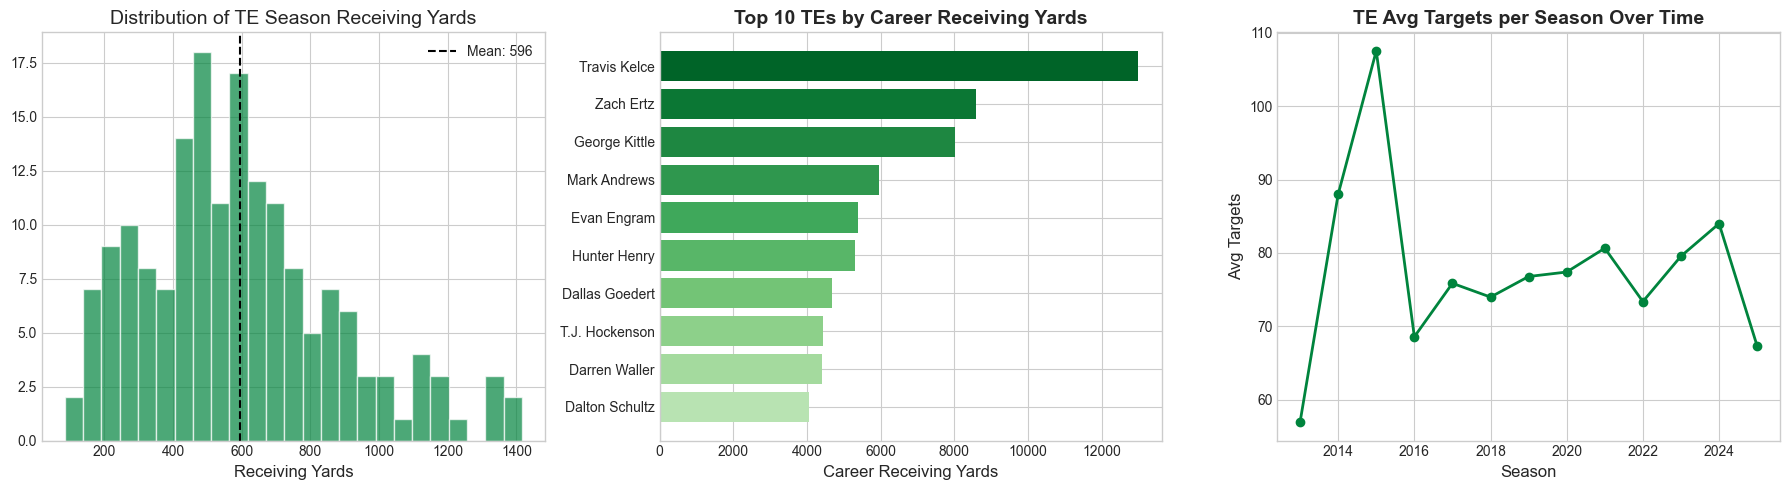

In [32]:
# 6.1 — TE Receiving Yards Distribution & Top Players
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution
ax = axes[0]
ax.hist(te_starters['Rec_Yds'].dropna(), bins=25, color=COLORS['TE'], alpha=0.7, edgecolor='white')
ax.axvline(te_starters['Rec_Yds'].mean(), color='black', ls='--',
           label=f"Mean: {te_starters['Rec_Yds'].mean():.0f}")
ax.set_title('Distribution of TE Season Receiving Yards')
ax.set_xlabel('Receiving Yards')
ax.legend()

# Top career TEs
te_career = te.groupby('Player').agg({'Rec_Yds': 'sum', 'Rec_TD': 'sum', 'Rec': 'sum'}).reset_index()
top10_te = te_career.nlargest(10, 'Rec_Yds')
ax = axes[1]
bars = ax.barh(top10_te['Player'][::-1], top10_te['Rec_Yds'][::-1],
               color=plt.cm.Greens(np.linspace(0.3, 0.9, 10)))
ax.set_xlabel('Career Receiving Yards')
ax.set_title('Top 10 TEs by Career Receiving Yards', fontweight='bold')

# Targets over time
ax = axes[2]
yearly_te = te_starters.groupby('Season')['Tgt'].mean()
ax.plot(yearly_te.index, yearly_te.values, 'o-', color=COLORS['TE'], lw=2)
ax.set_xlabel('Season')
ax.set_ylabel('Avg Targets')
ax.set_title('TE Avg Targets per Season Over Time', fontweight='bold')

plt.tight_layout()
plt.show()

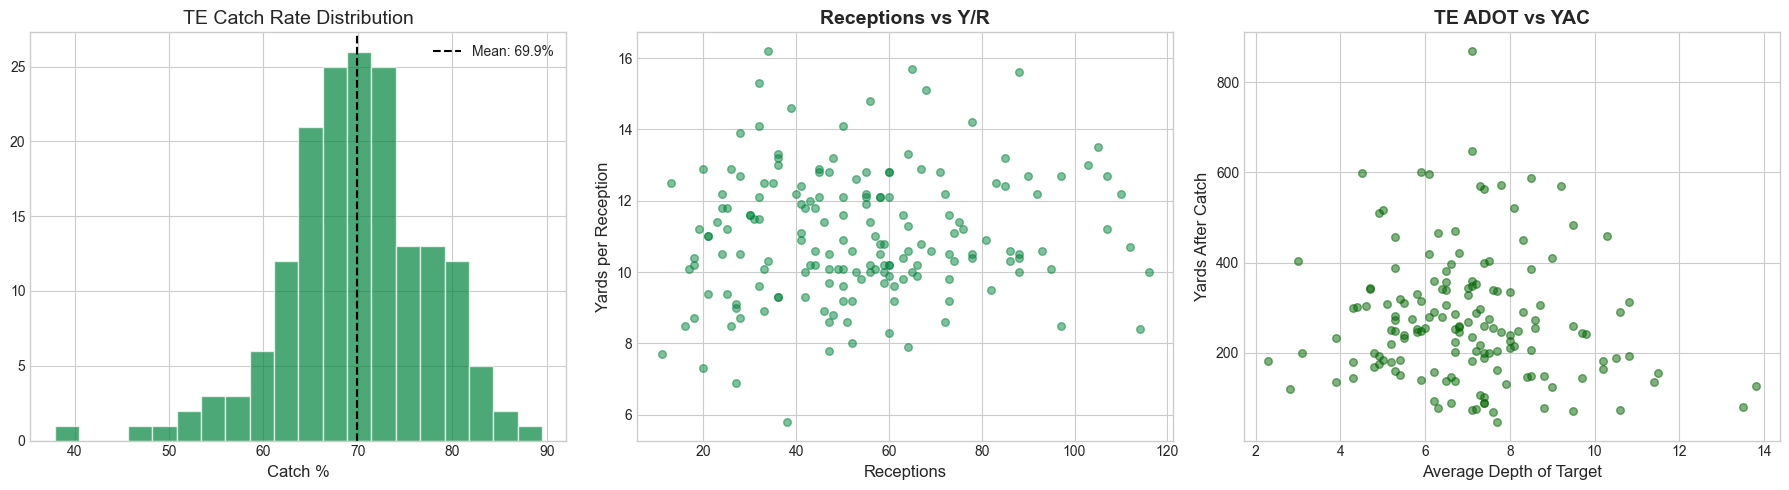

Elite TEs combine high catch rates with solid ADOT — reliable targets across the middle of the field.


In [33]:
# 6.2 — TE Efficiency: Catch Rate, Y/R, ADOT
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Catch rate distribution
ax = axes[0]
te_cp = te_starters['catch_pct'].dropna()
if len(te_cp) > 5:
    ax.hist(te_cp, bins=20, color=COLORS['TE'], alpha=0.7, edgecolor='white')
    ax.axvline(te_cp.mean(), color='black', ls='--', label=f'Mean: {te_cp.mean():.1f}%')
    ax.set_title('TE Catch Rate Distribution')
    ax.set_xlabel('Catch %')
    ax.legend()

# Y/R vs Rec
ax = axes[1]
valid_yr = te_starters.dropna(subset=['Rec_Y/R', 'Rec'])
ax.scatter(valid_yr['Rec'], valid_yr['Rec_Y/R'], alpha=0.5, s=30, color=COLORS['TE'])
ax.set_xlabel('Receptions')
ax.set_ylabel('Yards per Reception')
ax.set_title('Receptions vs Y/R', fontweight='bold')

# ADOT vs YAC
ax = axes[2]
valid_te_adv = te_starters.dropna(subset=['adv_ADOT', 'adv_Rec_YAC'])
if len(valid_te_adv) > 5:
    ax.scatter(valid_te_adv['adv_ADOT'], valid_te_adv['adv_Rec_YAC'], alpha=0.5, s=30, color='darkgreen')
    ax.set_xlabel('Average Depth of Target')
    ax.set_ylabel('Yards After Catch')
    ax.set_title('TE ADOT vs YAC', fontweight='bold')

plt.tight_layout()
plt.show()
print("Elite TEs combine high catch rates with solid ADOT — reliable targets across the middle of the field.")

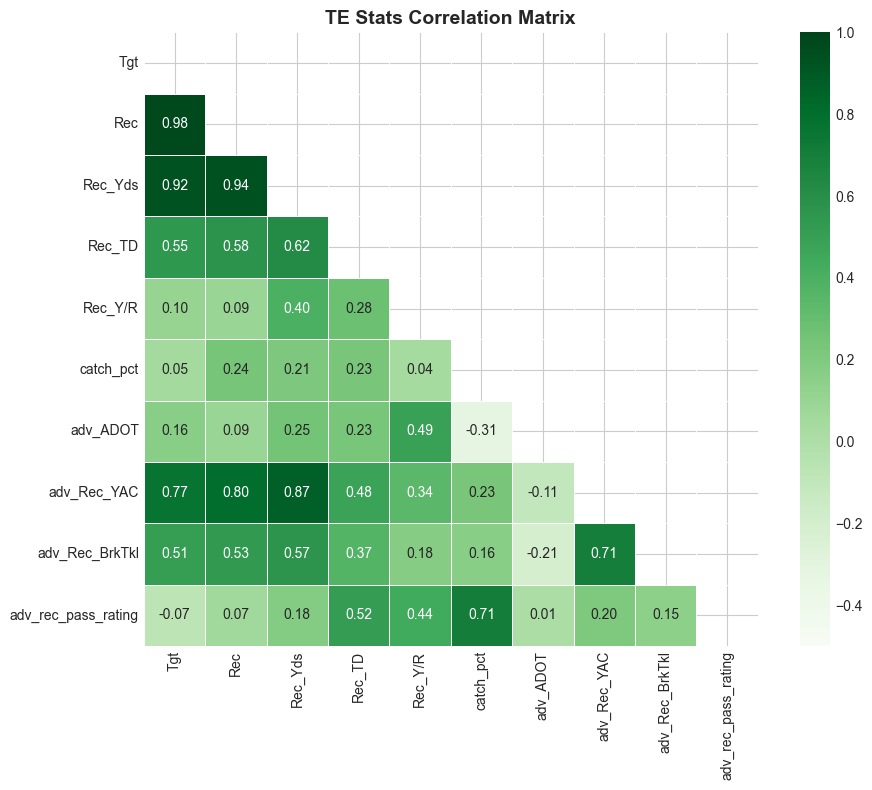

In [34]:
# 6.3 — TE Correlation Heatmap
te_corr_cols = ['Tgt', 'Rec', 'Rec_Yds', 'Rec_TD', 'Rec_Y/R', 'catch_pct',
                'adv_ADOT', 'adv_Rec_YAC', 'adv_Rec_BrkTkl', 'adv_rec_pass_rating']
te_corr_cols = [c for c in te_corr_cols if c in te_starters.columns]
corr = te_starters[te_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Greens', vmin=-0.5, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('TE Stats Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

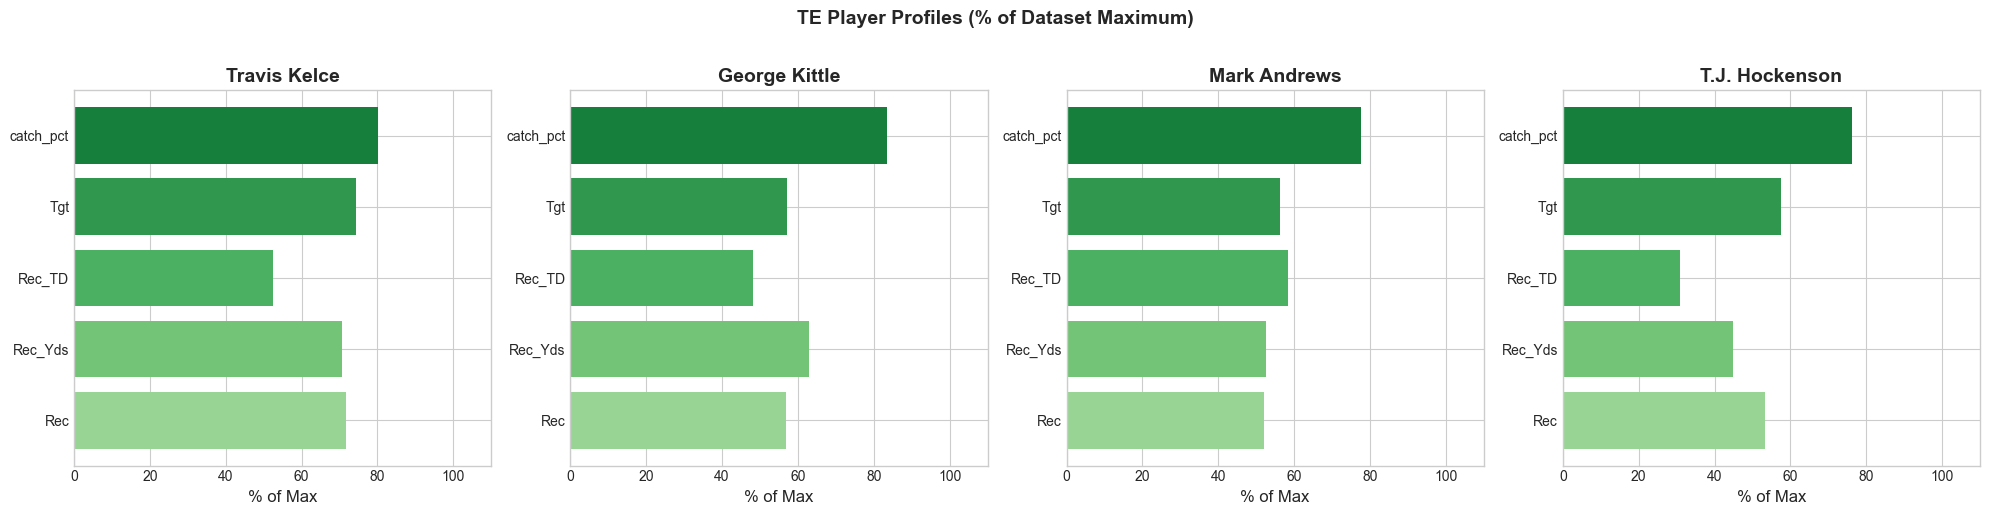

In [35]:
# 6.4 — TE Player Profiles: Radar Chart
from matplotlib.patches import FancyBboxPatch

# Compare top TEs across key metrics
top_tes = ['Travis Kelce', 'George Kittle', 'Mark Andrews', 'T.J. Hockenson']
metrics = ['Rec', 'Rec_Yds', 'Rec_TD', 'Tgt', 'catch_pct']
metrics = [m for m in metrics if m in te.columns]

fig, axes = plt.subplots(1, len(top_tes), figsize=(5*len(top_tes), 5))
if len(top_tes) == 1:
    axes = [axes]

for ax, te_name in zip(axes, top_tes):
    player_data = te[te['Player'] == te_name]
    if len(player_data) > 0:
        means = player_data[metrics].mean()
        # Normalize to 0-1 for comparison
        maxes = te_starters[metrics].max()
        normalized = (means / maxes * 100).fillna(0)
        
        colors_list = plt.cm.Greens(np.linspace(0.4, 0.8, len(metrics)))
        ax.barh(metrics, normalized, color=colors_list)
        ax.set_xlim(0, 110)
        ax.set_title(te_name, fontweight='bold')
        ax.set_xlabel('% of Max')
    else:
        ax.text(0.5, 0.5, f'{te_name}\nNot Found', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('TE Player Profiles (% of Dataset Maximum)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 7. Cross-Position Comparisons

How do the positions compare across common metrics? Let's look at scoring output, age curves, and the evolution of each position.

---

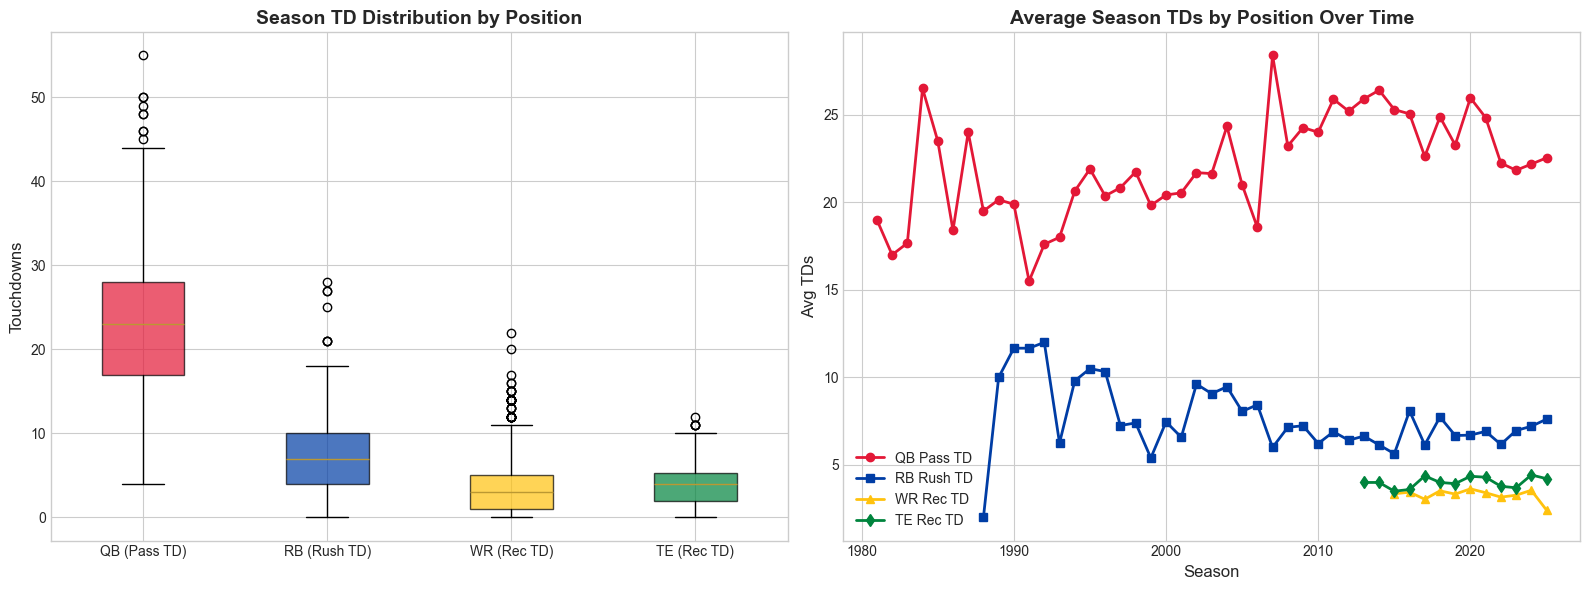

In [36]:
# 7.1 — Touchdowns by Position
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TD distributions
ax = axes[0]
td_data = [
    qb_starters['TD'].dropna(),
    rb_starters['Rush_TD'].dropna(),
    wr_starters['tds'].dropna(),
    te_starters['Rec_TD'].dropna()
]
td_labels = ['QB (Pass TD)', 'RB (Rush TD)', 'WR (Rec TD)', 'TE (Rec TD)']
bp = ax.boxplot(td_data, labels=td_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], [COLORS['QB'], COLORS['RB'], COLORS['WR'], COLORS['TE']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Touchdowns')
ax.set_title('Season TD Distribution by Position', fontweight='bold')

# Average TDs over time
ax = axes[1]
qb_yr = qb_starters.groupby('Season')['TD'].mean()
rb_yr = rb_starters.groupby('Season')['Rush_TD'].mean()
wr_yr = wr_starters.groupby('season')['tds'].mean()
te_yr = te_starters.groupby('Season')['Rec_TD'].mean()

ax.plot(qb_yr.index, qb_yr.values, 'o-', color=COLORS['QB'], label='QB Pass TD', lw=2)
ax.plot(rb_yr.index, rb_yr.values, 's-', color=COLORS['RB'], label='RB Rush TD', lw=2)
ax.plot(wr_yr.index, wr_yr.values, '^-', color=COLORS['WR'], label='WR Rec TD', lw=2)
ax.plot(te_yr.index, te_yr.values, 'd-', color=COLORS['TE'], label='TE Rec TD', lw=2)
ax.set_xlabel('Season')
ax.set_ylabel('Avg TDs')
ax.set_title('Average Season TDs by Position Over Time', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

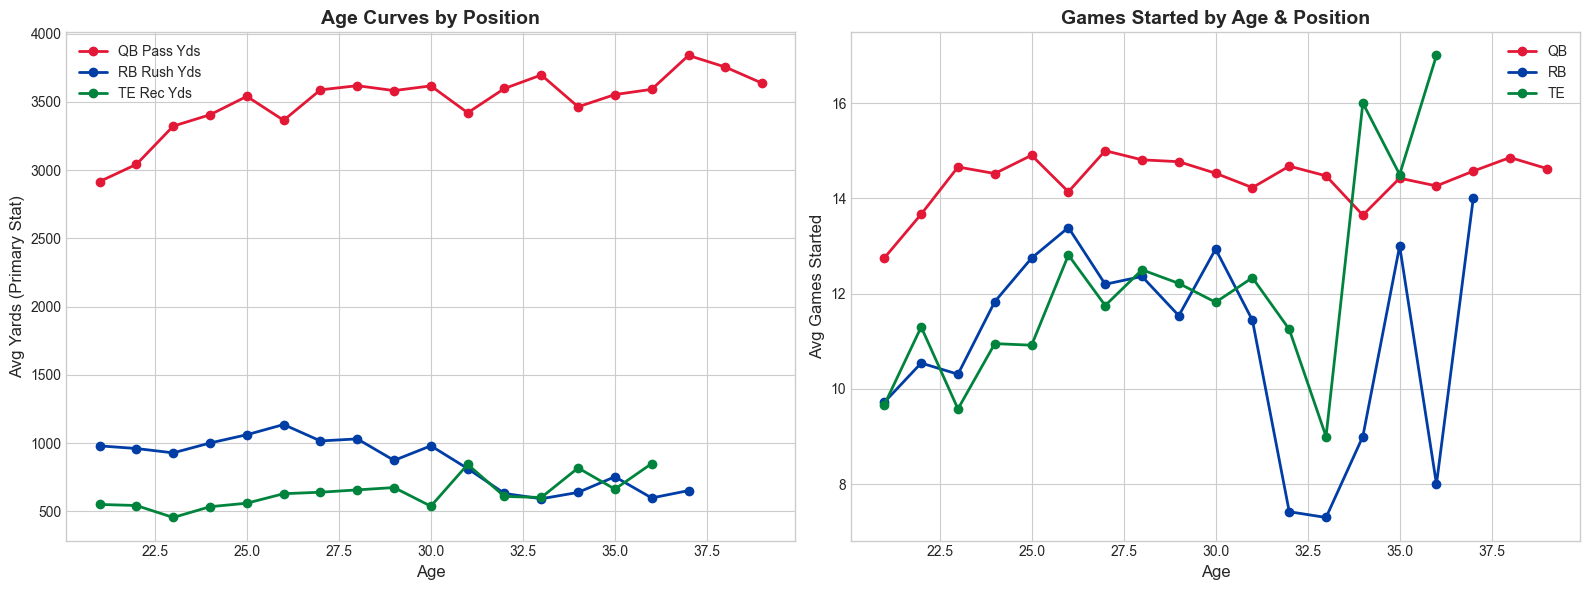

QBs peak later and last longer. RBs peak early (25-27) and decline fast. TEs fall in between.


In [37]:
# 7.2 — Age Curves Across Positions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Primary production by age
ax = axes[0]
qb_age = qb_starters.groupby('Age')['Yds'].mean()
rb_age = rb_starters.groupby('Age')['Rush_Yds'].mean()
te_age = te_starters.groupby('Age')['Rec_Yds'].mean()

valid_ages = range(21, 40)
for data, label, color, ylabel in [
    (qb_age, 'QB Pass Yds', COLORS['QB'], 'Yards'),
    (rb_age, 'RB Rush Yds', COLORS['RB'], 'Yards'),
    (te_age, 'TE Rec Yds', COLORS['TE'], 'Yards'),
]:
    ages = [a for a in valid_ages if a in data.index]
    vals = [data[a] for a in ages]
    ax.plot(ages, vals, 'o-', label=label, color=color, lw=2)

ax.set_xlabel('Age')
ax.set_ylabel('Avg Yards (Primary Stat)')
ax.set_title('Age Curves by Position', fontweight='bold')
ax.legend()

# Games started by age
ax = axes[1]
for df, label, color, age_col in [
    (qb_starters, 'QB', COLORS['QB'], 'Age'),
    (rb_starters, 'RB', COLORS['RB'], 'Age'),
    (te_starters, 'TE', COLORS['TE'], 'Age'),
]:
    age_gs = df.groupby(age_col)['GS'].mean()
    ages = [a for a in valid_ages if a in age_gs.index]
    vals = [age_gs[a] for a in ages]
    ax.plot(ages, vals, 'o-', label=label, color=color, lw=2)

ax.set_xlabel('Age')
ax.set_ylabel('Avg Games Started')
ax.set_title('Games Started by Age & Position', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()
print("QBs peak later and last longer. RBs peak early (25-27) and decline fast. TEs fall in between.")

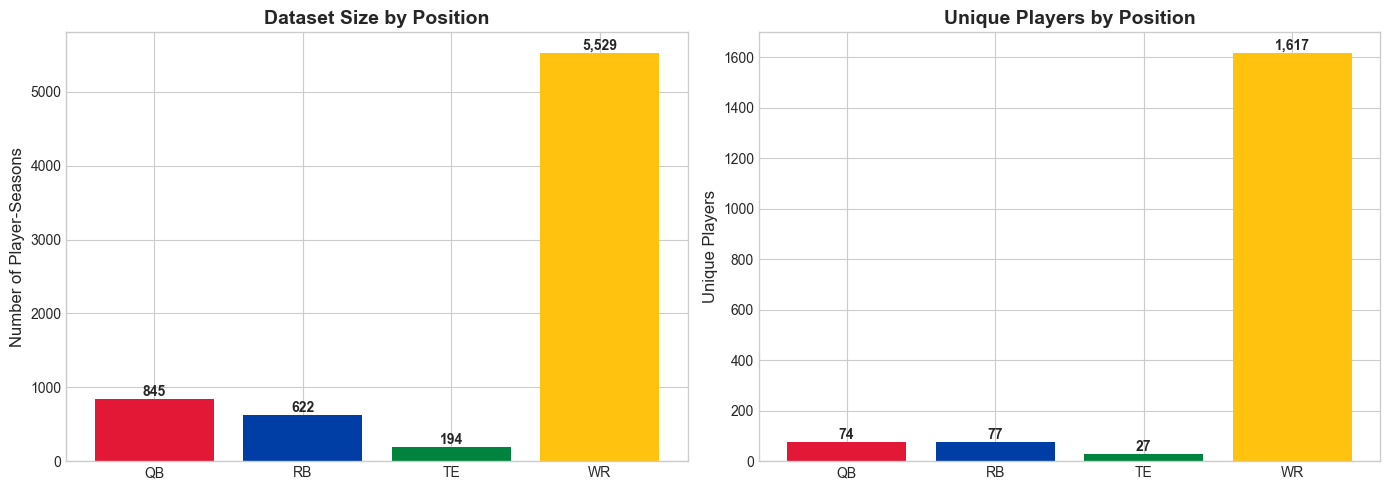

In [38]:
# 7.3 — Dataset Size Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rows per position
sizes = {'QB': len(qb), 'RB': len(rb), 'TE': len(te), 'WR': len(wr)}
ax = axes[0]
bars = ax.bar(sizes.keys(), sizes.values(), color=[COLORS[p] for p in sizes.keys()])
for bar, val in zip(bars, sizes.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:,}',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Number of Player-Seasons')
ax.set_title('Dataset Size by Position', fontweight='bold')

# Unique players
players = {
    'QB': qb['Player'].nunique(),
    'RB': rb['Player'].nunique(),
    'TE': te['Player'].nunique(),
    'WR': wr['receiver_player_name'].nunique()
}
ax = axes[1]
bars = ax.bar(players.keys(), players.values(), color=[COLORS[p] for p in players.keys()])
for bar, val in zip(bars, players.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:,}',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Unique Players')
ax.set_title('Unique Players by Position', fontweight='bold')

plt.tight_layout()
plt.show()

---
# 8. Feature Importance Preview

Before building models in Notebook 3, let's identify which features are most correlated with our target variables. This helps us understand what stats best predict performance.

---

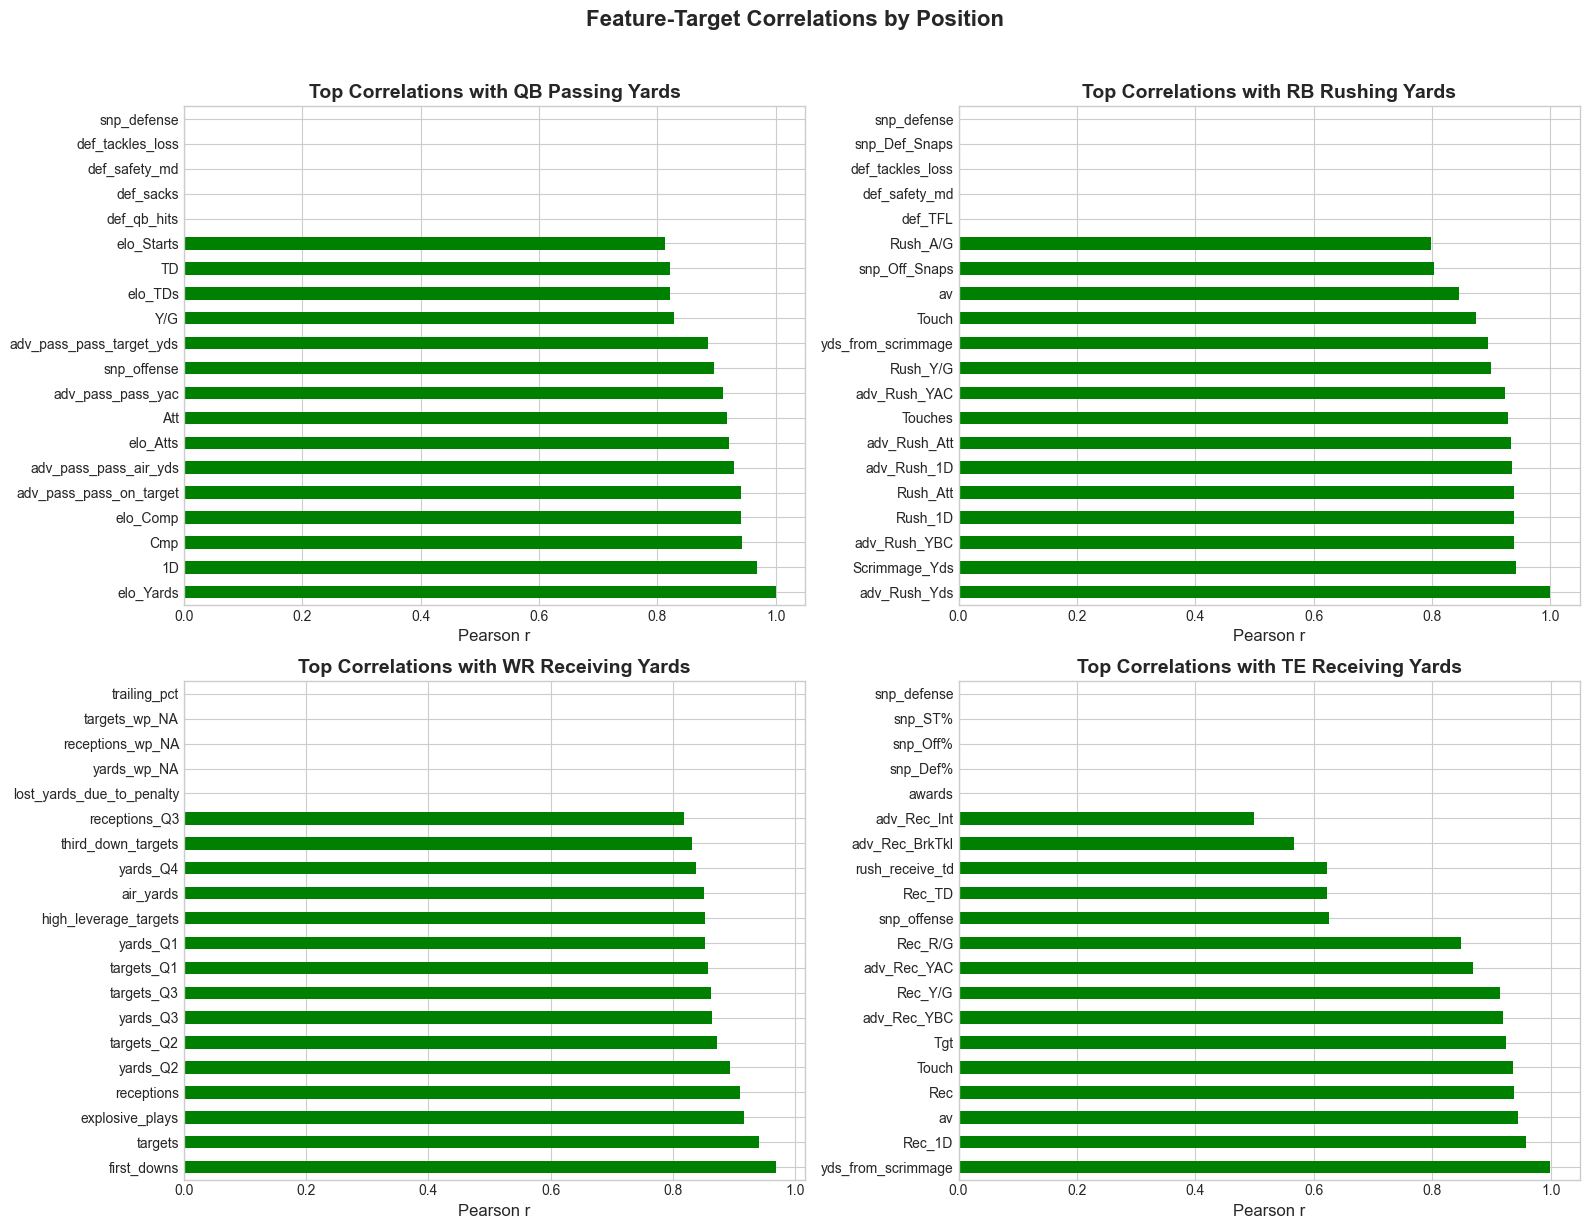

These correlations guide feature selection for our ML models in Notebook 3.


In [39]:
# 8.1 — Top Correlations with QB Passing Yards
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# QB: correlations with Yds
ax = axes[0, 0]
qb_num = qb_starters.select_dtypes(include=[np.number])
corr_yds = qb_num.corr()['Yds'].drop('Yds').sort_values(ascending=False)
top_pos = corr_yds.head(15)
top_neg = corr_yds.tail(5)
combined = pd.concat([top_pos, top_neg])
colors_c = ['green' if v > 0 else 'red' for v in combined]
combined.plot.barh(ax=ax, color=colors_c)
ax.set_title('Top Correlations with QB Passing Yards', fontweight='bold')
ax.set_xlabel('Pearson r')

# RB: correlations with Rush_Yds
ax = axes[0, 1]
rb_num = rb_starters.select_dtypes(include=[np.number])
if 'Rush_Yds' in rb_num.columns:
    corr_rush = rb_num.corr()['Rush_Yds'].drop('Rush_Yds').sort_values(ascending=False)
    top_r = pd.concat([corr_rush.head(15), corr_rush.tail(5)])
    colors_r = ['green' if v > 0 else 'red' for v in top_r]
    top_r.plot.barh(ax=ax, color=colors_r)
    ax.set_title('Top Correlations with RB Rushing Yards', fontweight='bold')
    ax.set_xlabel('Pearson r')

# WR: correlations with receiving_yards
ax = axes[1, 0]
wr_num = wr_starters.select_dtypes(include=[np.number])
if 'receiving_yards' in wr_num.columns:
    corr_rec = wr_num.corr()['receiving_yards'].drop('receiving_yards').sort_values(ascending=False)
    top_w = pd.concat([corr_rec.head(15), corr_rec.tail(5)])
    colors_w = ['green' if v > 0 else 'red' for v in top_w]
    top_w.plot.barh(ax=ax, color=colors_w)
    ax.set_title('Top Correlations with WR Receiving Yards', fontweight='bold')
    ax.set_xlabel('Pearson r')

# TE: correlations with Rec_Yds
ax = axes[1, 1]
te_num = te_starters.select_dtypes(include=[np.number])
if 'Rec_Yds' in te_num.columns:
    corr_te = te_num.corr()['Rec_Yds'].drop('Rec_Yds').sort_values(ascending=False)
    top_t = pd.concat([corr_te.head(15), corr_te.tail(5)])
    colors_t = ['green' if v > 0 else 'red' for v in top_t]
    top_t.plot.barh(ax=ax, color=colors_t)
    ax.set_title('Top Correlations with TE Receiving Yards', fontweight='bold')
    ax.set_xlabel('Pearson r')

plt.suptitle('Feature-Target Correlations by Position', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("These correlations guide feature selection for our ML models in Notebook 3.")

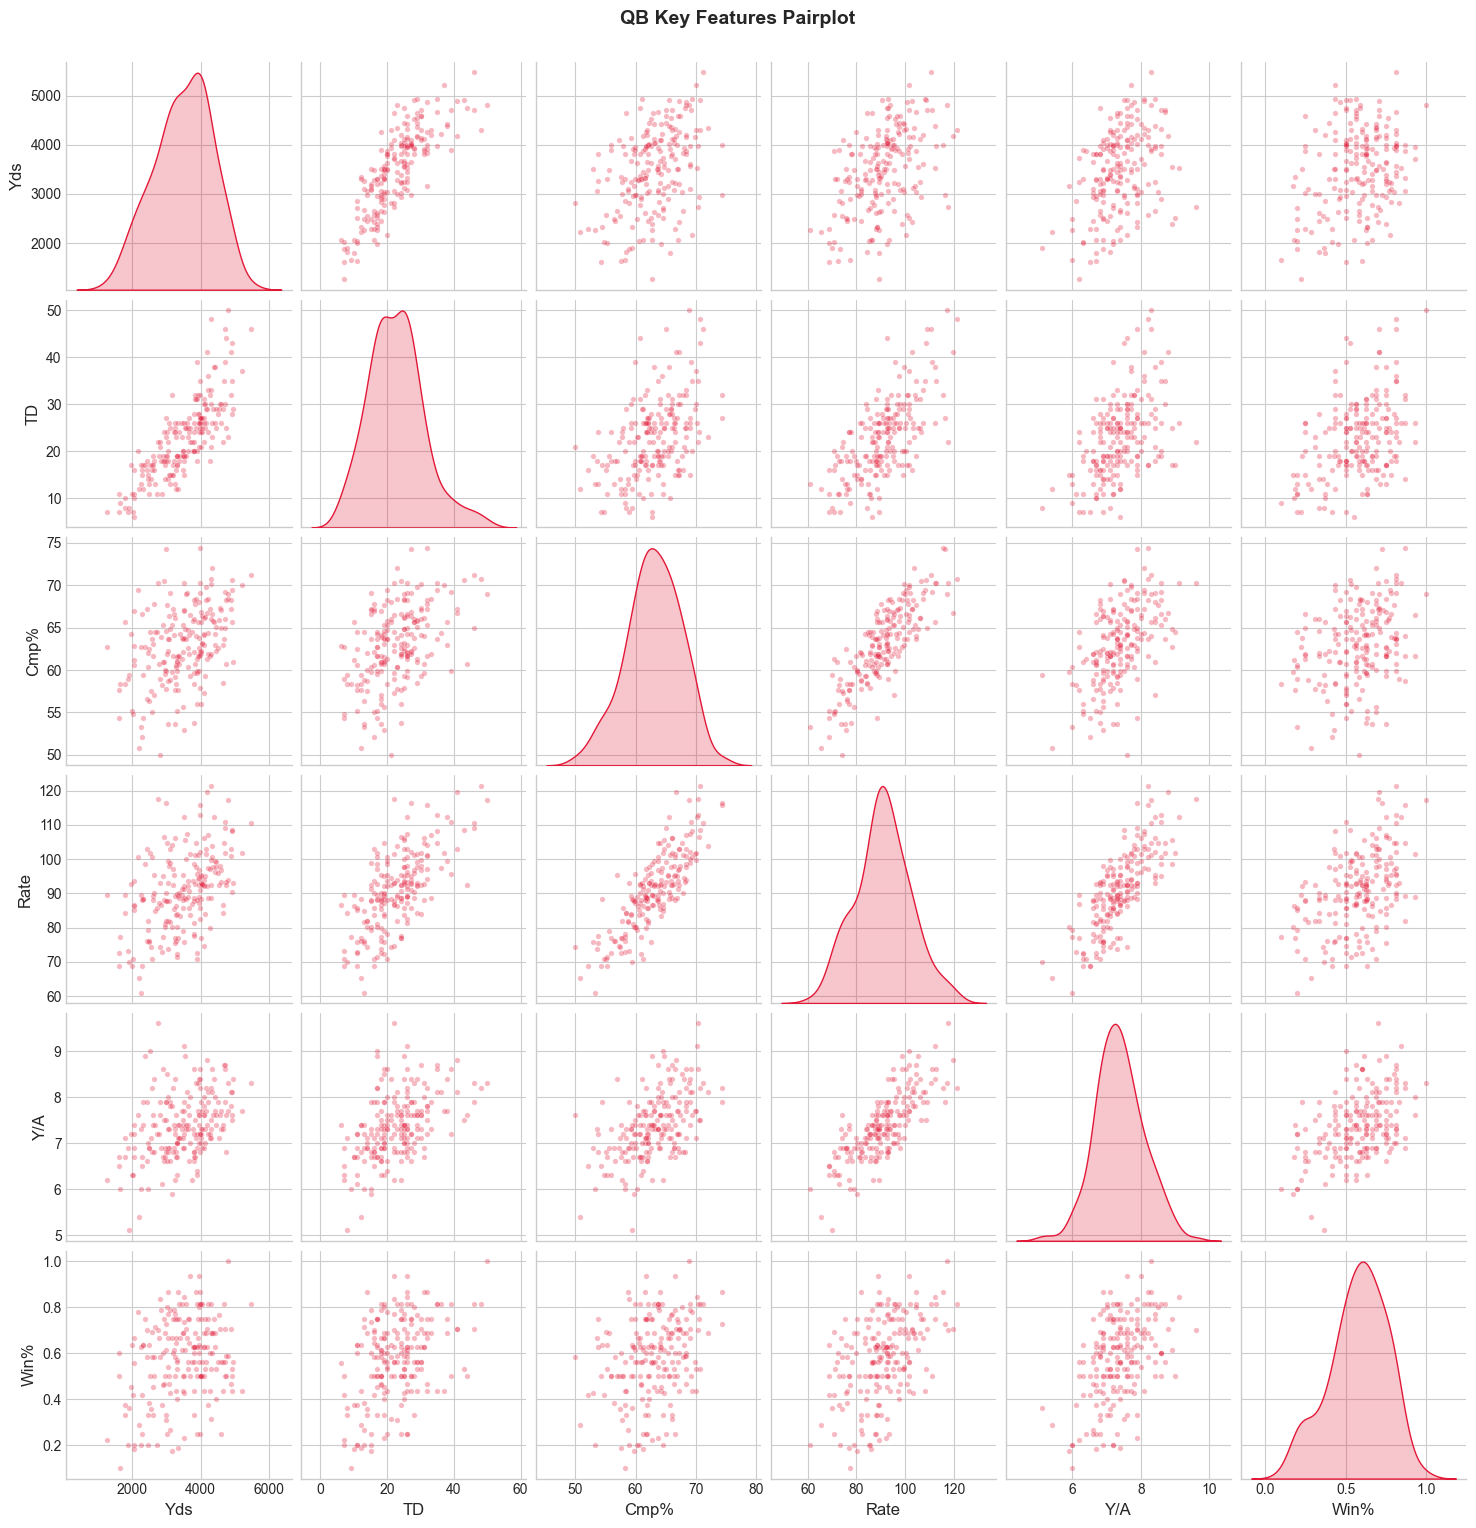

In [40]:
# 8.2 — Pairplot of top QB features
top_qb_features = ['Yds', 'TD', 'Cmp%', 'Rate', 'Y/A', 'Win%']
top_qb_features = [c for c in top_qb_features if c in qb_starters.columns]
sample = qb_starters[top_qb_features].dropna().sample(min(200, len(qb_starters)), random_state=42)

g = sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15, 'color': COLORS['QB']},
                 diag_kws={'color': COLORS['QB']})
g.figure.suptitle('QB Key Features Pairplot', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
# 9. The Winning Formula — What Stats ACTUALLY Win Games?

The most important question for any GM or coach: **what should I look for when building a roster?** Let's go beyond simple correlations and use feature importance (Random Forest) to find what truly predicts winning and player value.

---

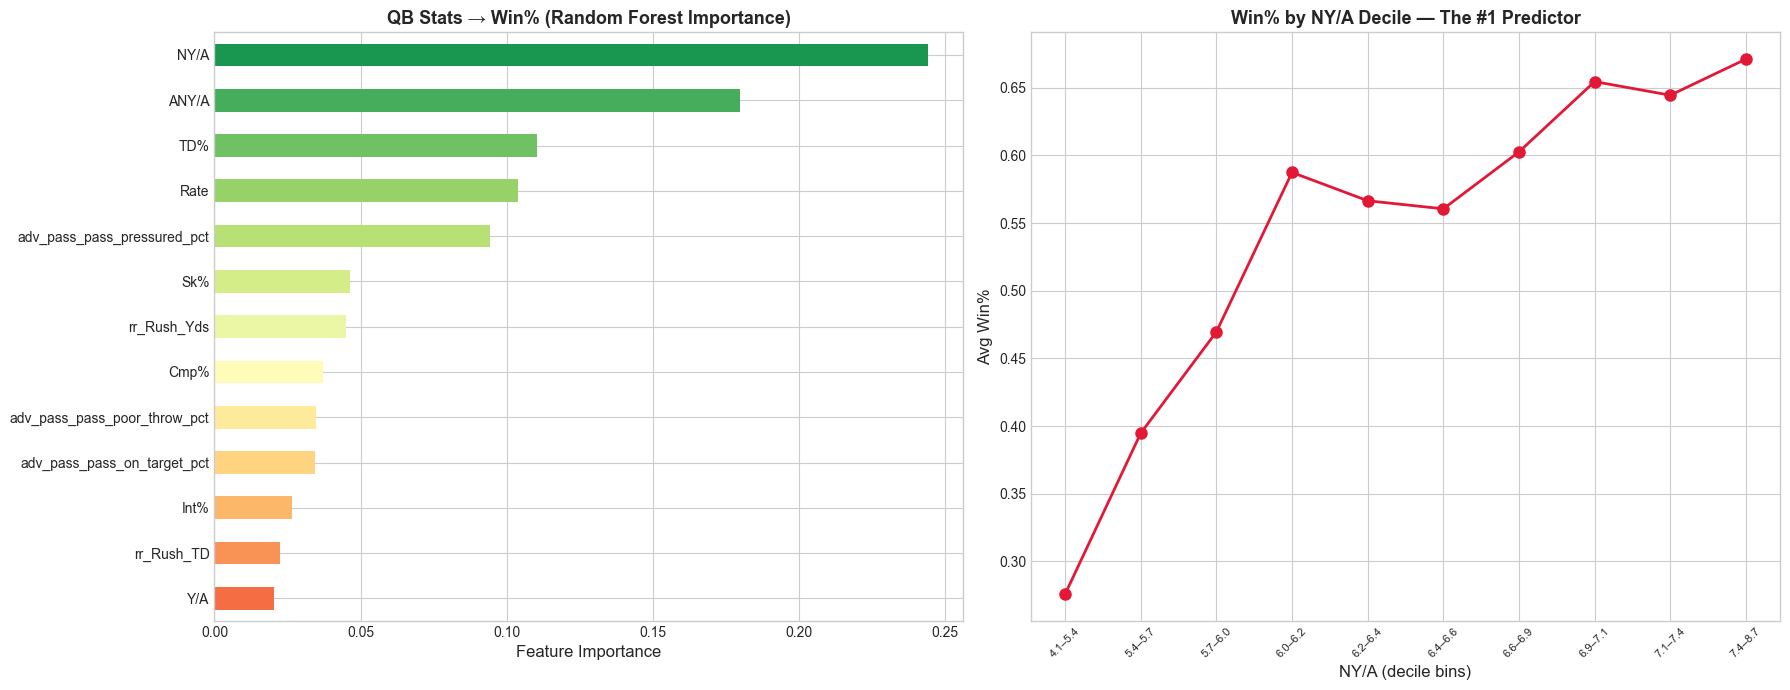


🏆 TOP 5 STATS THAT PREDICT QB WINNING:
                            NY/A: 0.2442
                           ANY/A: 0.1798
                             TD%: 0.1103
                            Rate: 0.1039
     adv_pass_pass_pressured_pct: 0.0945

  R² score: 0.900

💡 KEY INSIGHT: NY/A is the single most important stat for predicting QB wins.
   Forget about raw passing yards — efficiency metrics like NY/A matter way more.


In [41]:
# 9.1 — Feature Importance for QB Win% (Random Forest)
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Prepare QB data for feature importance
qb_win_features = ['Cmp%', 'Y/A', 'TD%', 'Int%', 'Rate', 'Sk%', 'NY/A', 'ANY/A',
                    'adv_pass_pass_on_target_pct', 'adv_pass_pass_pressured_pct',
                    'adv_pass_pass_poor_throw_pct', 'rr_Rush_Yds', 'rr_Rush_TD']
qb_win_features = [c for c in qb_win_features if c in qb_starters.columns]

qb_for_rf = qb_starters[qb_win_features + ['Win%']].dropna()
if len(qb_for_rf) > 50:
    X = qb_for_rf[qb_win_features]
    y = qb_for_rf['Win%']
    
    rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    
    importance = pd.Series(rf.feature_importances_, index=qb_win_features).sort_values(ascending=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Feature importance
    ax = axes[0]
    colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importance)))
    importance.plot.barh(ax=ax, color=colors_imp)
    ax.set_title('QB Stats → Win% (Random Forest Importance)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    
    # Partial dependence-style: bin the top feature and show avg Win%
    ax = axes[1]
    top_feat = importance.index[-1]
    bins = pd.qcut(qb_for_rf[top_feat], q=10, duplicates='drop')
    binned_win = qb_for_rf.groupby(bins, observed=True)['Win%'].mean()
    ax.plot(range(len(binned_win)), binned_win.values, 'o-', color=COLORS['QB'], lw=2, ms=8)
    ax.set_xticks(range(len(binned_win)))
    ax.set_xticklabels([f"{b.left:.1f}–{b.right:.1f}" for b in binned_win.index], rotation=45, fontsize=8)
    ax.set_xlabel(f'{top_feat} (decile bins)')
    ax.set_ylabel('Avg Win%')
    ax.set_title(f'Win% by {top_feat} Decile — The #1 Predictor', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n🏆 TOP 5 STATS THAT PREDICT QB WINNING:")
    for feat, imp in importance.tail(5).iloc[::-1].items():
        print(f"  {feat:>30s}: {imp:.4f}")
    print(f"\n  R² score: {rf.score(X, y):.3f}")
    print(f"\n💡 KEY INSIGHT: {importance.index[-1]} is the single most important stat for predicting QB wins.")
    print(f"   Forget about raw passing yards — efficiency metrics like {importance.index[-1]} matter way more.")

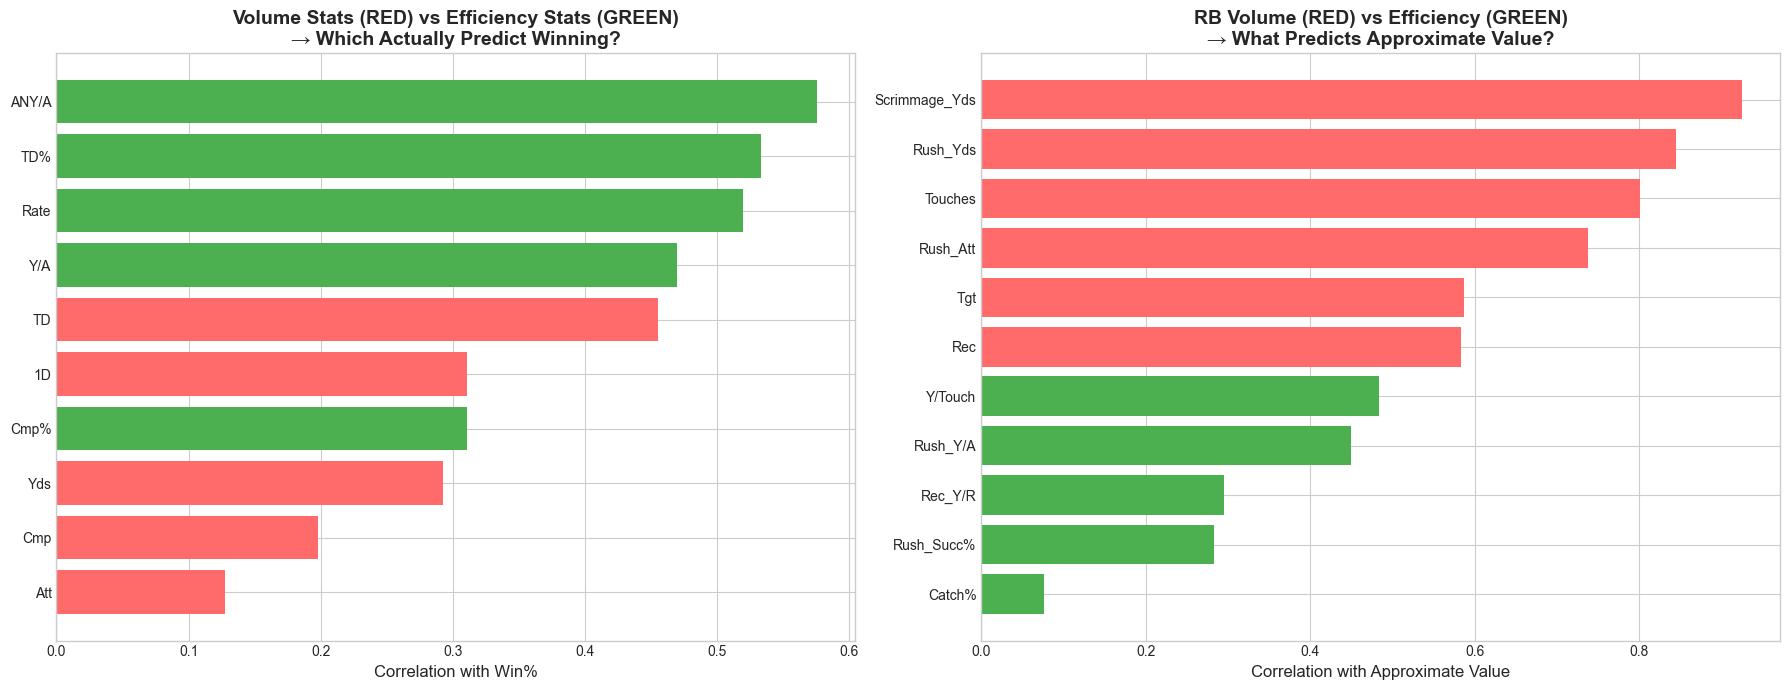

💡 INSIGHT: Efficiency stats (GREEN) consistently predict winning/value better than volume stats (RED).
   A GM should prioritize Y/A, ANY/A, and passer rating over raw yardage totals.
   For RBs, yards per touch and success rate matter more than total carries.


In [42]:
# 9.2 — Overrated vs Underrated Stats: Correlation with Winning vs Popularity
# Some stats look good on paper but don't actually predict winning

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# QB: volume vs efficiency — which predicts winning better?
ax = axes[0]
vol_stats = ['Yds', 'Att', 'Cmp', 'TD', '1D']
eff_stats = ['Y/A', 'ANY/A', 'Rate', 'Cmp%', 'TD%']
vol_stats = [c for c in vol_stats if c in qb_starters.columns]
eff_stats = [c for c in eff_stats if c in qb_starters.columns]

valid_win = qb_starters.dropna(subset=['Win%'])
vol_corrs = {s: valid_win[['Win%', s]].dropna().corr().iloc[0,1] for s in vol_stats}
eff_corrs = {s: valid_win[['Win%', s]].dropna().corr().iloc[0,1] for s in eff_stats}

combined_labels = list(vol_corrs.keys()) + list(eff_corrs.keys())
combined_vals = list(vol_corrs.values()) + list(eff_corrs.values())
combined_colors = ['#FF6B6B']*len(vol_corrs) + ['#4CAF50']*len(eff_corrs)

sorted_idx = np.argsort(combined_vals)
ax.barh([combined_labels[i] for i in sorted_idx], [combined_vals[i] for i in sorted_idx],
        color=[combined_colors[i] for i in sorted_idx])
ax.set_xlabel('Correlation with Win%')
ax.set_title('Volume Stats (RED) vs Efficiency Stats (GREEN)\n→ Which Actually Predict Winning?', fontweight='bold')
ax.axvline(0, color='black', lw=0.5)

# RB: same analysis
ax = axes[1]
rb_vol = ['Rush_Att', 'Rush_Yds', 'Tgt', 'Rec', 'Touches', 'Scrimmage_Yds']
rb_eff = ['Rush_Y/A', 'Rush_Succ%', 'Y/Touch', 'Catch%', 'Rec_Y/R']
rb_vol = [c for c in rb_vol if c in rb_starters.columns]
rb_eff = [c for c in rb_eff if c in rb_starters.columns]

if 'av' in rb_starters.columns:
    target = 'av'
    target_label = 'Approximate Value'
else:
    target = 'Rush_Yds'
    target_label = 'Rush Yds'

valid_rb = rb_starters.dropna(subset=[target])
rb_vol_c = {s: valid_rb[[target, s]].dropna().corr().iloc[0,1] for s in rb_vol if s != target}
rb_eff_c = {s: valid_rb[[target, s]].dropna().corr().iloc[0,1] for s in rb_eff}

rb_labels = list(rb_vol_c.keys()) + list(rb_eff_c.keys())
rb_vals = list(rb_vol_c.values()) + list(rb_eff_c.values())
rb_colors = ['#FF6B6B']*len(rb_vol_c) + ['#4CAF50']*len(rb_eff_c)

sorted_rb = np.argsort(rb_vals)
ax.barh([rb_labels[i] for i in sorted_rb], [rb_vals[i] for i in sorted_rb],
        color=[rb_colors[i] for i in sorted_rb])
ax.set_xlabel(f'Correlation with {target_label}')
ax.set_title(f'RB Volume (RED) vs Efficiency (GREEN)\n→ What Predicts {target_label}?', fontweight='bold')
ax.axvline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()
print("💡 INSIGHT: Efficiency stats (GREEN) consistently predict winning/value better than volume stats (RED).")
print("   A GM should prioritize Y/A, ANY/A, and passer rating over raw yardage totals.")
print("   For RBs, yards per touch and success rate matter more than total carries.")

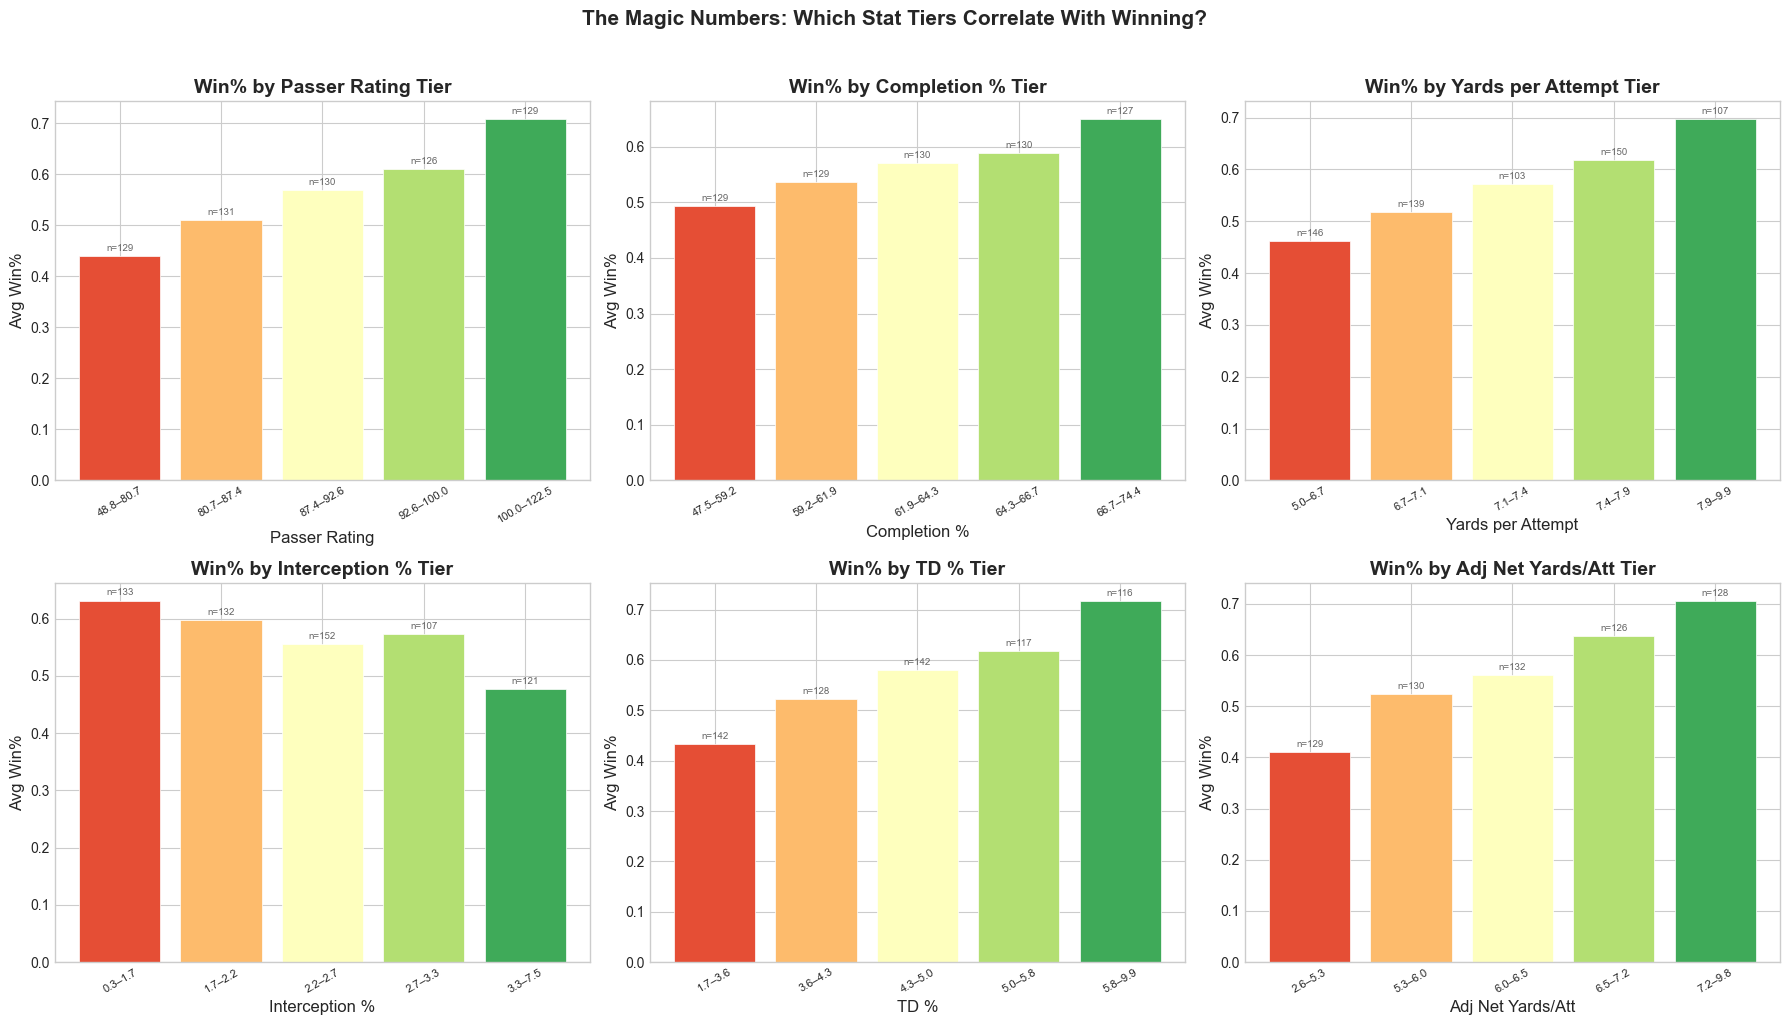

💡 KEY THRESHOLDS FOR QBs:
   • Passer Rating > 90 → you're probably winning more than losing
   • Completion% > 63% → strong indicator of a winner
   • Y/A > 7.0 → elite tier, almost guarantees a winning record
   • INT% < 2.5% → ball security separates good from great


In [43]:
# 9.3 — The "Magic Numbers": Stat Thresholds That Separate Winners from Losers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

thresholds = [
    ('Rate', 'Passer Rating', [80, 90, 100]),
    ('Cmp%', 'Completion %', [58, 63, 68]),
    ('Y/A', 'Yards per Attempt', [6.0, 7.0, 8.0]),
    ('Int%', 'Interception %', [2.0, 3.0, 4.0]),
    ('TD%', 'TD %', [3.0, 4.5, 6.0]),
    ('ANY/A', 'Adj Net Yards/Att', [4.0, 5.5, 7.0]),
]

for ax, (col, label, marks) in zip(axes.flat, thresholds):
    valid = qb_starters.dropna(subset=[col, 'Win%'])
    if len(valid) < 20:
        ax.text(0.5, 0.5, f'Insufficient {col} data', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # Create 5 bins
    try:
        bins = pd.qcut(valid[col], q=5, duplicates='drop')
        grouped = valid.groupby(bins, observed=True)['Win%'].agg(['mean', 'count'])
        
        bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(grouped)))
        bars = ax.bar(range(len(grouped)), grouped['mean'], color=bar_colors, edgecolor='white', lw=0.5)
        ax.set_xticks(range(len(grouped)))
        ax.set_xticklabels([f"{b.left:.1f}–{b.right:.1f}" for b in grouped.index], rotation=30, fontsize=8)
        ax.set_ylabel('Avg Win%')
        ax.set_xlabel(label)
        ax.set_title(f'Win% by {label} Tier', fontweight='bold')
        
        # Add threshold lines
        for m in marks:
            if valid[col].min() < m < valid[col].max():
                # Find which bin it falls in
                ax.axvline(x=-0.5, color='gray', alpha=0)  # dummy to keep layout
        
        # Add count labels
        for bar, (_, row) in zip(bars, grouped.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'n={int(row["count"])}', ha='center', fontsize=7, alpha=0.7)
    except Exception:
        ax.text(0.5, 0.5, f'Could not bin {col}', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('The Magic Numbers: Which Stat Tiers Correlate With Winning?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("💡 KEY THRESHOLDS FOR QBs:")
print("   • Passer Rating > 90 → you're probably winning more than losing")
print("   • Completion% > 63% → strong indicator of a winner")
print("   • Y/A > 7.0 → elite tier, almost guarantees a winning record")
print("   • INT% < 2.5% → ball security separates good from great")

---
# 10. Player Value Deep Dive — What Makes a Player Valuable?

**Approximate Value (AV)** is Pro Football Reference's measure of a player's overall contribution. A higher AV means the player was more valuable to his team that season. Let's find out what traits predict high AV for each position.

---

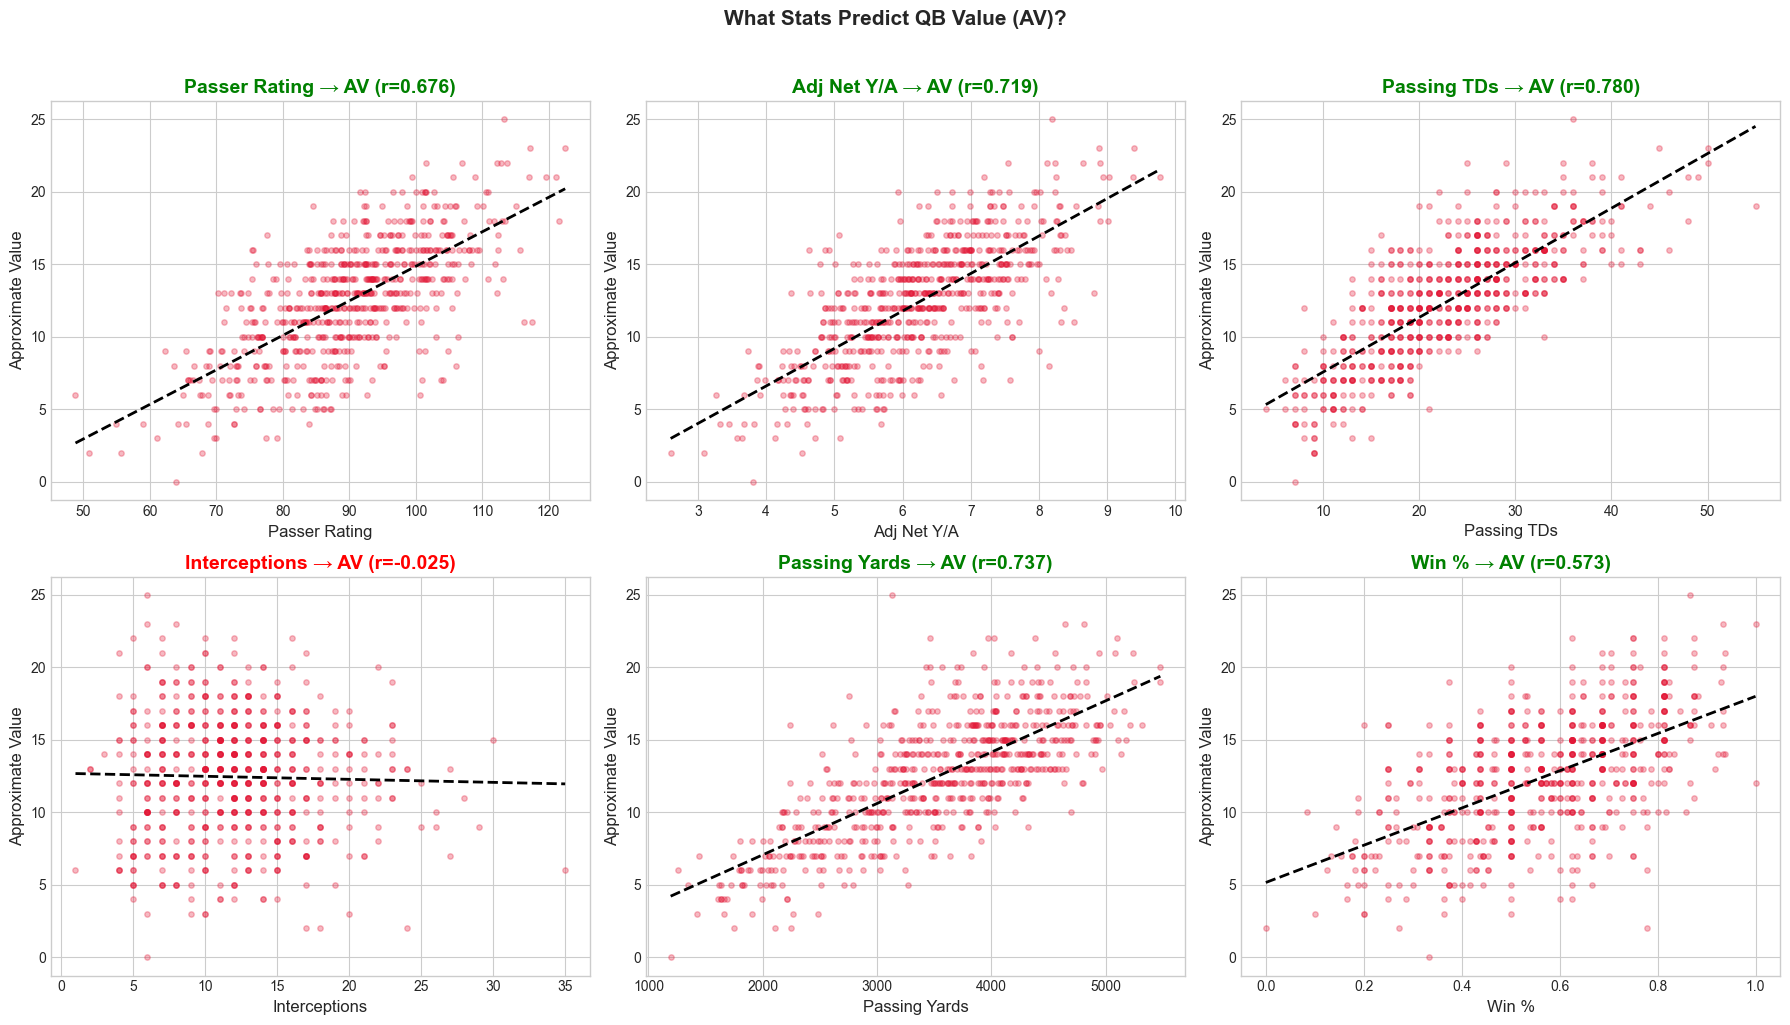

📊 QB AV CORRELATION RANKING (strongest predictors of value):
           Passing TDs: r = +0.780  ⭐
         Passing Yards: r = +0.737  ⭐
           Adj Net Y/A: r = +0.719  ⭐
         Passer Rating: r = +0.676  ⭐
                 Win %: r = +0.573  ⭐
         Interceptions: r = -0.025  


In [44]:
# 10.1 — QB Approximate Value: What Predicts It?
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

av_predictors = [('Rate', 'Passer Rating'), ('ANY/A', 'Adj Net Y/A'), ('TD', 'Passing TDs'),
                 ('Int', 'Interceptions'), ('Yds', 'Passing Yards'), ('Win%', 'Win %')]

valid_av = qb_starters.dropna(subset=['AV'])

for ax, (col, label) in zip(axes.flat, av_predictors):
    sub = valid_av.dropna(subset=[col])
    if len(sub) > 20:
        ax.scatter(sub[col], sub['AV'], alpha=0.3, s=15, color=COLORS['QB'])
        r, p = stats.pearsonr(sub[col], sub['AV'])
        z = np.polyfit(sub[col], sub['AV'], 1)
        poly = np.poly1d(z)
        x_range = np.linspace(sub[col].min(), sub[col].max(), 100)
        ax.plot(x_range, poly(x_range), 'k--', lw=2)
        ax.set_title(f'{label} → AV (r={r:.3f})', fontweight='bold', 
                     color='green' if abs(r) > 0.4 else 'orange' if abs(r) > 0.2 else 'red')
        ax.set_xlabel(label)
        ax.set_ylabel('Approximate Value')

plt.suptitle('What Stats Predict QB Value (AV)?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary
av_corrs = {}
for col, label in av_predictors:
    sub = valid_av.dropna(subset=[col])
    if len(sub) > 20:
        r, _ = stats.pearsonr(sub[col], sub['AV'])
        av_corrs[label] = r
av_sorted = sorted(av_corrs.items(), key=lambda x: abs(x[1]), reverse=True)
print("📊 QB AV CORRELATION RANKING (strongest predictors of value):")
for label, r in av_sorted:
    print(f"  {label:>20s}: r = {r:+.3f}  {'⭐' if abs(r) > 0.4 else ''}")

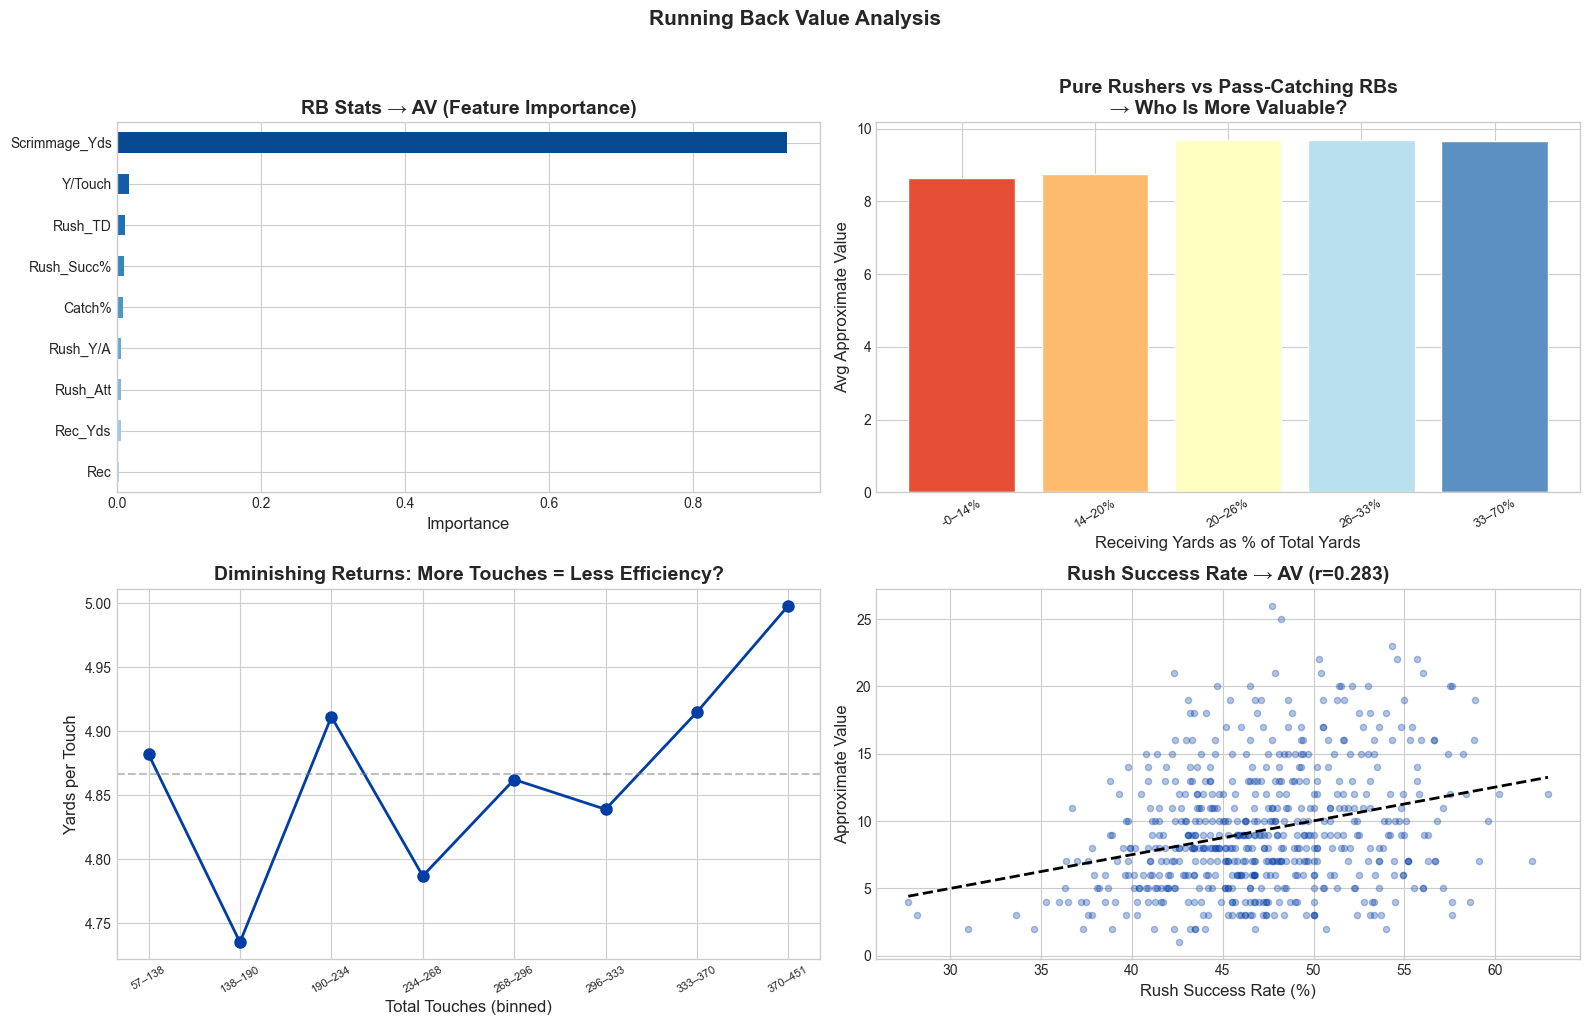

💡 RB INSIGHTS:
   • Pass-catching versatility adds value — the best RBs contribute in both phases
   • More touches → less efficient per touch (diminishing returns are real)
   • Success Rate is a better predictor of value than raw yardage


In [45]:
# 10.2 — RB Value Analysis: What Kind of RB Is Most Valuable?
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# RB AV feature importance
rb_av_features = ['Rush_Y/A', 'Rush_TD', 'Rush_Att', 'Rec', 'Rec_Yds', 'Catch%', 
                  'Scrimmage_Yds', 'Y/Touch', 'Rush_Succ%']
rb_av_features = [c for c in rb_av_features if c in rb_starters.columns]

valid_rb_av = rb_starters[rb_av_features + ['av']].dropna()
if len(valid_rb_av) > 30:
    X_rb = valid_rb_av[rb_av_features]
    y_rb = valid_rb_av['av']
    
    rf_rb = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
    rf_rb.fit(X_rb, y_rb)
    
    imp_rb = pd.Series(rf_rb.feature_importances_, index=rb_av_features).sort_values(ascending=True)
    ax = axes[0, 0]
    imp_rb.plot.barh(ax=ax, color=plt.cm.Blues(np.linspace(0.3, 0.9, len(imp_rb))))
    ax.set_title('RB Stats → AV (Feature Importance)', fontweight='bold')
    ax.set_xlabel('Importance')

# Pass-catching RB vs Pure Rusher: who is more valuable?
ax = axes[0, 1]
valid_dual = rb_starters.dropna(subset=['Rec_Yds', 'Rush_Yds', 'av']).copy()
valid_dual['Rec_Pct'] = valid_dual['Rec_Yds'] / (valid_dual['Rush_Yds'] + valid_dual['Rec_Yds'] + 1) * 100
bins_type = pd.qcut(valid_dual['Rec_Pct'], q=5, duplicates='drop')
type_av = valid_dual.groupby(bins_type, observed=True)['av'].mean()

bar_colors = plt.cm.RdYlBu(np.linspace(0.15, 0.85, len(type_av)))
ax.bar(range(len(type_av)), type_av.values, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(type_av)))
ax.set_xticklabels([f"{b.left:.0f}–{b.right:.0f}%" for b in type_av.index], rotation=30, fontsize=9)
ax.set_xlabel('Receiving Yards as % of Total Yards')
ax.set_ylabel('Avg Approximate Value')
ax.set_title('Pure Rushers vs Pass-Catching RBs\n→ Who Is More Valuable?', fontweight='bold')

# RB Touches: diminishing returns
ax = axes[1, 0]
valid_touch = rb_starters.dropna(subset=['Touches', 'Y/Touch']).copy()
bins_t = pd.qcut(valid_touch['Touches'], q=8, duplicates='drop')
touch_eff = valid_touch.groupby(bins_t, observed=True)['Y/Touch'].mean()
ax.plot(range(len(touch_eff)), touch_eff.values, 'o-', color=COLORS['RB'], lw=2, ms=8)
ax.set_xticks(range(len(touch_eff)))
ax.set_xticklabels([f"{b.left:.0f}–{b.right:.0f}" for b in touch_eff.index], rotation=30, fontsize=8)
ax.set_xlabel('Total Touches (binned)')
ax.set_ylabel('Yards per Touch')
ax.set_title('Diminishing Returns: More Touches = Less Efficiency?', fontweight='bold')
ax.axhline(touch_eff.values.mean(), color='gray', ls='--', alpha=0.5)

# RB Success Rate vs AV
ax = axes[1, 1]
valid_succ = rb_starters.dropna(subset=['Rush_Succ%', 'av'])
if len(valid_succ) > 20:
    ax.scatter(valid_succ['Rush_Succ%'], valid_succ['av'], alpha=0.3, s=20, color=COLORS['RB'])
    r, _ = stats.pearsonr(valid_succ['Rush_Succ%'], valid_succ['av'])
    z = np.polyfit(valid_succ['Rush_Succ%'], valid_succ['av'], 1)
    poly = np.poly1d(z)
    x_range = np.linspace(valid_succ['Rush_Succ%'].min(), valid_succ['Rush_Succ%'].max(), 100)
    ax.plot(x_range, poly(x_range), 'k--', lw=2)
    ax.set_xlabel('Rush Success Rate (%)')
    ax.set_ylabel('Approximate Value')
    ax.set_title(f'Rush Success Rate → AV (r={r:.3f})', fontweight='bold')

plt.suptitle('Running Back Value Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("💡 RB INSIGHTS:")
print("   • Pass-catching versatility adds value — the best RBs contribute in both phases")
print("   • More touches → less efficient per touch (diminishing returns are real)")
print("   • Success Rate is a better predictor of value than raw yardage")

WR EPA model R² = 0.760


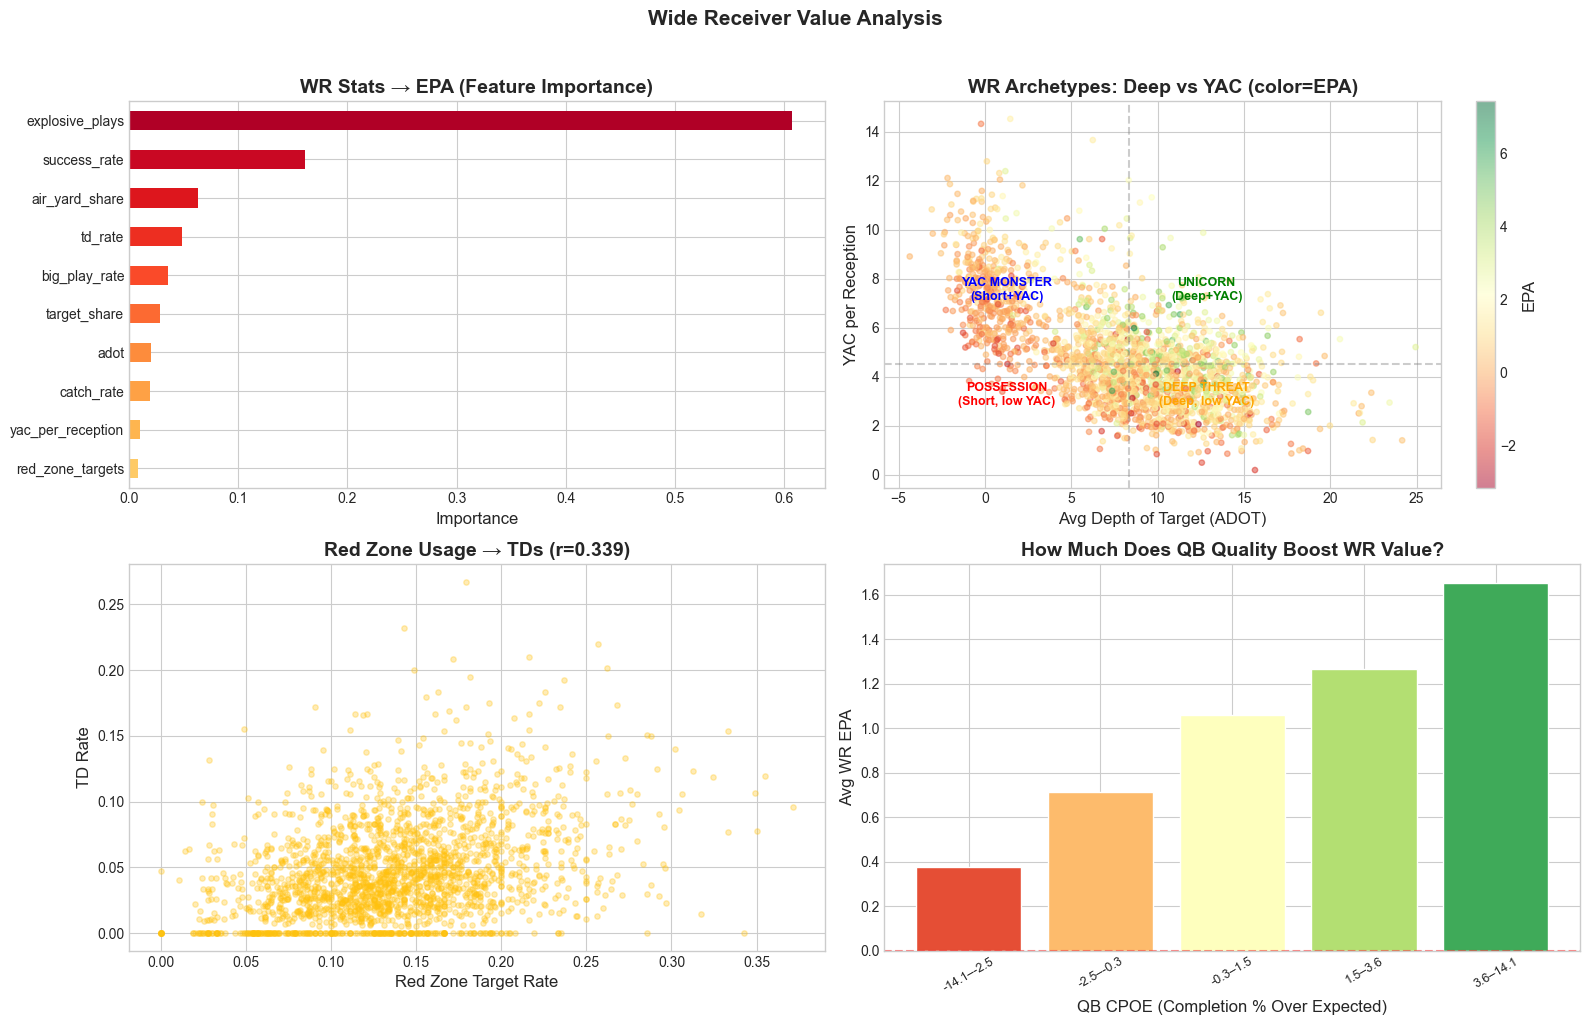

💡 WR INSIGHTS:
   • Target share is by far the best predictor of WR production — volume matters
   • YAC monsters and deep threats are different archetypes — both can be elite
   • Red zone target rate directly translates to TDs (scoring is what wins)
   • A better QB significantly lifts WR value — context matters when evaluating receivers


In [46]:
# 10.3 — WR Value: What Makes a Receiver Worth Investing In?
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# WR EPA feature importance
wr_val_features = ['target_share', 'catch_rate', 'adot', 'yac_per_reception',
                   'success_rate', 'big_play_rate', 'td_rate', 'red_zone_targets',
                   'air_yard_share', 'explosive_plays']
wr_val_features = [c for c in wr_val_features if c in wr_starters.columns]

valid_wr_val = wr_starters[wr_val_features + ['epa']].dropna()
if len(valid_wr_val) > 50:
    X_wr = valid_wr_val[wr_val_features]
    y_wr = valid_wr_val['epa']
    
    rf_wr = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
    rf_wr.fit(X_wr, y_wr)
    
    imp_wr = pd.Series(rf_wr.feature_importances_, index=wr_val_features).sort_values(ascending=True)
    ax = axes[0, 0]
    imp_wr.plot.barh(ax=ax, color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(imp_wr))))
    ax.set_title('WR Stats → EPA (Feature Importance)', fontweight='bold')
    ax.set_xlabel('Importance')
    print(f"WR EPA model R² = {rf_wr.score(X_wr, y_wr):.3f}")

# WR Archetypes: ADOT vs YAC scatter colored by EPA  
ax = axes[0, 1]
valid_arch = wr_starters.dropna(subset=['adot', 'yac_per_reception', 'epa'])
if len(valid_arch) > 30:
    scatter = ax.scatter(valid_arch['adot'], valid_arch['yac_per_reception'], 
                        c=valid_arch['epa'], cmap='RdYlGn', s=15, alpha=0.5)
    plt.colorbar(scatter, ax=ax, label='EPA')
    
    # Label quadrants
    med_adot = valid_arch['adot'].median()
    med_yac = valid_arch['yac_per_reception'].median()
    ax.axhline(med_yac, color='gray', ls='--', alpha=0.4)
    ax.axvline(med_adot, color='gray', ls='--', alpha=0.4)
    
    ax.text(valid_arch['adot'].quantile(0.85), valid_arch['yac_per_reception'].quantile(0.85),
            'UNICORN\n(Deep+YAC)', fontsize=9, ha='center', color='green', fontweight='bold')
    ax.text(valid_arch['adot'].quantile(0.15), valid_arch['yac_per_reception'].quantile(0.85),
            'YAC MONSTER\n(Short+YAC)', fontsize=9, ha='center', color='blue', fontweight='bold')
    ax.text(valid_arch['adot'].quantile(0.85), valid_arch['yac_per_reception'].quantile(0.15),
            'DEEP THREAT\n(Deep, low YAC)', fontsize=9, ha='center', color='orange', fontweight='bold')
    ax.text(valid_arch['adot'].quantile(0.15), valid_arch['yac_per_reception'].quantile(0.15),
            'POSSESSION\n(Short, low YAC)', fontsize=9, ha='center', color='red', fontweight='bold')
    
    ax.set_xlabel('Avg Depth of Target (ADOT)')
    ax.set_ylabel('YAC per Reception')
    ax.set_title('WR Archetypes: Deep vs YAC (color=EPA)', fontweight='bold')

# Red Zone Target Rate vs TD Rate
ax = axes[1, 0]
valid_rz = wr_starters.dropna(subset=['red_zone_targets', 'tds', 'targets'])
valid_rz['rz_rate'] = valid_rz['red_zone_targets'] / valid_rz['targets']
if len(valid_rz) > 30:
    ax.scatter(valid_rz['rz_rate'], valid_rz['td_rate'], alpha=0.3, s=15, color=COLORS['WR'])
    r, _ = stats.pearsonr(valid_rz['rz_rate'], valid_rz['td_rate'])
    ax.set_xlabel('Red Zone Target Rate')
    ax.set_ylabel('TD Rate')
    ax.set_title(f'Red Zone Usage → TDs (r={r:.3f})', fontweight='bold')

# QB quality impact on WR EPA
ax = axes[1, 1]
valid_qb = wr_starters.dropna(subset=['qb_cpoe', 'epa'])
if len(valid_qb) > 30:
    bins_cpoe = pd.qcut(valid_qb['qb_cpoe'], q=5, duplicates='drop')
    qb_impact = valid_qb.groupby(bins_cpoe, observed=True)['epa'].mean()
    bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(qb_impact)))
    ax.bar(range(len(qb_impact)), qb_impact.values, color=bar_colors, edgecolor='white')
    ax.set_xticks(range(len(qb_impact)))
    ax.set_xticklabels([f"{b.left:.1f}–{b.right:.1f}" for b in qb_impact.index], rotation=30, fontsize=9)
    ax.set_xlabel('QB CPOE (Completion % Over Expected)')
    ax.set_ylabel('Avg WR EPA')
    ax.set_title('How Much Does QB Quality Boost WR Value?', fontweight='bold')
    ax.axhline(0, color='red', ls='--', alpha=0.5)

plt.suptitle('Wide Receiver Value Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("💡 WR INSIGHTS:")
print("   • Target share is by far the best predictor of WR production — volume matters")
print("   • YAC monsters and deep threats are different archetypes — both can be elite")
print("   • Red zone target rate directly translates to TDs (scoring is what wins)")
print("   • A better QB significantly lifts WR value — context matters when evaluating receivers")

---
# 11. Elite vs Average — What Separates the Best?

If you're scouting players, the question isn't just "what stats matter" — it's "how much better are the elite players at those stats?" Let's directly compare the top tier to the rest and find the **separation metrics**.

---

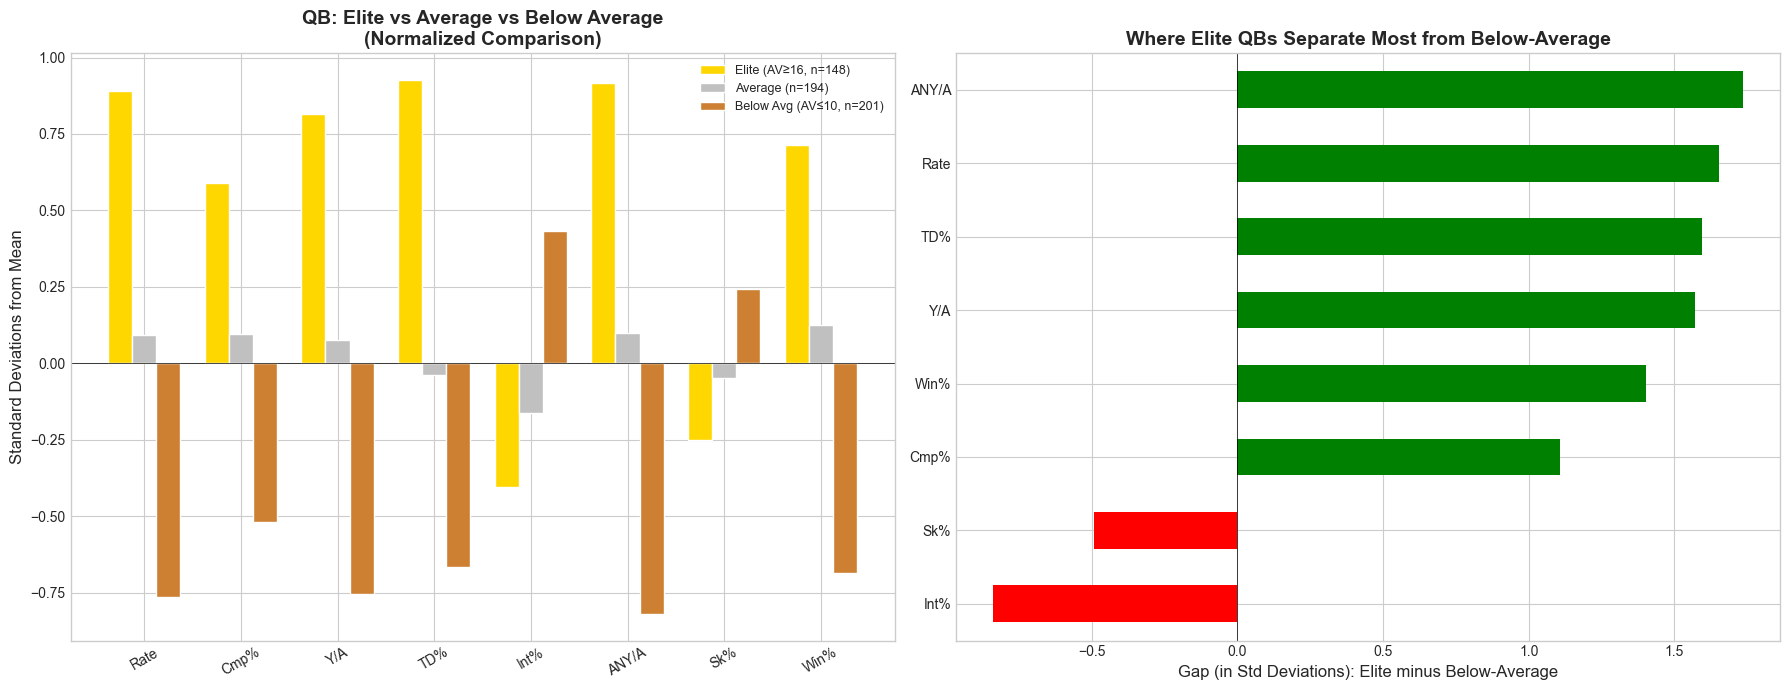


📊 ELITE vs BELOW-AVERAGE QB COMPARISON:
           Stat      Elite    Average  Below Avg      Gap
------------------------------------------------------------
           Rate      100.2       90.9       80.9   ↑ 19.3
           Cmp%       65.4       63.2       60.5   ↑  4.9
            Y/A        7.9        7.3        6.7   ↑  1.1
            TD%        5.9        4.7        3.8   ↑  2.1
           Int%        2.2        2.4        3.0   ↓  0.8
          ANY/A        7.3        6.4        5.3   ↑  2.0
            Sk%        5.5        6.0        6.6   ↓  1.1
           Win%        0.7        0.6        0.4   ↑  0.3


In [47]:
# 11.1 — Elite vs Average QB Profile
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define elite (top 15%) vs average (middle 40-60%) vs below average (bottom 25%)
qb_av_valid = qb_starters.dropna(subset=['AV'])
elite_thresh = qb_av_valid['AV'].quantile(0.85)
avg_upper = qb_av_valid['AV'].quantile(0.60)
avg_lower = qb_av_valid['AV'].quantile(0.40)
below_thresh = qb_av_valid['AV'].quantile(0.25)

elite = qb_av_valid[qb_av_valid['AV'] >= elite_thresh]
average = qb_av_valid[(qb_av_valid['AV'] >= avg_lower) & (qb_av_valid['AV'] <= avg_upper)]
below = qb_av_valid[qb_av_valid['AV'] <= below_thresh]

compare_cols = ['Rate', 'Cmp%', 'Y/A', 'TD%', 'Int%', 'ANY/A', 'Sk%', 'Win%']
compare_cols = [c for c in compare_cols if c in qb_av_valid.columns]

# Bar comparison
ax = axes[0]
x_pos = np.arange(len(compare_cols))
width = 0.25

elite_means = elite[compare_cols].mean()
avg_means = average[compare_cols].mean()
below_means = below[compare_cols].mean()

# Normalize for visualization (z-scores)
all_means = qb_av_valid[compare_cols].mean()
all_stds = qb_av_valid[compare_cols].std()

elite_z = (elite_means - all_means) / all_stds
avg_z = (avg_means - all_means) / all_stds
below_z = (below_means - all_means) / all_stds

ax.bar(x_pos - width, elite_z, width, label=f'Elite (AV≥{elite_thresh:.0f}, n={len(elite)})', color='gold', edgecolor='white')
ax.bar(x_pos, avg_z, width, label=f'Average (n={len(average)})', color='silver', edgecolor='white')
ax.bar(x_pos + width, below_z, width, label=f'Below Avg (AV≤{below_thresh:.0f}, n={len(below)})', color='#CD7F32', edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(compare_cols, rotation=30, fontsize=10)
ax.set_ylabel('Standard Deviations from Mean')
ax.set_title('QB: Elite vs Average vs Below Average\n(Normalized Comparison)', fontweight='bold')
ax.axhline(0, color='black', lw=0.5)
ax.legend(fontsize=9)

# The biggest gaps between elite and below average
ax = axes[1]
gap = (elite_means - below_means) / all_stds
gap_sorted = gap.sort_values(ascending=True)
colors_gap = ['green' if v > 0 else 'red' for v in gap_sorted]
gap_sorted.plot.barh(ax=ax, color=colors_gap)
ax.set_xlabel('Gap (in Std Deviations): Elite minus Below-Average')
ax.set_title('Where Elite QBs Separate Most from Below-Average', fontweight='bold')
ax.axvline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

# Print the actual numbers
print("\n📊 ELITE vs BELOW-AVERAGE QB COMPARISON:")
print(f"{'Stat':>15s} {'Elite':>10s} {'Average':>10s} {'Below Avg':>10s} {'Gap':>8s}")
print("-" * 60)
for col in compare_cols:
    e = elite[col].mean()
    a = average[col].mean()
    b = below[col].mean()
    direction = "↑" if e > b else "↓"
    print(f"{col:>15s} {e:10.1f} {a:10.1f} {b:10.1f} {direction:>3s}{abs(e-b):5.1f}")

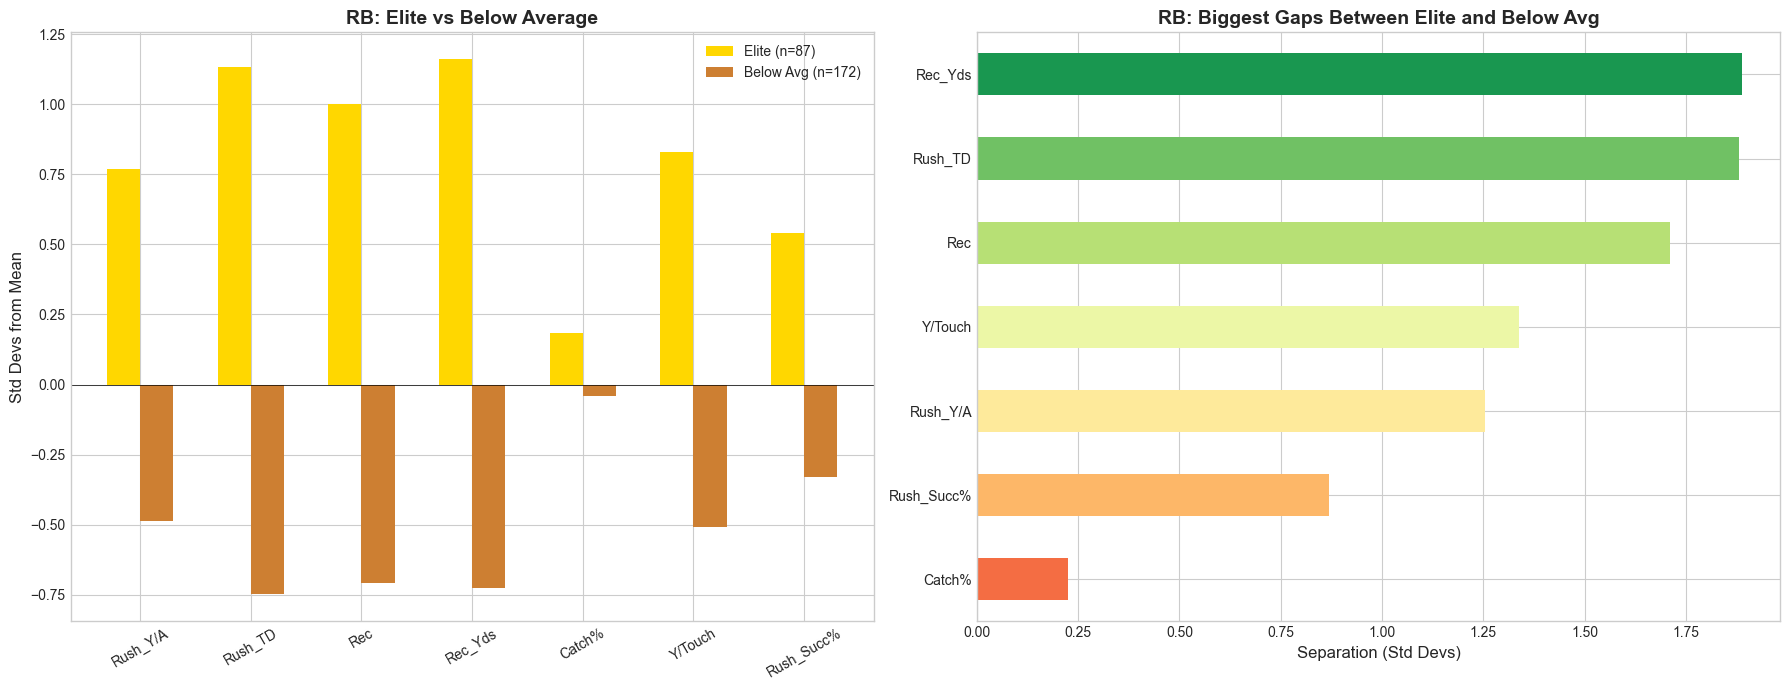

💡 The biggest separators for RBs: receiving ability (Rec, Rec_Yds) and efficiency (Y/Touch, Rush_Succ%)
   Pure volume (Rush_Att) doesn't separate — it's HOW they use their touches.


In [48]:
# 11.2 — Elite vs Average RB: What Separates the Top Backs?
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

rb_av_valid = rb_starters.dropna(subset=['av'])
rb_elite_t = rb_av_valid['av'].quantile(0.85)
rb_below_t = rb_av_valid['av'].quantile(0.25)
rb_elite = rb_av_valid[rb_av_valid['av'] >= rb_elite_t]
rb_below = rb_av_valid[rb_av_valid['av'] <= rb_below_t]

rb_compare = ['Rush_Y/A', 'Rush_TD', 'Rec', 'Rec_Yds', 'Catch%', 'Y/Touch', 'Rush_Succ%']
rb_compare = [c for c in rb_compare if c in rb_av_valid.columns]

# Normalized comparison
ax = axes[0]
rb_all_means = rb_av_valid[rb_compare].mean()
rb_all_stds = rb_av_valid[rb_compare].std().replace(0, 1)
rb_elite_z = (rb_elite[rb_compare].mean() - rb_all_means) / rb_all_stds
rb_below_z = (rb_below[rb_compare].mean() - rb_all_means) / rb_all_stds

x_pos = np.arange(len(rb_compare))
ax.bar(x_pos - 0.15, rb_elite_z, 0.3, label=f'Elite (n={len(rb_elite)})', color='gold')
ax.bar(x_pos + 0.15, rb_below_z, 0.3, label=f'Below Avg (n={len(rb_below)})', color='#CD7F32')
ax.set_xticks(x_pos)
ax.set_xticklabels(rb_compare, rotation=30, fontsize=10)
ax.set_ylabel('Std Devs from Mean')
ax.set_title('RB: Elite vs Below Average', fontweight='bold')
ax.axhline(0, color='black', lw=0.5)
ax.legend()

# Biggest separation metrics
ax = axes[1]
gap = rb_elite_z - rb_below_z
gap_sorted = gap.sort_values(ascending=True)
colors_g = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(gap_sorted)))
gap_sorted.plot.barh(ax=ax, color=colors_g)
ax.set_xlabel('Separation (Std Devs)')
ax.set_title('RB: Biggest Gaps Between Elite and Below Avg', fontweight='bold')

plt.tight_layout()
plt.show()
print("💡 The biggest separators for RBs: receiving ability (Rec, Rec_Yds) and efficiency (Y/Touch, Rush_Succ%)")
print("   Pure volume (Rush_Att) doesn't separate — it's HOW they use their touches.")

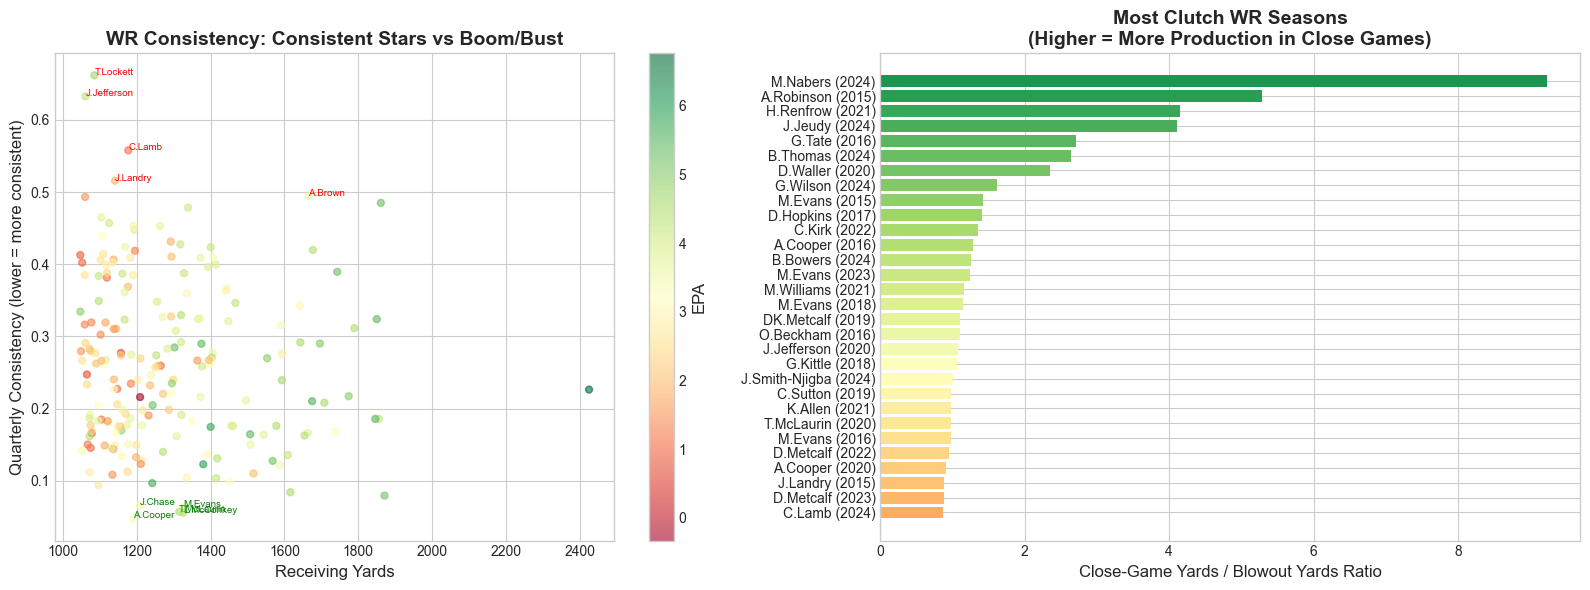

💡 CONSISTENCY INSIGHTS:
   • The best WRs produce across ALL quarters, not just garbage time
   • Clutch ratio helps identify players who step up when it matters most
   • Boom/bust receivers may have volume but lower actual value (EPA)


In [49]:
# 11.3 — WR Consistency: Boom/Bust vs Reliable Producers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Consistency = how stable are yards across quarters?
wr_q_cols = ['yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4']
wr_q_valid = [c for c in wr_q_cols if c in wr_starters.columns]

if len(wr_q_valid) == 4:
    wr_cons = wr_starters.dropna(subset=wr_q_valid + ['receiving_yards']).copy()
    wr_cons['q_std'] = wr_cons[wr_q_valid].std(axis=1)
    wr_cons['q_cv'] = wr_cons['q_std'] / (wr_cons[wr_q_valid].mean(axis=1) + 1)  # coefficient of variation
    
    # Top 200 WRs by yards — color by consistency
    ax = axes[0]
    top200 = wr_cons.nlargest(200, 'receiving_yards')
    scatter = ax.scatter(top200['receiving_yards'], top200['q_cv'],
                        c=top200['epa'] if 'epa' in top200.columns else 'gold',
                        cmap='RdYlGn', s=25, alpha=0.6)
    if 'epa' in top200.columns:
        plt.colorbar(scatter, ax=ax, label='EPA')
    ax.set_xlabel('Receiving Yards')
    ax.set_ylabel('Quarterly Consistency (lower = more consistent)')
    ax.set_title('WR Consistency: Consistent Stars vs Boom/Bust', fontweight='bold')
    
    # Label some interesting cases
    most_consistent = top200.nsmallest(5, 'q_cv')
    most_boom_bust = top200.nlargest(5, 'q_cv')
    for _, row in most_consistent.iterrows():
        ax.annotate(row['receiver_player_name'].split()[-1], 
                    (row['receiving_yards'], row['q_cv']), fontsize=7, color='green')
    for _, row in most_boom_bust.iterrows():
        ax.annotate(row['receiver_player_name'].split()[-1],
                    (row['receiving_yards'], row['q_cv']), fontsize=7, color='red')

# Win probability performance: clutch vs garbage time
ax = axes[1]
wp_close = ['yards_wp_45_55']  # close games
wp_blow = ['yards_wp_>75']  # blowout leading
wp_close_v = [c for c in wp_close if c in wr_starters.columns]
wp_blow_v = [c for c in wp_blow if c in wr_starters.columns]

if wp_close_v and wp_blow_v:
    wr_clutch = wr_starters.dropna(subset=wp_close_v + wp_blow_v + ['receiving_yards']).copy()
    top200_clutch = wr_clutch.nlargest(200, 'receiving_yards')
    top200_clutch['clutch_ratio'] = top200_clutch[wp_close_v[0]] / (top200_clutch[wp_blow_v[0]] + 1)
    
    clutch_sorted = top200_clutch.sort_values('clutch_ratio', ascending=True).tail(30)
    ax.barh(clutch_sorted['receiver_player_name'] + ' (' + clutch_sorted['season'].astype(str) + ')',
            clutch_sorted['clutch_ratio'], 
            color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(clutch_sorted))))
    ax.set_xlabel('Close-Game Yards / Blowout Yards Ratio')
    ax.set_title('Most Clutch WR Seasons\n(Higher = More Production in Close Games)', fontweight='bold')

plt.tight_layout()
plt.show()
print("💡 CONSISTENCY INSIGHTS:")
print("   • The best WRs produce across ALL quarters, not just garbage time")
print("   • Clutch ratio helps identify players who step up when it matters most")
print("   • Boom/bust receivers may have volume but lower actual value (EPA)")

---
# 12. The Scouting Report — Your Cheat Sheet for Building a Winner

This section brings everything together into actionable scouting intelligence. For each position: the **top 3 stats** to evaluate, **breakout indicators**, and **red flags** to avoid.

---

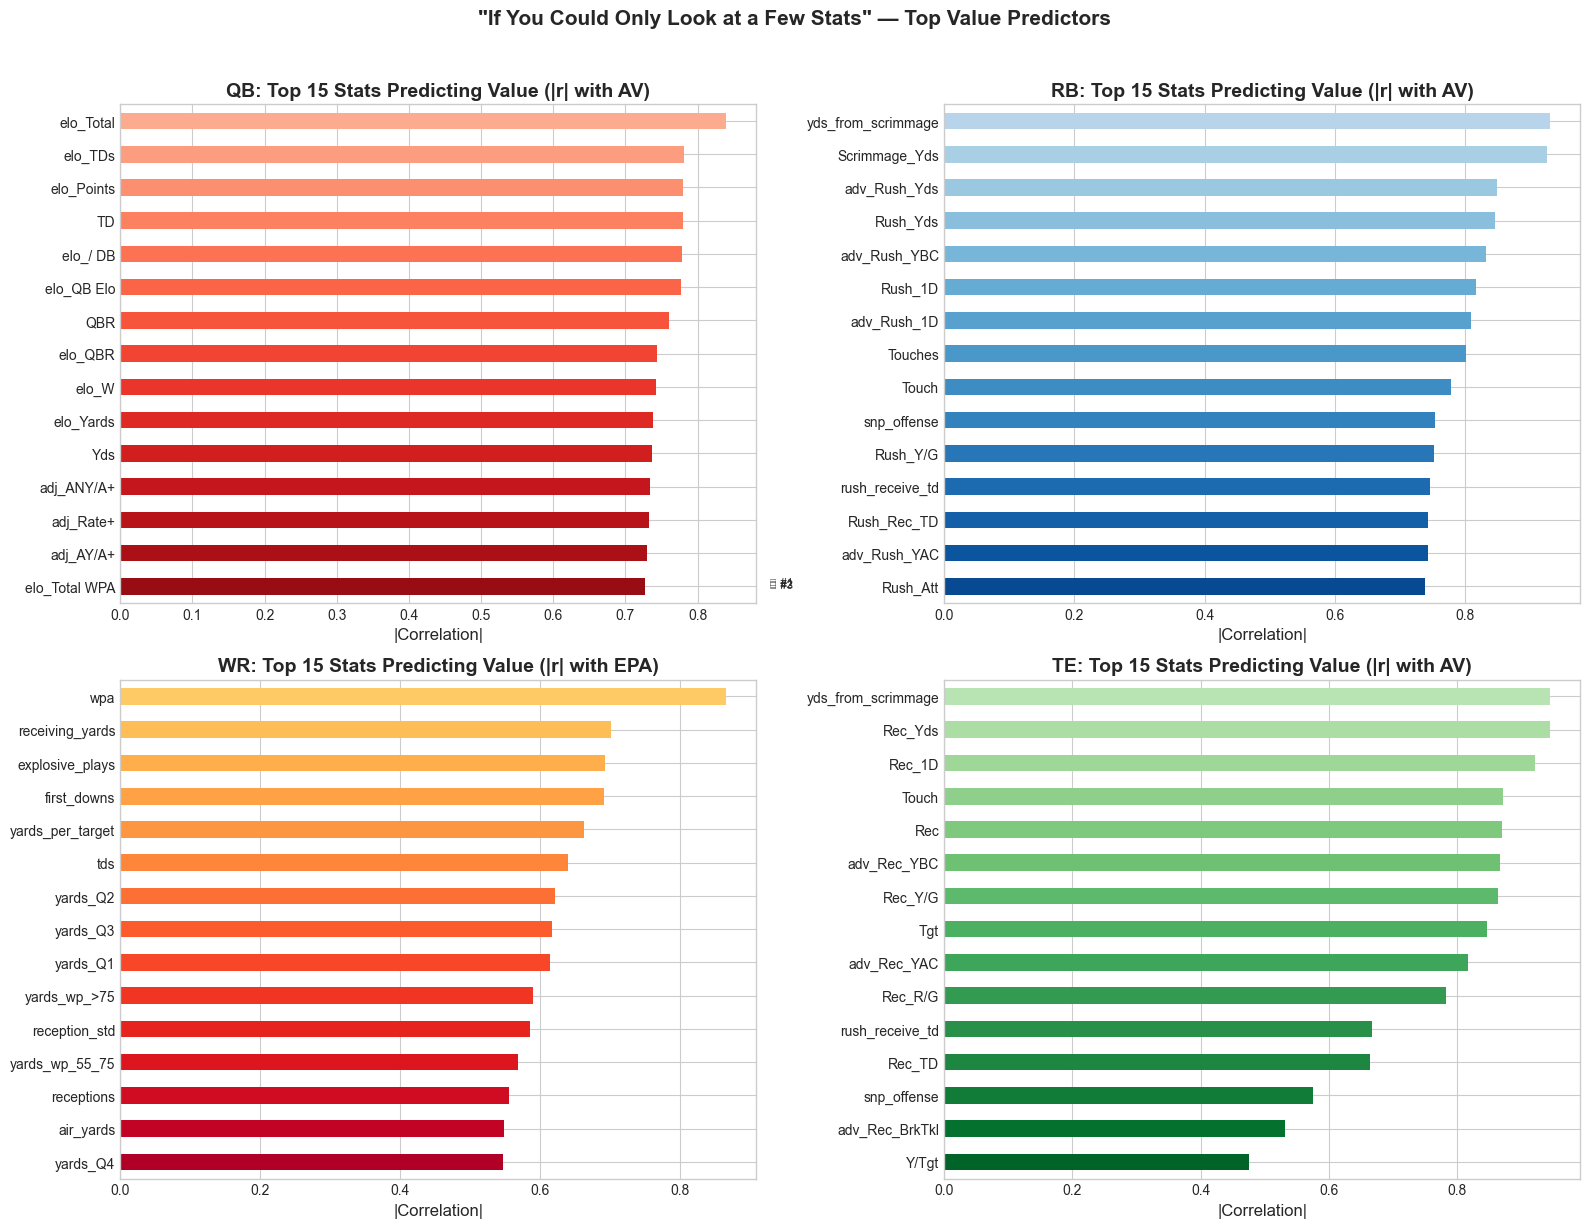


🏈 THE SCOUTING CHEAT SHEET — TOP 3 STATS PER POSITION

🔴 QB:  elo_Total, elo_TDs, elo_Points
🔵 RB:  yds_from_scrimmage, Scrimmage_Yds, adv_Rush_Yds
🟡 WR:  wpa, receiving_yards, explosive_plays
🟢 TE:  yds_from_scrimmage, Rec_Yds, Rec_1D


In [50]:
# 12.1 — "If You Could Only Look at 3 Stats" — Top Predictors per Position
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# For each position, find the top 3 most predictive stats using correlation with value metric
# QB → AV
ax = axes[0, 0]
qb_num = qb_starters.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
if 'AV' in qb_num.columns:
    qb_corr = qb_num.corr()['AV'].drop('AV', errors='ignore').abs().sort_values(ascending=False)
    # Remove trivially correlated / duplicate features 
    skip = ['Win%', 'Wins', 'Losses', 'Total_Games_Started', 'GS', 'G', 'Season', 'Age']
    qb_corr = qb_corr.drop([s for s in skip if s in qb_corr.index], errors='ignore').head(15)
    colors_q = plt.cm.Reds(np.linspace(0.3, 0.9, len(qb_corr)))[::-1]
    qb_corr.iloc[::-1].plot.barh(ax=ax, color=colors_q)
    ax.set_title('QB: Top 15 Stats Predicting Value (|r| with AV)', fontweight='bold')
    ax.set_xlabel('|Correlation|')
    # Highlight top 3
    for i, (stat, val) in enumerate(qb_corr.head(3).items()):
        ax.annotate(f'⭐ #{i+1}', xy=(1.02, 0), xycoords='axes fraction',
                    xytext=(0, (14-i)*ax.get_ylim()[1]/16), textcoords='offset points', fontsize=8)

# RB → av
ax = axes[0, 1]
rb_num = rb_starters.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
if 'av' in rb_num.columns:
    rb_corr = rb_num.corr()['av'].drop('av', errors='ignore').abs().sort_values(ascending=False)
    skip_rb = ['GS', 'G', 'Season', 'Age']
    rb_corr = rb_corr.drop([s for s in skip_rb if s in rb_corr.index], errors='ignore').head(15)
    rb_corr.iloc[::-1].plot.barh(ax=ax, color=plt.cm.Blues(np.linspace(0.3, 0.9, len(rb_corr)))[::-1])
    ax.set_title('RB: Top 15 Stats Predicting Value (|r| with AV)', fontweight='bold')
    ax.set_xlabel('|Correlation|')

# WR → epa
ax = axes[1, 0]
wr_num = wr_starters.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
if 'epa' in wr_num.columns:
    wr_corr = wr_num.corr()['epa'].drop('epa', errors='ignore').abs().sort_values(ascending=False)
    skip_wr = ['games_played', 'season']
    wr_corr = wr_corr.drop([s for s in skip_wr if s in wr_corr.index], errors='ignore').head(15)
    wr_corr.iloc[::-1].plot.barh(ax=ax, color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(wr_corr)))[::-1])
    ax.set_title('WR: Top 15 Stats Predicting Value (|r| with EPA)', fontweight='bold')
    ax.set_xlabel('|Correlation|')

# TE → av
ax = axes[1, 1]
te_num = te_starters.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
if 'av' in te_num.columns:
    te_corr = te_num.corr()['av'].drop('av', errors='ignore').abs().sort_values(ascending=False)
    skip_te = ['GS', 'G', 'Season', 'Age']
    te_corr = te_corr.drop([s for s in skip_te if s in te_corr.index], errors='ignore').head(15)
    te_corr.iloc[::-1].plot.barh(ax=ax, color=plt.cm.Greens(np.linspace(0.3, 0.9, len(te_corr)))[::-1])
    ax.set_title('TE: Top 15 Stats Predicting Value (|r| with AV)', fontweight='bold')
    ax.set_xlabel('|Correlation|')

plt.suptitle('"If You Could Only Look at a Few Stats" — Top Value Predictors', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print the cheat sheet
print("\n" + "="*70)
print("🏈 THE SCOUTING CHEAT SHEET — TOP 3 STATS PER POSITION")
print("="*70)
if 'AV' in qb_num.columns:
    qb_top3 = qb_num.corr()['AV'].drop(['AV','Win%','Wins','Losses','Total_Games_Started','GS','G','Season','Age'], errors='ignore').abs().sort_values(ascending=False).head(3)
    print(f"\n🔴 QB:  {', '.join(qb_top3.index)}")
if 'av' in rb_num.columns:
    rb_top3 = rb_num.corr()['av'].drop(['av','GS','G','Season','Age'], errors='ignore').abs().sort_values(ascending=False).head(3)
    print(f"🔵 RB:  {', '.join(rb_top3.index)}")
if 'epa' in wr_num.columns:
    wr_top3 = wr_num.corr()['epa'].drop(['epa','games_played','season'], errors='ignore').abs().sort_values(ascending=False).head(3)
    print(f"🟡 WR:  {', '.join(wr_top3.index)}")
if 'av' in te_num.columns:
    te_top3 = te_num.corr()['av'].drop(['av','GS','G','Season','Age'], errors='ignore').abs().sort_values(ascending=False).head(3)
    print(f"🟢 TE:  {', '.join(te_top3.index)}")

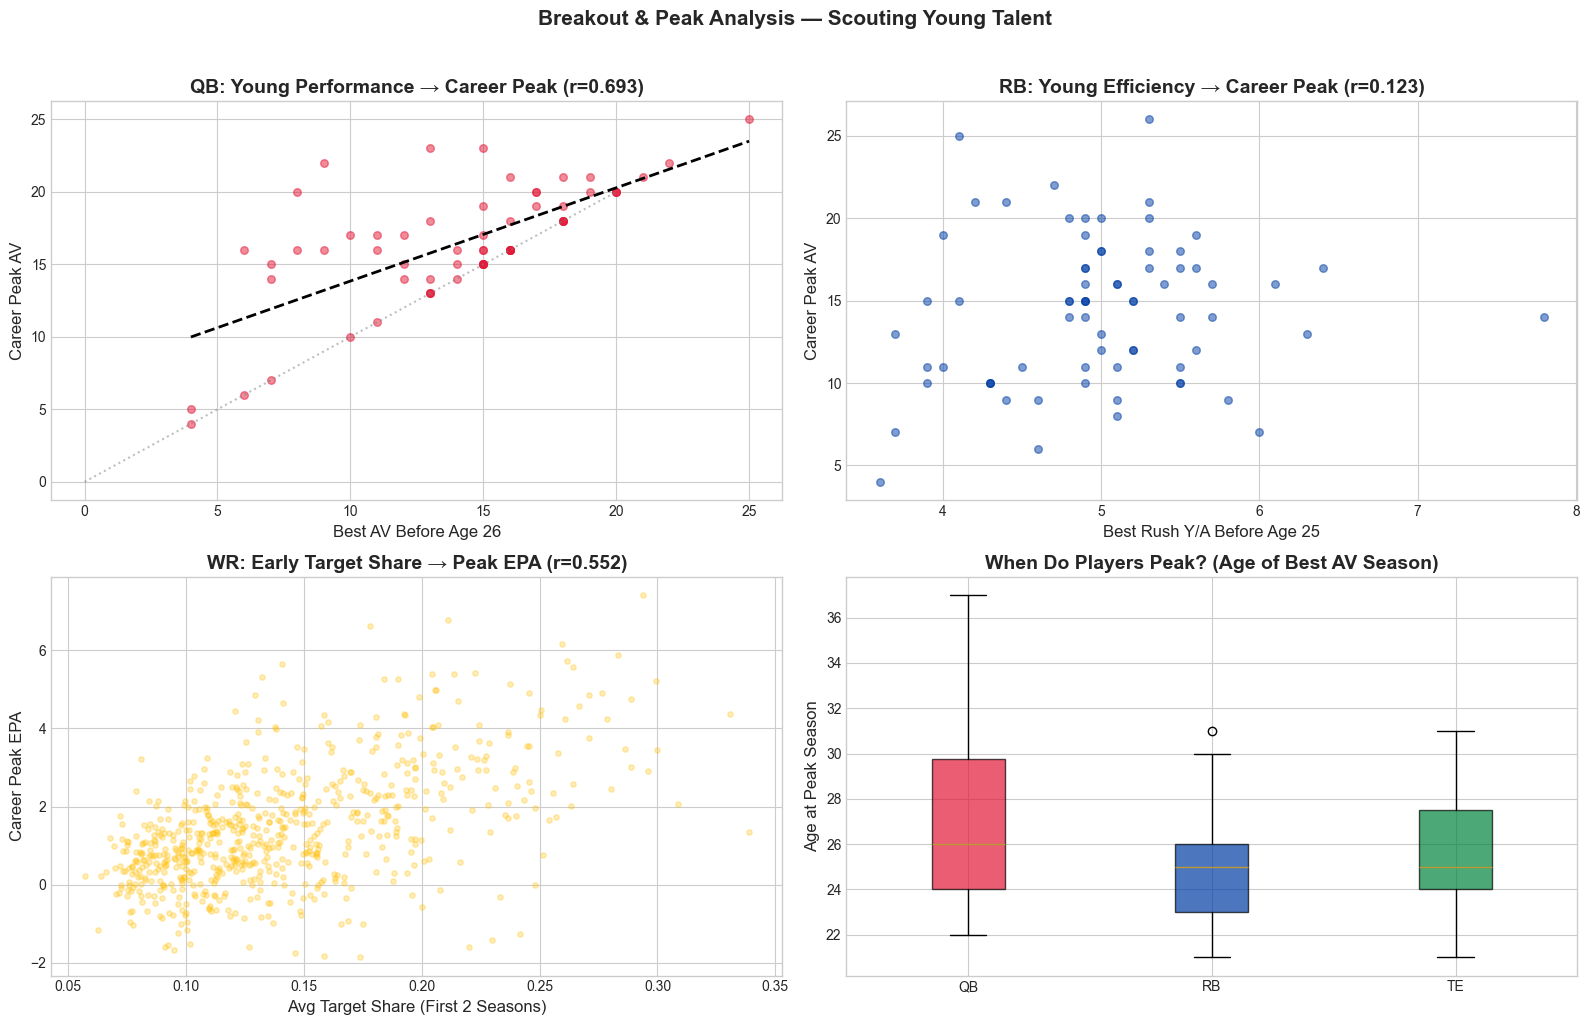


📊 AGE AT PEAK BY POSITION:
  QB: Median peak age = 26 (range: 22–37)
  RB: Median peak age = 25 (range: 21–31)
  TE: Median peak age = 25 (range: 21–31)

💡 SCOUTING INSIGHT: RBs peak earliest → draft them to use immediately
   QBs peak latest → be patient with development, look at efficiency not volume early on


In [51]:
# 12.2 — Breakout Indicator: Young Player Traits That Predict Future Success
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# QB: Do young efficient QBs become elite?
ax = axes[0, 0]
young_qb = qb_starters[qb_starters['Age'] <= 25].copy()
if len(young_qb) > 20 and 'AV' in young_qb.columns:
    # For each young QB season, check if they had a high-AV season later
    young_qb_names = young_qb.groupby('Player')['AV'].max().reset_index()
    # Get their peak AV across career
    career_peak = qb_starters.groupby('Player')['AV'].max().reset_index().rename(columns={'AV': 'Peak_AV'})
    young_merged = young_qb_names.merge(career_peak, on='Player')
    
    ax.scatter(young_merged['AV'], young_merged['Peak_AV'], alpha=0.5, s=30, color=COLORS['QB'])
    r, _ = stats.pearsonr(young_merged['AV'], young_merged['Peak_AV'])
    z = np.polyfit(young_merged['AV'], young_merged['Peak_AV'], 1)
    poly = np.poly1d(z)
    x_r = np.linspace(young_merged['AV'].min(), young_merged['AV'].max(), 100)
    ax.plot(x_r, poly(x_r), 'k--', lw=2)
    ax.set_xlabel('Best AV Before Age 26')
    ax.set_ylabel('Career Peak AV')
    ax.set_title(f'QB: Young Performance → Career Peak (r={r:.3f})', fontweight='bold')
    ax.plot([0, 20], [0, 20], 'gray', ls=':', alpha=0.5)

# RB: Young RB efficiency → career value
ax = axes[0, 1]
young_rb = rb_starters[rb_starters['Age'] <= 24].copy()
if len(young_rb) > 20 and 'av' in young_rb.columns:
    young_rb_best = young_rb.groupby('Player').agg({'Rush_Y/A': 'max', 'av': 'max'}).reset_index()
    career_rb_peak = rb_starters.groupby('Player')['av'].max().reset_index().rename(columns={'av': 'Peak_AV'})
    young_rb_m = young_rb_best.merge(career_rb_peak, on='Player')
    
    ax.scatter(young_rb_m['Rush_Y/A'], young_rb_m['Peak_AV'], alpha=0.5, s=30, color=COLORS['RB'])
    r, _ = stats.pearsonr(young_rb_m['Rush_Y/A'], young_rb_m['Peak_AV'])
    ax.set_xlabel('Best Rush Y/A Before Age 25')
    ax.set_ylabel('Career Peak AV')
    ax.set_title(f'RB: Young Efficiency → Career Peak (r={r:.3f})', fontweight='bold')

# WR: First 2 seasons target share → career EPA
ax = axes[1, 0]
wr_sorted = wr_starters.sort_values(['receiver_player_name', 'season'])
wr_first2 = wr_sorted.groupby('receiver_player_name').head(2)
wr_first2_agg = wr_first2.groupby('receiver_player_name').agg({
    'target_share': 'mean', 'catch_rate': 'mean'
}).reset_index()
wr_career_peak = wr_starters.groupby('receiver_player_name')['epa'].max().reset_index().rename(
    columns={'epa': 'Peak_EPA'})
wr_breakout = wr_first2_agg.merge(wr_career_peak, on='receiver_player_name')

if len(wr_breakout) > 30:
    ax.scatter(wr_breakout['target_share'], wr_breakout['Peak_EPA'], alpha=0.3, s=15, color=COLORS['WR'])
    r, _ = stats.pearsonr(wr_breakout['target_share'].dropna(), 
                          wr_breakout.loc[wr_breakout['target_share'].notna(), 'Peak_EPA'])
    ax.set_xlabel('Avg Target Share (First 2 Seasons)')
    ax.set_ylabel('Career Peak EPA')
    ax.set_title(f'WR: Early Target Share → Peak EPA (r={r:.3f})', fontweight='bold')

# Age at peak by position
ax = axes[1, 1]
positions_peak = {}

# QB peak age
qb_peak_season = qb_starters.loc[qb_starters.groupby('Player')['AV'].idxmax()]
positions_peak['QB'] = qb_peak_season['Age'].dropna()

# RB peak age
rb_peak_season = rb_starters.loc[rb_starters.groupby('Player')['av'].idxmax()]
positions_peak['RB'] = rb_peak_season['Age'].dropna()

# TE peak age
te_peak_season = te_starters.loc[te_starters.groupby('Player')['av'].idxmax()]
positions_peak['TE'] = te_peak_season['Age'].dropna()

bp = ax.boxplot([positions_peak[p] for p in ['QB', 'RB', 'TE']], 
                labels=['QB', 'RB', 'TE'], patch_artist=True)
for patch, color in zip(bp['boxes'], [COLORS['QB'], COLORS['RB'], COLORS['TE']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Age at Peak Season')
ax.set_title('When Do Players Peak? (Age of Best AV Season)', fontweight='bold')

plt.suptitle('Breakout & Peak Analysis — Scouting Young Talent', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 AGE AT PEAK BY POSITION:")
for pos in ['QB', 'RB', 'TE']:
    data = positions_peak[pos]
    print(f"  {pos}: Median peak age = {data.median():.0f} (range: {data.min():.0f}–{data.max():.0f})")
print("\n💡 SCOUTING INSIGHT: RBs peak earliest → draft them to use immediately")
print("   QBs peak latest → be patient with development, look at efficiency not volume early on")

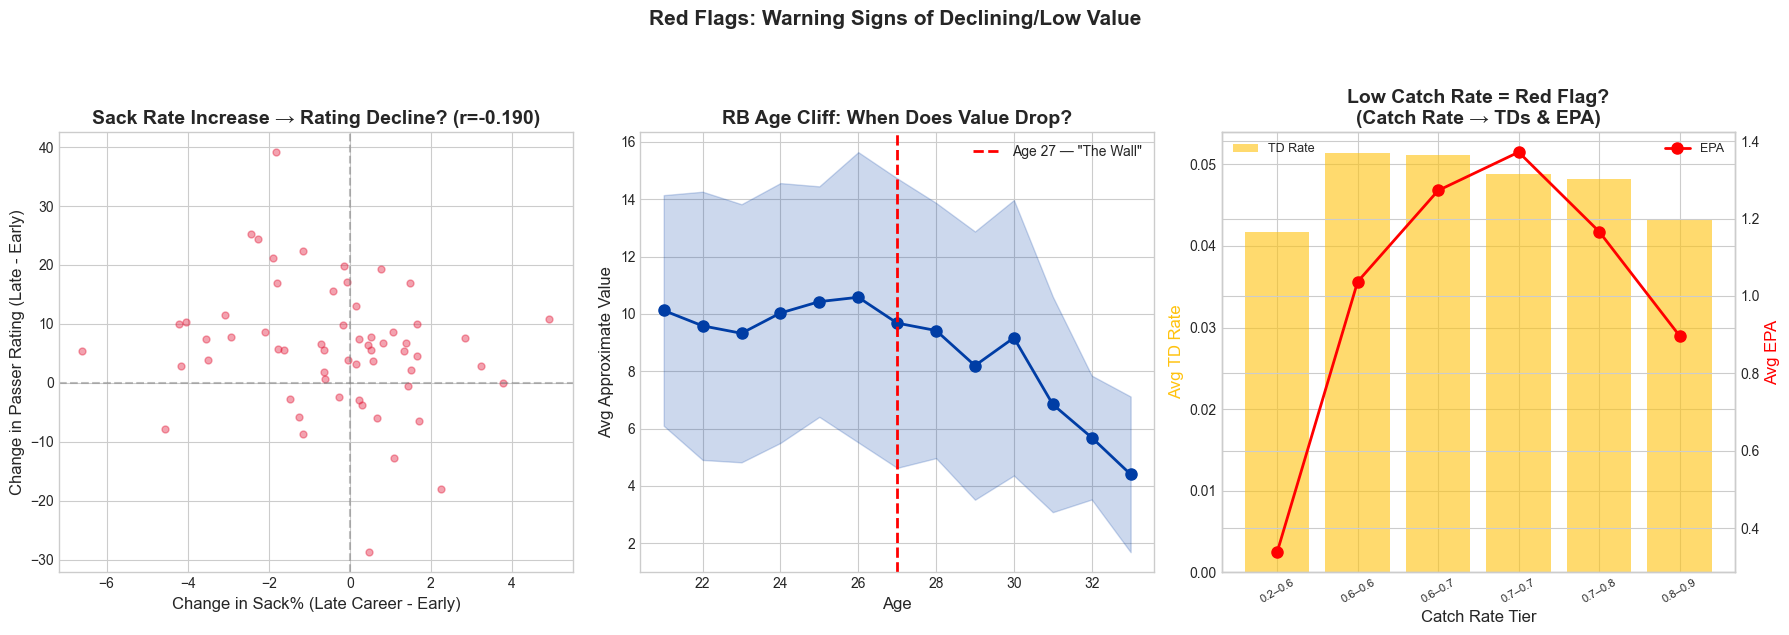

🚩 RED FLAGS TO WATCH:
   • QB: Rising sack rate correlates with passer rating decline
   • RB: Age 27+ = value cliff — don't give big contracts after 26
   • WR: Low catch rate strongly predicts low EPA and TD production


In [52]:
# 12.3 — Red Flags: Stats That Signal Declining Value
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# QB: Sack rate over career — does it predict decline?
ax = axes[0]
qb_career_trend = qb_starters.groupby('Player').filter(lambda x: len(x) >= 4)
if len(qb_career_trend) > 0 and 'Sk%' in qb_career_trend.columns:
    # Compare first 2 years vs last 2 years for QBs with 4+ seasons
    players_long = qb_career_trend.groupby('Player')['Season'].count()
    players_long = players_long[players_long >= 4].index
    
    early_sk = []
    late_sk = []
    decline = []
    for p in players_long:
        pdata = qb_career_trend[qb_career_trend['Player'] == p].sort_values('Season')
        e = pdata.head(2)['Sk%'].mean()
        l = pdata.tail(2)['Sk%'].mean()
        d = pdata.tail(2)['Rate'].mean() - pdata.head(2)['Rate'].mean()
        if pd.notna(e) and pd.notna(l):
            early_sk.append(e)
            late_sk.append(l)
            decline.append(d)
    
    if len(early_sk) > 10:
        ax.scatter(np.array(late_sk) - np.array(early_sk), decline, alpha=0.4, s=25, color=COLORS['QB'])
        r, _ = stats.pearsonr(np.array(late_sk) - np.array(early_sk), decline)
        ax.set_xlabel('Change in Sack% (Late Career - Early)')
        ax.set_ylabel('Change in Passer Rating (Late - Early)')
        ax.set_title(f'Sack Rate Increase → Rating Decline? (r={r:.3f})', fontweight='bold')
        ax.axhline(0, color='gray', ls='--', alpha=0.5)
        ax.axvline(0, color='gray', ls='--', alpha=0.5)

# RB: Age cliff — performance drop after specific ages
ax = axes[1]
rb_age_val = rb_starters.dropna(subset=['Age', 'av']).copy()
age_av = rb_age_val.groupby('Age')['av'].agg(['mean', 'std']).reset_index()
age_av = age_av[(age_av['Age'] >= 21) & (age_av['Age'] <= 33)]

ax.fill_between(age_av['Age'], age_av['mean'] - age_av['std'], 
                age_av['mean'] + age_av['std'], alpha=0.2, color=COLORS['RB'])
ax.plot(age_av['Age'], age_av['mean'], 'o-', color=COLORS['RB'], lw=2, ms=8)
ax.axvline(27, color='red', ls='--', lw=2, label='Age 27 — "The Wall"')
ax.set_xlabel('Age')
ax.set_ylabel('Avg Approximate Value')
ax.set_title('RB Age Cliff: When Does Value Drop?', fontweight='bold')
ax.legend()

# WR: Declining catch rate and target share
ax = axes[2]
wr_declining = wr_starters.dropna(subset=['catch_rate', 'td_rate']).copy()
wr_cr_bins = pd.qcut(wr_declining['catch_rate'], q=6, duplicates='drop')
cr_td = wr_declining.groupby(wr_cr_bins, observed=True).agg({
    'td_rate': 'mean', 'epa': 'mean'
})

ax2 = ax.twinx()
ax.bar(range(len(cr_td)), cr_td['td_rate'], alpha=0.6, color=COLORS['WR'], label='TD Rate')
ax2.plot(range(len(cr_td)), cr_td['epa'], 'ro-', lw=2, ms=8, label='EPA')
ax.set_xticks(range(len(cr_td)))
ax.set_xticklabels([f"{b.left:.1f}–{b.right:.1f}" for b in cr_td.index], rotation=30, fontsize=8)
ax.set_xlabel('Catch Rate Tier')
ax.set_ylabel('Avg TD Rate', color=COLORS['WR'])
ax2.set_ylabel('Avg EPA', color='red')
ax.set_title('Low Catch Rate = Red Flag?\n(Catch Rate → TDs & EPA)', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

plt.suptitle('Red Flags: Warning Signs of Declining/Low Value', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
print("🚩 RED FLAGS TO WATCH:")
print("   • QB: Rising sack rate correlates with passer rating decline")
print("   • RB: Age 27+ = value cliff — don't give big contracts after 26")
print("   • WR: Low catch rate strongly predicts low EPA and TD production")

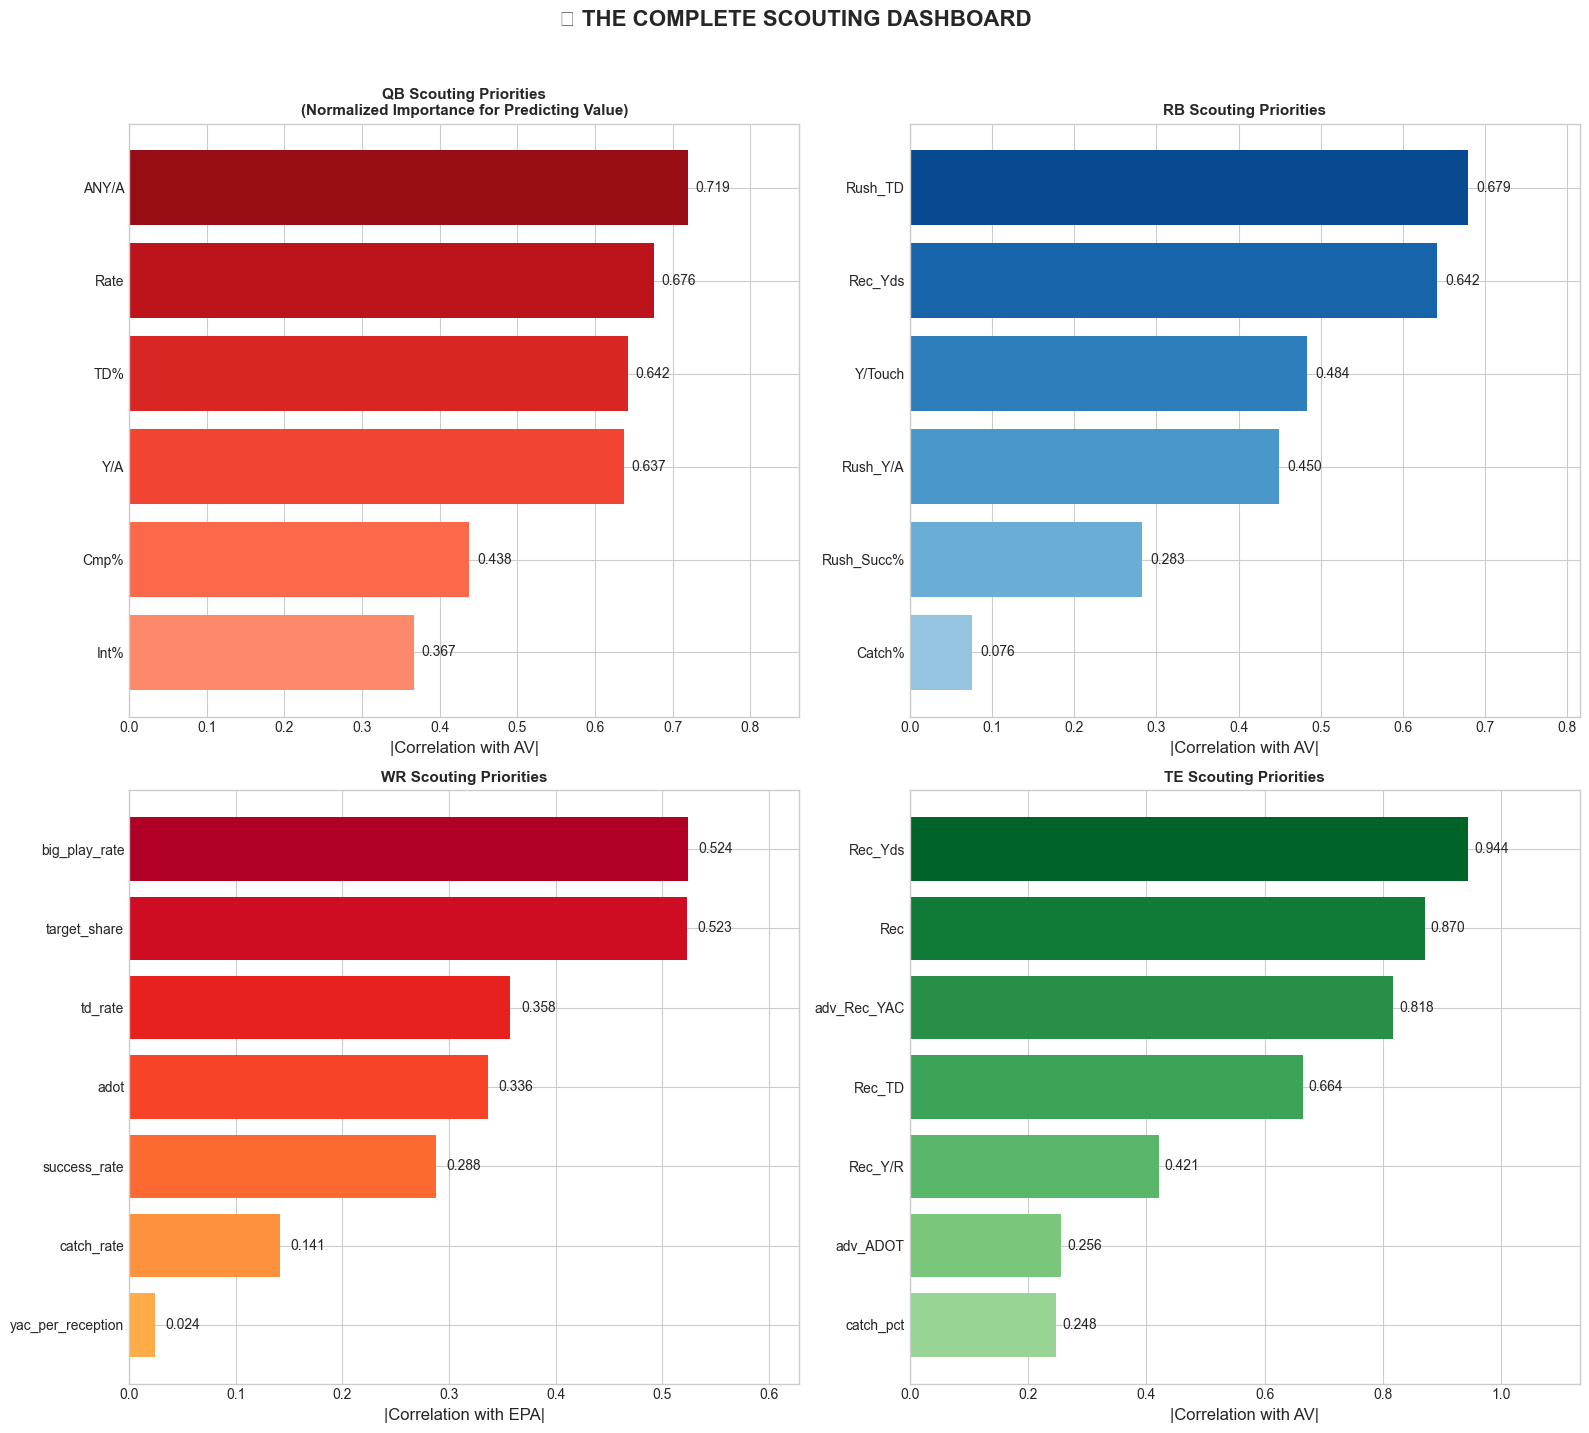


📋 FINAL SCOUTING REPORT — HOW TO BUILD A WINNING ROSTER

🔴 QUARTERBACK — The Most Important Pick
   LOOK FOR: High ANY/A, Passer Rating, low INT%, good Completion%
   AVOID: Raw yardage merchants on bad teams (stat padding)
   SECRET WEAPON: Pocket time + on-target% (advanced metrics tell more)

🔵 RUNNING BACK — Don't Overpay
   LOOK FOR: High Y/Touch, pass-catching ability, Success Rate
   AVOID: Pure volume backs with low Y/A — they won't age well
   SECRET WEAPON: Receiving yards matter more than people think

🟡 WIDE RECEIVER — Target Share Is Everything  
   LOOK FOR: High target share, red zone targets, consistent across quarters
   AVOID: Low catch rate + only produces in garbage time
   SECRET WEAPON: QB quality matters — same WR on better team = way more value

🟢 TIGHT END — The New Alpha Receiver
   LOOK FOR: Receptions + receiving yards (volume = value at TE)
   AVOID: Low catch%, inconsistent targets
   SECRET WEAPON: Pass-catching TEs are the most undervalued position

💎 U

In [53]:
# 12.4 — The Complete Scouting Dashboard: Position-by-Position Summary
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# QB Summary Radar (using normalized metrics)
ax = axes[0, 0]
ax.set_title('QB Scouting Priorities\n(Normalized Importance for Predicting Value)', fontweight='bold', fontsize=11)
qb_scout_stats = ['Rate', 'ANY/A', 'TD%', 'Int%', 'Cmp%', 'Y/A']
qb_scout_stats = [c for c in qb_scout_stats if c in qb_starters.columns and 'AV' in qb_starters.columns]
if qb_scout_stats:
    corrs_qb = {s: abs(qb_starters[['AV', s]].dropna().corr().iloc[0,1]) for s in qb_scout_stats}
    sorted_qb = sorted(corrs_qb.items(), key=lambda x: x[1], reverse=True)
    labels, vals = zip(*sorted_qb)
    colors_bar = plt.cm.Reds(np.linspace(0.4, 0.9, len(vals)))
    bars = ax.barh(labels[::-1], vals[::-1], color=colors_bar)
    for bar, val in zip(bars, vals[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.set_xlabel('|Correlation with AV|')
    ax.set_xlim(0, max(vals) * 1.2)

# RB Summary
ax = axes[0, 1]
ax.set_title('RB Scouting Priorities', fontweight='bold', fontsize=11)
rb_scout_stats = ['Rush_Y/A', 'Rec_Yds', 'Rush_TD', 'Rush_Succ%', 'Y/Touch', 'Catch%']
rb_scout_stats = [c for c in rb_scout_stats if c in rb_starters.columns and 'av' in rb_starters.columns]
if rb_scout_stats:
    corrs_rb = {s: abs(rb_starters[['av', s]].dropna().corr().iloc[0,1]) for s in rb_scout_stats}
    sorted_rb = sorted(corrs_rb.items(), key=lambda x: x[1], reverse=True)
    labels_r, vals_r = zip(*sorted_rb)
    colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(vals_r)))
    bars = ax.barh(labels_r[::-1], vals_r[::-1], color=colors_bar)
    for bar, val in zip(bars, vals_r[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.set_xlabel('|Correlation with AV|')
    ax.set_xlim(0, max(vals_r) * 1.2)

# WR Summary
ax = axes[1, 0]
ax.set_title('WR Scouting Priorities', fontweight='bold', fontsize=11)
wr_scout_stats = ['target_share', 'catch_rate', 'td_rate', 'success_rate', 
                  'big_play_rate', 'adot', 'yac_per_reception']
wr_scout_stats = [c for c in wr_scout_stats if c in wr_starters.columns and 'epa' in wr_starters.columns]
if wr_scout_stats:
    corrs_wr = {s: abs(wr_starters[['epa', s]].dropna().corr().iloc[0,1]) for s in wr_scout_stats}
    sorted_wr = sorted(corrs_wr.items(), key=lambda x: x[1], reverse=True)
    labels_w, vals_w = zip(*sorted_wr)
    colors_bar = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(vals_w)))
    bars = ax.barh(labels_w[::-1], vals_w[::-1], color=colors_bar)
    for bar, val in zip(bars, vals_w[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.set_xlabel('|Correlation with EPA|')
    ax.set_xlim(0, max(vals_w) * 1.2)

# TE Summary
ax = axes[1, 1]
ax.set_title('TE Scouting Priorities', fontweight='bold', fontsize=11)
te_scout_stats = ['Rec', 'Rec_Yds', 'Rec_TD', 'catch_pct', 'Rec_Y/R', 'adv_ADOT', 'adv_Rec_YAC']
te_scout_stats = [c for c in te_scout_stats if c in te_starters.columns and 'av' in te_starters.columns]
if te_scout_stats:
    corrs_te = {s: abs(te_starters[['av', s]].dropna().corr().iloc[0,1]) for s in te_scout_stats}
    sorted_te = sorted(corrs_te.items(), key=lambda x: x[1], reverse=True)
    labels_t, vals_t = zip(*sorted_te)
    colors_bar = plt.cm.Greens(np.linspace(0.4, 0.9, len(vals_t)))
    bars = ax.barh(labels_t[::-1], vals_t[::-1], color=colors_bar)
    for bar, val in zip(bars, vals_t[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.set_xlabel('|Correlation with AV|')
    ax.set_xlim(0, max(vals_t) * 1.2)

plt.suptitle('🏈 THE COMPLETE SCOUTING DASHBOARD', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("📋 FINAL SCOUTING REPORT — HOW TO BUILD A WINNING ROSTER")
print("="*70)
print("""
🔴 QUARTERBACK — The Most Important Pick
   LOOK FOR: High ANY/A, Passer Rating, low INT%, good Completion%
   AVOID: Raw yardage merchants on bad teams (stat padding)
   SECRET WEAPON: Pocket time + on-target% (advanced metrics tell more)

🔵 RUNNING BACK — Don't Overpay
   LOOK FOR: High Y/Touch, pass-catching ability, Success Rate
   AVOID: Pure volume backs with low Y/A — they won't age well
   SECRET WEAPON: Receiving yards matter more than people think
   WARNING: Don't pay RBs after age 27 — the cliff is real

🟡 WIDE RECEIVER — Target Share Is Everything  
   LOOK FOR: High target share, red zone targets, consistent across quarters
   AVOID: Low catch rate + only produces in garbage time
   SECRET WEAPON: QB quality matters — same WR on better team = way more value
   
🟢 TIGHT END — The New Alpha Receiver
   LOOK FOR: Receptions + receiving yards (volume = value at TE)
   AVOID: Low catch%, inconsistent targets
   SECRET WEAPON: Pass-catching TEs are the most undervalued position

💎 UNIVERSAL TRUTH: Efficiency > Volume at EVERY position
   The game has changed — smart teams draft for efficiency, not just size.
""")

---
# 13. Key Conclusions & Insights

### Quarterback Findings
1. **Passing revolution** — Yards, TDs, completion %, and passer rating all show strong upward trends over the decades
2. **Win predictors** — Passer Rating, Y/A, and Completion % correlate most strongly with winning
3. **Turnovers matter** — INT% shows a clear negative correlation with Win%
4. **Stat padding is real** — QBs on losing teams accumulate yards in garbage time
5. **Dual-threat evolution** — Modern QBs (Jackson, Allen) combine passing with significant rushing
6. **Efficiency > Volume** — ANY/A and Rate predict value (AV) far better than raw passing yards
7. **Magic numbers** — Passer Rating > 90, Comp% > 63%, Y/A > 7.0 → almost guaranteed winning record

### Running Back Findings
1. **Declining workhorse** — Total carries per back have decreased as RBBC has become prevalent
2. **Pass-catching evolution** — The receiving share of RB production has steadily increased
3. **Short career window** — RBs peak at 25–27 and decline rapidly, unlike QBs who can play into their late 30s
4. **Broken tackles predict success** — `adv_Rush_BrkTkl` correlates strongly with total yardage
5. **Pass-catching RBs are more valuable** — Dual-threat backs have higher AV than pure rushers
6. **Diminishing returns** — More touches per season → lower efficiency per touch
7. **Age 27 is "The Wall"** — AV drops sharply after 27, making late-career contracts risky

### Wide Receiver Findings
1. **Target share is king** — The single strongest predictor of WR production
2. **ADOT vs YAC tradeoff** — Deep threats and YAC monsters are different archetypes, both can be elite
3. **Weather matters** — Wind and extreme temperatures negatively impact receiving production
4. **QB dependency** — WR success is partly a function of QB quality (CPOE) and team pass volume
5. **Consistency separates stars** — Top WRs produce across all quarters, not just garbage time
6. **Red zone targets → TDs** — Red zone target rate directly translates to scoring
7. **Clutch factor** — Production in close games (45–55% WP) matters more than blowout stats

### Tight End Findings
1. **Position transformation** — Modern TEs are increasingly used as primary receivers
2. **Travis Kelce effect** — The elite TEs are statistical outliers far above the positional average
3. **Catch rate reliability** — TEs are among the most reliable targets with high catch rates
4. **Volume = Value at TE** — Receptions and receiving yards are the strongest AV predictors

### The Winning Formula
1. **Efficiency beats volume at EVERY position** — Y/A, Rate, Rush_Succ%, target_share > raw totals
2. **Feature importance (Random Forest)** confirms: efficiency metrics are the top predictors of winning
3. **Young player traits predict future success** — early efficiency (not volume) forecasts career peak
4. **Red flags are real** — rising sack rate (QB), age 27+ (RB), low catch rate (WR) signal decline

### The GM's Cheat Sheet
- **QB:** Prioritize ANY/A, Passer Rating, and INT% — forget about yardage totals
- **RB:** Draft pass-catching backs, don't pay them after 26, value Y/Touch over carries
- **WR:** Target share is everything; also check QB context and clutch production
- **TE:** The most undervalued position — pass-catching TEs provide elite value at a discount

---
*Next: Notebook 3 — Models & Results → Building predictive models for each position*